**WARNING**: The merged dataset is approximately 7GB. The NOAA API weather pull in Section 3.4 requires a free API token and takes approximately 45 minutes to run. The BTS zip files total ~4 GB. To reproduce, follow the acquisition steps in Section 3.


## Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Background and Motivation](#sec1) | Why we built this and what question drove it |
| 2 | [Project Objectives](#sec2) | Research questions and learning goals |
| 3 | [Data Description and Acquisition](#sec3) | Four data sources and how we pulled them |
| 4 | [Ethical Considerations](#sec4) | Who is affected and what we have to be careful about |
| 5 | [Data Cleaning and Processing](#sec5) | How we cleaned, merged, and feature-engineered the raw data |
| 6 | [Analysis Methodology](#sec6) | Statistical and ML methods used |
| 7 | [Exploratory Analysis](#sec7) | Nine research questions, OLS, clustering, time series, and interactive tools |
| 8 | [Results](#sec8) | Written synthesis of all findings |
| 9 | [Limitations](#sec9) | What the data and models cannot do |
| 10 | [Conclusions](#sec10) | Key takeaways and implications |

# Cleared for Delay: A Data-Driven Look at U.S. Flight Disruptions

**Alison Besendorfer** | u1382375@utah.edu | U1382375  
**Jacob Thomas** | u1469907@utah.edu | U1469907  
**Matthew Cottle** | u1545160@utah.edu | U1545160  

University of Utah · Math 4100 · Spring 2026

## Screencast Link: [https://youtu.be/zZ9rtibhE-c](https://youtu.be/zZ9rtibhE-c)

## Executive Summary

We set out to answer a simple question: what actually causes flight delays? Most people blame the weather. The data tells a different story.

We pulled 26.5 million domestic flights from 2021 to 2024 using four public datasets - BTS on-time performance records, NOAA daily weather data via API, and two FAA datasets for airports and aircraft. After merging and cleaning, we excluded the July 2024 CrowdStrike outage window (145K flights removed), leaving us with 86.4% of flights matched to weather observations and 92.1% matched to aircraft type.

### Dataset

Our dataset covers 26.5 million total flights (26 million non-cancelled) spanning January 2021 through December 2024 across 75 major U.S. airports, drawn from four sources: BTS, NOAA, and two FAA datasets (airports and aircraft registry).

### Key Findings

**Weather is not the culprit.** Late aircraft and carrier issues account for 76.1% of all delay minutes (38.6% and 37.5% respectively). Weather is responsible for just 5.9%. Even in our regression models, precipitation and snowfall show up as significant predictors, but their real-world effect is small.

**The numbers barely move no matter what we add.** Our full OLS model - weather, airport size, seasonality, and carrier - explains only 1.74% of departure delay variance. Weather alone gets 0.83%. Adding carrier identity brings it to 1.74%. The other 98.26% comes down to things we cannot observe: whether the inbound plane was late, whether there was a maintenance issue, whether the crew ran out of hours on a previous leg.

**Who you fly with matters more than the weather.** Alaska and Hawaiian are consistently at the top. JetBlue and Frontier sit at the bottom. These differences hold even on similar routes and hub sizes.

**Delays got worse after COVID and have not come back down.** Additive seasonal decomposition shows a clear upward shift from 2021 into 2022, with the usual summer and December peaks on top of that.

**Airports cluster into three groups.** K-Means (k=3) separates airports into a low-delay group of western airports, a mid-tier group of large inland hubs, and a high-delay group centered on Florida (FLL, MCO, MIA) and the congested Northeast (EWR, JFK).

**Predicting individual delays is hard.** A two-stage model (logistic regression to flag delays, then OLS on delayed flights) hits AUC = 0.57 and R² = 0.54%. You can spot broad patterns, but pinning down whether your specific flight will be late is not something the data can reliably do.

### Methods Applied

One-way ANOVA with Tukey HSD post-hoc tests, multivariate OLS regression, log-transformed OLS, HC3 robust standard errors, nested model variance decomposition, ridge regression with cross-validation, logistic regression, K-Means clustering, k-NN classification, additive seasonal decomposition, Pearson correlation, interactive Folium maps, and a companion website with live API integrations.

### Companion Website

We also built a live Flight Intel Tool at [cleared-for-delay.netlify.app](https://cleared-for-delay.netlify.app) - look up any airline or airport, get delay history, and see route-level performance before you book.

## 1. Background and Motivation <a id="sec1"></a>

Flight delays are one of the most common frustrations in modern travel. The stakes are real and significant. In 2010, UC Berkeley conducted a study, discovering that flight delays cost the U.S. economy roughly 33 billion dollars annually, with effects that ripple through passengers, cargo, and crews. With inflation, in 2026, that number is roughly 50 billion dollars, presenting a substantial economic issue. In addition, idling aircraft burn extra fuel, and rerouted flights add emissions. The consensus among most people is that weather is the main culprit of delays, thus, we sought out to see whether that assumption is correct. This hypothesis is the main motivation and origin of our project. In order to successfully find our answer by way of data analysis, we had to seek out multiple sources of data to comprehensively answer all of our questions. With the Bureau of Transportation Statistics' database, National Oceanic and Atmospheric Administration's daily weather summaries, and FAA Airport Facilities and Aircraft Registry Data, we were able to answer a multitude of questions surrounding the issue of flight delays domestically within the United States. That engineering work is a substantial part of what this project involved. We have all had our share of delayed flights and opinions about which airlines are the worst. We wanted to see if the data agreed.

*UC Berkeley Study Link*: https://news.berkeley.edu/2010/10/18/flight_delays/#:~:text=Table_title:%20Flight%20delays%20cost%20$32.9%20billion%2C%20passengers,Cost%20%7C%20Cost%20(in%20billions):%20$32.9%20%7C*

## 2. Project Objectives <a id="sec2"></a>

### 2.1 Research Questions

1. **Which airlines have the best and worst on-time performance?** Helps travelers make informed booking decisions.
2. **Which airlines offer the best performance-to-distance ratio?** Identifies carriers that are reliable over long routes.
3. **Which airports cause the biggest delays across the network?** Helps airlines optimize routing.
4. **What are the most common causes of delays?** Identifies root causes so improvements can be targeted.
5. **Are certain routes worse than others?** Gives airlines scheduling insights and warns travelers.
6. **Do delays vary by season?** Helps travelers plan around high-risk periods.
7. **Does weather significantly predict delay length?** Tests whether weather deserves the blame it gets.
8. **Are delays getting better or worse over time?** Reveals whether infrastructure investments are paying off.
9. **Is there a relationship between flight distance and delay likelihood?** Tests whether turnaround time or airspace congestion plays a role.

### 2.2 Learning Objectives

- Build a multi-source data pipeline merging BTS flight data, NOAA weather via API, FAA airport metadata, and FAA Aircraft Registry
- Apply OLS regression, logistic regression, Ridge regression, K-Means clustering, K-NN classification, and time series decomposition to a real-world dataset
- Understand the gap between what statistical models can explain and what they cannot
- Build interactive notebook-based analysis tools and a companion website with live API integrations

## 3. Data Description and Acquisition <a id="sec3"></a>

We use four data sources:

**Source 1: Bureau of Transportation Statistics (BTS)** — Our primary dataset. Monthly CSV files downloaded from the [BTS On-Time Performance database](https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr). Each row is a single flight. Key attributes include carrier, origin/destination airports, tail number, flight number, scheduled and actual departure/arrival times, delay duration, delay cause, and distance. We pulled all 48 months of 2021-2024. No account required.

**Source 2: NOAA Climate Data Online** — Daily weather summaries pulled via the [NOAA CDO API](https://www.ncdc.noaa.gov/cdo-web/webservices/v2) for the 75 busiest airports. Attributes include max/min temperature, precipitation, snowfall, average wind speed, and max wind gust. Access requires a free API token.

**Source 3: FAA Airport Facilities Data** — Airport metadata from the [FAA ADIP portal](https://adip.faa.gov/agis/public/#/airportSearch/advanced) and [NASR subscription data](https://www.faa.gov/air_traffic/flight_info/aeronav/aero_data/NASR_Subscription/) including latitude/longitude, elevation, and hub classification. Publicly available, no account required.

**Source 4: FAA Aircraft Registry** — Aircraft metadata from the [FAA Releasable Aircraft Database](https://www.faa.gov/licenses_certificates/aircraft_certification/aircraft_registry/releasable_aircraft_download). Contains two key files: MASTER.txt (N-number to manufacturer/model code) and ACFTREF.txt (model code to manufacturer name, model name, seat count, and engine count). We join this to BTS data via tail number to identify the aircraft type for each flight. Publicly available, no account required.

### 3.1 Imports and Setup

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import seaborn as sns
import os
import glob
import requests
import time
import numpy as np
import gc
import json
import warnings
import zipfile
from scipy import stats
from scipy.stats import probplot, skew, kurtosis
import folium
from folium.plugins import HeatMap
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

### 3.2 Loading BTS Flight Data

The BTS data was downloaded as monthly pre-zipped CSV files for 2021-2024 from the BTS PREZIP directory using an iterative python file in Terminal. We load each zip, select the 20 columns we need, rename them to our standard names, and concatenate into a single dataframe, then convert date fields and derive new time-based features.

In [7]:
bts_dir = "../bts"
files = sorted(glob.glob(os.path.join(bts_dir, "*.zip")))
print(f"Found {len(files)} ZIP files")

# Column rename map: PREZIP names -> our standard names
rename_map = {
    'FlightDate': 'FL_DATE',
    'Reporting_Airline': 'OP_UNIQUE_CARRIER',
    'Flight_Number_Reporting_Airline': 'OP_CARRIER_FL_NUM',
    'Tail_Number': 'TAIL_NUM',
    'Origin': 'ORIGIN',
    'Dest': 'DEST',
    'OriginCityName': 'ORIGIN_CITY_NAME',
    'CRSDepTime': 'CRS_DEP_TIME',
    'DepDelay': 'DEP_DELAY',
    'DepDel15': 'DEP_DEL15',
    'ArrDelay': 'ARR_DELAY',
    'ArrDel15': 'ARR_DEL15',
    'Cancelled': 'CANCELLED',
    'Diverted': 'DIVERTED',
    'Distance': 'DISTANCE',
    'CarrierDelay': 'CARRIER_DELAY',
    'WeatherDelay': 'WEATHER_DELAY',
    'NASDelay': 'NAS_DELAY',
    'SecurityDelay': 'SECURITY_DELAY',
    'LateAircraftDelay': 'LATE_AIRCRAFT_DELAY',
}

prezip_cols = list(rename_map.keys())

dfs = []
for f in files:
    with zipfile.ZipFile(f) as zf:
        csv_name = [n for n in zf.namelist() if n.endswith('.csv')][0]
        chunk = pd.read_csv(zf.open(csv_name), usecols=prezip_cols, low_memory=False)
        chunk = chunk.rename(columns=rename_map)
        dfs.append(chunk)
        print(f"\r  Loaded {len(dfs)}/{len(files)}: {os.path.basename(f)}", end="")

print(f"\r  Loaded {len(files)} files. Concatenating...{' '*30}")

df = pd.concat(dfs, ignore_index=True)
del dfs

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], format='mixed')
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.day_name()
df['MONTH'] = df['FL_DATE'].dt.month
df['YEAR'] = df['FL_DATE'].dt.year

print(f"\nTotal flights: {len(df):,}")
print(f"Date range: {df['FL_DATE'].min()} to {df['FL_DATE'].max()}")
print(f"\nFlights per year:")
print(df['YEAR'].value_counts().sort_index())
print(f"\nColumns: {df.columns.tolist()}")

Found 48 ZIP files
  Loaded 48 files. Concatenating...                              

Total flights: 26,651,482
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00

Flights per year:
YEAR
2021    5995397
2022    6729125
2023    6847899
2024    7079061
Name: count, dtype: int64

Columns: ['FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'DEP_DEL15', 'ARR_DELAY', 'ARR_DEL15', 'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DAY_OF_WEEK', 'MONTH', 'YEAR']


The BTS delay-cause columns (CARRIER_DELAY, WEATHER_DELAY, NAS_DELAY, SECURITY_DELAY, LATE_AIRCRAFT_DELAY) are only populated when a flight is delayed more than 15 minutes. All other rows are NaN for those fields — this is a structural feature of the dataset, not a data quality issue. We verify this and check cancellation/diversion rates below.

In [9]:
print("BTS Data Quality Check ")
print(f"\nNull counts in key delay columns:")
delay_cols = ['DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY', 
              'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
print(df[delay_cols].isnull().sum())

print(f"\nCancelled flights: {df['CANCELLED'].sum():,} ({df['CANCELLED'].mean()*100:.2f}%)")
print(f"Diverted flights: {df['DIVERTED'].sum():,} ({df['DIVERTED'].mean()*100:.2f}%)")

print(f"\nDEP_DELAY stats (non-null):")
print(df['DEP_DELAY'].describe())

print(f"\nUnique carriers: {df['OP_UNIQUE_CARRIER'].nunique()}")
print(df['OP_UNIQUE_CARRIER'].value_counts())

BTS Data Quality Check 

Null counts in key delay columns:
DEP_DELAY                455591
ARR_DELAY                532601
CARRIER_DELAY          21427691
WEATHER_DELAY          21427691
NAS_DELAY              21427691
SECURITY_DELAY         21427691
LATE_AIRCRAFT_DELAY    21427691
dtype: int64

Cancelled flights: 468,604.0 (1.76%)
Diverted flights: 63,994.0 (0.24%)

DEP_DELAY stats (non-null):
count    2.619589e+07
mean     1.182001e+01
std      5.318610e+01
min     -1.050000e+02
25%     -5.000000e+00
50%     -2.000000e+00
75%      9.000000e+00
max      4.413000e+03
Name: DEP_DELAY, dtype: float64

Unique carriers: 17
OP_UNIQUE_CARRIER
WN    5229673
DL    3635330
AA    3535381
OO    2906814
UA    2565973
YX    1246327
MQ    1011212
B6     990894
NK     948735
AS     908502
9E     900257
OH     859176
F9     678790
G4     465507
HA     293904
YV     274588
QX     200419
Name: count, dtype: int64


So the data looks like what we would expect. The delay-cause columns are NaN for about 21.4 million flights that weren't delayed more than 15 minutes, which is just how the BTS structures it. Cancellations are low at 1.76%, and diversions are even lower at 0.24%. Average departure delay is around 11.8 minutes, but the standard deviation is huge (roughly 53 min), which tells us the distribution is really skewed right. Most flights leave on time or close to it, and then a small number of flights get delayed for hours and pull the average way up.

### 3.3 Identifying Top Airports

Rather than pulling weather for every airport in the country, we identify the 75 most common origin and destination airports. These handle the vast majority of domestic flights.

In [13]:
top_origins = df['ORIGIN'].value_counts().head(75).index.tolist()
top_dests = df['DEST'].value_counts().head(75).index.tolist()
top_airports = sorted(list(set(top_origins + top_dests)))
print(f"{len(top_airports)} unique airports to pull weather for")
print(top_airports)

75 unique airports to pull weather for
['ABQ', 'ANC', 'ATL', 'AUS', 'BDL', 'BNA', 'BOI', 'BOS', 'BUF', 'BUR', 'BWI', 'CHS', 'CLE', 'CLT', 'CMH', 'CVG', 'DAL', 'DCA', 'DEN', 'DFW', 'DTW', 'ELP', 'EWR', 'FLL', 'GEG', 'GRR', 'HNL', 'HOU', 'IAD', 'IAH', 'IND', 'JAX', 'JFK', 'KOA', 'LAS', 'LAX', 'LGA', 'MCI', 'MCO', 'MDW', 'MEM', 'MIA', 'MKE', 'MSP', 'MSY', 'OAK', 'OGG', 'OKC', 'OMA', 'ONT', 'ORD', 'ORF', 'PBI', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU', 'RIC', 'RNO', 'RSW', 'SAN', 'SAT', 'SAV', 'SDF', 'SEA', 'SFO', 'SJC', 'SJU', 'SLC', 'SMF', 'SNA', 'STL', 'TPA', 'TUS']


The top 75 origin airports and top 75 destination airports are identical, confirming that the busiest airports dominate both departure and arrival traffic.

### 3.4 Acquiring NOAA Weather Data

We use the NOAA Climate Data Online API to pull daily weather summaries (GHCND dataset) for each of our 75 airports across all four years (2021-2024). The process involves three steps:
1. Define airport coordinates and target weather variables
2. Map each airport to its nearest active NOAA weather station
3. Pull daily observations for 2021-2024

Weather variables collected: max temperature (TMAX), min temperature (TMIN), precipitation (PRCP), snowfall (SNOW), average wind speed (AWND), and max wind gust (WSF2).

**Step 1: Airport coordinates and API setup.**

In [16]:
NOAA_TOKEN = "API TOKEN" # placeholder
headers = {"token": NOAA_TOKEN}

DATATYPES = ["TMAX", "TMIN", "PRCP", "SNOW", "AWND", "WSF2"]

airport_coords = {
    'ABQ': (35.0402, -106.6090),
    'ANC': (61.1743, -149.9962),
    'ATL': (33.6407, -84.4277),
    'AUS': (30.1975, -97.6664),
    'BDL': (41.9389, -72.6832),
    'BNA': (36.1263, -86.6774),
    'BOI': (43.5644, -116.2228),
    'BOS': (42.3656, -71.0096),
    'BUF': (42.9405, -78.7322),
    'BUR': (34.2007, -118.3585),
    'BWI': (39.1774, -76.6684),
    'CHS': (32.8986, -80.0405),
    'CLE': (41.4058, -81.8539),
    'CLT': (35.2140, -80.9431),
    'CMH': (39.9980, -82.8919),
    'CVG': (39.0488, -84.6678),
    'DAL': (32.8471, -96.8518),
    'DCA': (38.8512, -77.0402),
    'DEN': (39.8561, -104.6737),
    'DFW': (32.8998, -97.0403),
    'DTW': (42.2162, -83.3554),
    'ELP': (31.8072, -106.3776),
    'EWR': (40.6895, -74.1745),
    'FLL': (26.0742, -80.1506),
    'GEG': (47.6199, -117.5338),
    'GRR': (42.8808, -85.5228),
    'HNL': (21.3187, -157.9225),
    'HOU': (29.6454, -95.2789),
    'IAD': (38.9531, -77.4565),
    'IAH': (29.9902, -95.3368),
    'IND': (39.7173, -86.2944),
    'JAX': (30.4941, -81.6879),
    'JFK': (40.6413, -73.7781),
    'KOA': (19.7388, -156.0456),
    'LAS': (36.0840, -115.1537),
    'LAX': (33.9425, -118.4081),
    'LGA': (40.7769, -73.8740),
    'MCO': (28.4312, -81.3081),
    'MCI': (39.2976, -94.7139),
    'MDW': (41.7868, -87.7522),
    'MEM': (35.0424, -89.9767),
    'MIA': (25.7959, -80.2870),
    'MKE': (42.9472, -87.8966),
    'MSP': (44.8848, -93.2223),
    'MSY': (29.9934, -90.2580),
    'OAK': (37.7213, -122.2208),
    'OGG': (20.8986, -156.4305),
    'OKC': (35.3931, -97.6007),
    'OMA': (41.3032, -95.8941),
    'ONT': (34.0560, -117.6012),
    'ORD': (41.9742, -87.9073),
    'ORF': (36.8946, -76.2012),
    'PBI': (26.6832, -80.0956),
    'PDX': (45.5898, -122.5951),
    'PHL': (39.8744, -75.2424),
    'PHX': (33.4373, -112.0078),
    'PIT': (40.4919, -80.2329),
    'RDU': (35.8776, -78.7875),
    'RIC': (37.5052, -77.3197),
    'RNO': (39.4991, -119.7681),
    'RSW': (26.5362, -81.7552),
    'SAN': (32.7338, -117.1933),
    'SAT': (29.5337, -98.4698),
    'SAV': (32.1276, -81.2021),
    'SDF': (38.1744, -85.7360),
    'SEA': (47.4502, -122.3088),
    'SFO': (37.6213, -122.3790),
    'SJC': (37.3626, -121.9290),
    'SJU': (18.4394, -66.0018),
    'SLC': (40.7899, -111.9791),
    'SMF': (38.6954, -121.5908),
    'SNA': (33.6757, -117.8678),
    'STL': (38.7487, -90.3700),
    'TPA': (27.9756, -82.5333),
    'TUS': (32.1161, -110.9410),
}

print(f"{len(airport_coords)} airports ready")

75 airports ready


**Step 2: Map each airport to its nearest NOAA weather station.** We search with an expanding radius, prefer official airport weather stations (USW prefix), and use fallback stations for same-city airports.

In [29]:
airport_to_station = {}
no_station = []

for code, (lat, lon) in airport_coords.items():
    url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/stations"
    
    for radius in [0.01, 0.03, 0.05, 0.075, 0.1, 0.3, 0.5]:
        params = {
            "datasetid": "GHCND",
            "extent": f"{lat-radius},{lon-radius},{lat+radius},{lon+radius}",
            "startdate": "2021-01-01",
            "enddate": "2024-12-31",
            "limit": 25,
            "sortfield": "datacoverage",
            "sortorder": "desc"
        }
        
        resp = requests.get(url, headers=headers, params=params)
        time.sleep(0.3)
        
        if resp.status_code == 200 and resp.json().get("results"):
            results = resp.json()["results"]
            best = None
            for s in results:
                if s["id"].startswith("GHCND:USW"):
                    best = s
                    break
            if not best:
                best = results[0]
            
            airport_to_station[code] = best["id"]
            print(f"{code} -> {best['id']} ({best['name']}) radius={radius}")
            break
    else:
        no_station.append(code)
        print(f"{code} -> NO STATION FOUND")

fallbacks = {
    'HOU': 'IAH',
    'DAL': 'DFW',
    'BUR': 'LAX',
    'ONT': 'LAX',
}

for missing, donor in fallbacks.items():
    if missing in no_station and donor in airport_to_station:
        airport_to_station[missing] = airport_to_station[donor]
        no_station.remove(missing)
        print(f"{missing} -> using {donor}'s station: {airport_to_station[donor]}")

print(f"\nMapped: {len(airport_to_station)} | Failed: {len(no_station)}")
if no_station:
    print(f"Still missing: {no_station}")

ABQ -> GHCND:USW00023050 (ALBUQUERQUE INTERNATIONAL AIRPORT, NM US) radius=0.01
ANC -> GHCND:USC00500275 (ANCHORAGE FORECAST OFFICE, AK US) radius=0.03
ATL -> GHCND:USW00013874 (ATLANTA HARTSFIELD JACKSON INTERNATIONAL AIRPORT, GA US) radius=0.03
AUS -> GHCND:USW00013904 (AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US) radius=0.03
BDL -> GHCND:USW00014740 (HARTFORD BRADLEY INTERNATIONAL AIRPORT, CT US) radius=0.01
BNA -> GHCND:USW00013897 (NASHVILLE INTERNATIONAL AIRPORT, TN US) radius=0.03
BOI -> GHCND:USW00024131 (BOISE AIR TERMINAL, ID US) radius=0.03
BOS -> GHCND:USW00014739 (BOSTON LOGAN INTERNATIONAL AIRPORT, MA US) radius=0.01
BUF -> GHCND:USW00014733 (BUFFALO NIAGARA INTERNATIONAL AIRPOR, NY US) radius=0.01
BUR -> GHCND:USW00023152 (BURBANK GLENDALE PASADENA AIRPORT, CA US) radius=0.01
BWI -> GHCND:USW00093721 (BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US) radius=0.03
CHS -> GHCND:USW00013880 (CHARLESTON INTL. AIRPORT, SC US) radius=0.01
CLE -> GHCND:USW00014820 (CLEVELAND 

**Step 3: Pull daily weather observations for all mapped stations across 2021-2024.** This pulls 4 years of data for 75 airports. The API returns a maximum of 1000 records per request, so we divide the results into chunks and handle rate limits automatically.

In [36]:
all_weather = []

years = [
    ("2021-01-01", "2021-12-31"),
    ("2022-01-01", "2022-12-31"),
    ("2023-01-01", "2023-12-31"),
    ("2024-01-01", "2024-12-31"),
]

for start, end in years:
    print(f"\n{'='*50}")
    print(f"PULLING WEATHER FOR {start[:4]}")
    print(f"{'='*50}")
    
    for airport, station_id in airport_to_station.items():
        print(f"  {airport}...", end=" ")
        
        offset = 1
        retries = 0
        
        while True:
            url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"
            params = {
                "datasetid": "GHCND",
                "stationid": station_id,
                "startdate": start,
                "enddate": end,
                "datatypeid": ",".join(DATATYPES),
                "units": "standard",
                "limit": 1000,
                "offset": offset
            }
            
            resp = requests.get(url, headers=headers, params=params)
            
            if resp.status_code == 503:
                retries += 1
                if retries > 3:
                    print(f"giving up at offset {offset}")
                    break
                time.sleep(5)
                continue
            
            if resp.status_code != 200:
                print(f"error {resp.status_code}")
                break
            
            data = resp.json()
            results = data.get("results", [])
            
            if not results:
                break
            
            for r in results:
                r["airport"] = airport
            all_weather.extend(results)
            
            total = data.get("metadata", {}).get("resultset", {}).get("count", 0)
            offset += 1000
            retries = 0
            
            if offset > total:
                break
            
            time.sleep(0.4)
        
        count = sum(1 for r in all_weather if r['airport'] == airport)
        print(f"{count} total")

weather_raw = pd.DataFrame(all_weather)
print(f"\nTotal weather records: {len(weather_raw)}")
print(f"Airports with data: {weather_raw['airport'].nunique()}")


PULLING WEATHER FOR 2021
  ABQ... 2190 total
  ANC... 1457 total
  ATL... 2190 total
  AUS... 2190 total
  BDL... 2190 total
  BNA... 2190 total
  BOI... 2190 total
  BOS... 2190 total
  BUF... 2190 total
  BUR... 1675 total
  BWI... 2190 total
  CHS... 2190 total
  CLE... 2190 total
  CLT... 2190 total
  CMH... 2190 total
  CVG... 2190 total
  DAL... 2190 total
  DCA... 2190 total
  DEN... 2190 total
  DFW... 2190 total
  DTW... 2190 total
  ELP... 2189 total
  EWR... 2190 total
  FLL... 1824 total
  GEG... 2190 total
  GRR... 2190 total
  HNL... 1824 total
  HOU... 1856 total
  IAD... 2190 total
  IAH... 2190 total
  IND... 2190 total
  JAX... 2190 total
  JFK... 2190 total
  KOA... 1820 total
  LAS... 2190 total
  LAX... 1825 total
  LGA... 2190 total
  MCO... 2190 total
  MCI... 2190 total
  MDW... 1822 total
  MEM... 2190 total
  MIA... 1825 total
  MKE... 2190 total
  MSP... 2190 total
  MSY... 1823 total
  OAK... 1824 total
  OGG... 1825 total
  OKC... 2190 total
  OMA... 2190 

In [16]:
weather_raw.to_csv("../weather_raw.csv", index=False)
print(f"Saved {len(weather_raw)} raw weather records to weather_raw.csv")

Saved 629,166 raw weather records to weather_raw.csv


### 3.5 FAA Airport Facilities Data

We load the FAA's NASR subscription airport data and filter to our 75 airports.

In [17]:
faa_raw = pd.read_csv("../faa/APT_BASE.csv", encoding='latin-1', low_memory=False)

our_airports = sorted(list(airport_coords.keys()))

faa = faa_raw[faa_raw['ARPT_ID'].isin(our_airports)].copy()
print(f"Matched {len(faa)} of {len(our_airports)} airports")

keep_cols = {
    'ARPT_ID': 'airport',
    'ARPT_NAME': 'airport_name',
    'CITY': 'city',
    'STATE_CODE': 'state',
    'LAT_DECIMAL': 'latitude',
    'LONG_DECIMAL': 'longitude',
    'ELEV': 'elevation_ft',
}
available = {k: v for k, v in keep_cols.items() if k in faa.columns}
faa = faa[list(available.keys())].rename(columns=available)

faa['elevation_ft'] = pd.to_numeric(faa['elevation_ft'], errors='coerce')
faa['latitude'] = pd.to_numeric(faa['latitude'], errors='coerce')
faa['longitude'] = pd.to_numeric(faa['longitude'], errors='coerce')

print(f"\nFAA columns: {faa.columns.tolist()}")
print(f"Shape: {faa.shape}")
faa.head(10)

Matched 75 of 75 airports

FAA columns: ['airport', 'airport_name', 'city', 'state', 'latitude', 'longitude', 'elevation_ft']
Shape: (75, 7)


,airport,airport_name,city,state,latitude,longitude,elevation_ft
518,PHX,PHOENIX SKY HARBOR INTL,PHOENIX,AZ,33.434278,-112.011583,1134.8
611,TUS,TUCSON INTL,TUCSON,AZ,32.117070,-110.941463,2643.0
1058,BUR,BOB HOPE,BURBANK,CA,34.200694,-118.358667,778.0
1419,LAX,LOS ANGELES INTL,LOS ANGELES,CA,33.942496,-118.408049,127.8
1500,OAK,OAKLAND SAN FRANCISCO BAY,OAKLAND,CA,37.721261,-122.221151,9.0
1511,ONT,ONTARIO INTL,ONTARIO,CA,34.056014,-117.601187,944.1
1616,SMF,SACRAMENTO INTL,SACRAMENTO,CA,38.695444,-121.590778,26.9
1648,SAN,SAN DIEGO INTL,SAN DIEGO,CA,32.733563,-117.189663,16.8
1662,SFO,SAN FRANCISCO INTL,SAN FRANCISCO,CA,37.618806,-122.375417,13.1
1670,SJC,NORMAN Y MINETA SAN JOSE INTL,SAN JOSE,CA,37.362995,-121.928621,62.2


### 3.6 FAA Aircraft Registry

We also load the FAA Aircraft Registry to identify aircraft type for each flight. This is described in the data cleaning section below.

## 4. Ethical Considerations <a id="sec4"></a>

### 4.1 Stakeholder Analysis

**Airlines** are the most direct stakeholder. Our analysis ranks carriers by on-time performance, which could shape public perception. An airline that operates heavily out of weather-prone hubs like Chicago O'Hare will naturally show higher delay rates than one based in Phoenix. That is a representation of geography and network structure, not operational failure. If our time window or methodology is unrepresentative, we could unfairly tarnish a carrier's reputation.

**Travelers and consumers** could make booking decisions based on our findings. Budget-conscious travelers might avoid affordable carriers we label as unreliable without understanding the trade-offs involved in low-cost operations.

**Airports and local economies** depend heavily on air traffic and tourism. Labeling specific airports as network bottlenecks could affect perception and, by extension, the communities that depend on them. Smaller airports face structural disadvantages versus large hubs that our rankings do not fully account for.

**Airport and airline workers** could be indirectly affected if findings are used to justify staffing or route changes without accounting for the human side.

### 4.2 Potential for Harm

Ranking a carrier as the worst based on four years of delay averages ignores a lot. A carrier flying mostly red-eyes out of weather-prone hubs will look worse than one with a simple point-to-point network, and that reflects network design, not incompetence. Noting that Florida airports consistently rank worst could affect tourism and local economies in ways we cannot predict. We have tried to present numbers with enough surrounding context that a reader understands what they do and do not mean, and we flag the limitations that would change the picture most.

### 4.3 Data Privacy

Our dataset contains no passenger-identifiable information. All data is aggregated at the flight level: carrier, route, date, delay minutes. No individual traveler can be identified.

## 5. Data Cleaning and Processing <a id="sec5"></a>

### 5.1 Cleaning NOAA Weather Data

The raw NOAA data comes in long format, with one row per measurement per day. We first load the cached raw data, then reshape it into wide format so each row is one airport-day with columns for each weather variable.

In [19]:
if os.path.exists("../weather_raw.csv"):
    weather_raw = pd.read_csv("../weather_raw.csv")
    print(f"Loaded cached weather data: {len(weather_raw)} records")
else:
    print("No cached weather file found — run Step 2.4.3 to pull from NOAA API")

Loaded cached weather data: 629166 records


In [20]:
weather_raw['date'] = pd.to_datetime(weather_raw['date'])
weather_raw = weather_raw[['airport', 'date', 'datatype', 'value']]
weather_raw = weather_raw.drop_duplicates()

weather = weather_raw.pivot_table(
    index=['airport', 'date'],
    columns='datatype',
    values='value',
    aggfunc='first'
).reset_index()

weather.columns.name = None

rename_map = {
    'TMAX': 'temp_max', 'TMIN': 'temp_min',
    'PRCP': 'precipitation', 'SNOW': 'snowfall',
    'AWND': 'avg_wind', 'WSF2': 'max_wind_gust'
}
weather = weather.rename(columns={k: v for k, v in rename_map.items() if k in weather.columns})

print(f"Shape: {weather.shape}")
print(f"Date range: {weather['date'].min()} to {weather['date'].max()}")
print(f"\nMissing values before cleaning:")
print(weather.isnull().sum())

Shape: (109539, 8)
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00

Missing values before cleaning:
airport              0
date                 0
avg_wind          1805
precipitation       72
snowfall         24238
temp_max            69
temp_min            83
max_wind_gust     1801
dtype: int64


**Step 1: Base imputation.** We fill snowfall NaNs with 0 (no snowfall recorded), fill missing wind gusts with same-day average wind speed, and interpolate short temperature gaps within each airport.

In [22]:
# Snowfall: NaN means no snowfall recorded
if 'snowfall' in weather.columns:
    weather['snowfall'] = weather['snowfall'].fillna(0)

# Max wind gust: fill with same-day avg wind as first pass
if 'max_wind_gust' in weather.columns and 'avg_wind' in weather.columns:
    weather['max_wind_gust'] = weather['max_wind_gust'].fillna(weather['avg_wind'])

# Temperature: interpolate short gaps within each airport
for col in ['temp_max', 'temp_min']:
    if col in weather.columns:
        weather[col] = weather.groupby('airport')[col].transform(
            lambda x: x.interpolate(limit=3)
        )

print("Step 1 complete")
print(weather[['snowfall', 'max_wind_gust', 'temp_max', 'temp_min']].isnull().sum())

Step 1 complete
snowfall            0
max_wind_gust    1800
temp_max           50
temp_min           51
dtype: int64


**Step 2: Per-airport median fill.** For any remaining NaNs in wind, precipitation, and temperature columns, we fill with that airport's own median. This preserves geographic differences, as wind in Anchorage should not be imputed with data from Phoenix. A global median fallback catches edge cases where an entire airport column is missing.

In [24]:
for col in ['avg_wind', 'max_wind_gust', 'precipitation', 'temp_max', 'temp_min']:
    if col in weather.columns:
        weather[col] = weather.groupby('airport')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Global median fallback for any airport with entirely missing columns
weather['avg_wind'] = weather['avg_wind'].fillna(weather['avg_wind'].median())
weather['max_wind_gust'] = weather['max_wind_gust'].fillna(weather['max_wind_gust'].median())

print("Missing values after imputation:")
print(weather[['avg_wind', 'precipitation', 'temp_max', 'temp_min', 'max_wind_gust', 'snowfall']].isnull().sum())

Missing values after imputation:
avg_wind         0
precipitation    0
temp_max         0
temp_min         0
max_wind_gust    0
snowfall         0
dtype: int64


**Step 3: Derived features.** With all raw columns fully imputed, we compute temperature range, as well as severity indicators for precipitation (>1 inch), snowfall (>2 inches), and wind speed (>15 mph), and a composite weather severity score averaging the three indicators. Computing these after imputation ensures no NaN values are treated as non-severe and are not noticeable.

In [26]:
if 'temp_max' in weather.columns and 'temp_min' in weather.columns:
    weather['temp_range'] = weather['temp_max'] - weather['temp_min']

severity_cols = []
if 'precipitation' in weather.columns:
    weather['precip_severe'] = (weather['precipitation'] > 1.0).astype(int)
    severity_cols.append('precip_severe')
if 'snowfall' in weather.columns:
    weather['snow_severe'] = (weather['snowfall'] > 2.0).astype(int)
    severity_cols.append('snow_severe')
if 'avg_wind' in weather.columns:
    weather['wind_severe'] = (weather['avg_wind'] > 15).astype(int)
    severity_cols.append('wind_severe')
if severity_cols:
    weather['weather_severity'] = weather[severity_cols].sum(axis=1) / len(severity_cols)

print(f"\nShape: {weather.shape}")
print(f"\nMissing values after cleaning:")
print(weather.isnull().sum())
print(f"\nColumns: {weather.columns.tolist()}")


Shape: (109539, 13)

Missing values after cleaning:
airport             0
date                0
avg_wind            0
precipitation       0
snowfall            0
temp_max            0
temp_min            0
max_wind_gust       0
temp_range          0
precip_severe       0
snow_severe         0
wind_severe         0
weather_severity    0
dtype: int64

Columns: ['airport', 'date', 'avg_wind', 'precipitation', 'snowfall', 'temp_max', 'temp_min', 'max_wind_gust', 'temp_range', 'precip_severe', 'snow_severe', 'wind_severe', 'weather_severity']


### 5.2 Cleaning FAA Airport Data

We add hub size classifications from the FAA's ADIP portal and encode them as values for use in regression models.

In [28]:
hub_sizes = {
    'ATL':'L','AUS':'L','BNA':'L','BOS':'L','BWI':'L','CLT':'L','DCA':'L',
    'DEN':'L','DFW':'L','DTW':'L','EWR':'L','FLL':'L','HNL':'L','IAD':'L',
    'IAH':'L','JFK':'L','LAS':'L','LAX':'L','LGA':'L','MCO':'L','MDW':'L',
    'MIA':'L','MSP':'L','ORD':'L','PHL':'L','PHX':'L','SAN':'L','SEA':'L',
    'SFO':'L','SLC':'L','TPA':'L',
    'ABQ':'M','ANC':'M','BDL':'M','BOI':'M','BUF':'M','BUR':'M','CHS':'M',
    'CLE':'M','CMH':'M','CVG':'M','DAL':'M','HOU':'M','IND':'M','JAX':'M',
    'MCI':'M','MKE':'M','MSY':'M','OAK':'M','OGG':'M','OMA':'M','ONT':'M',
    'PBI':'M','PDX':'M','PIT':'M','RDU':'M','RSW':'M','SAT':'M','SJC':'M',
    'SJU':'M','SMF':'M','SNA':'M','STL':'M',
    'ELP':'S','GEG':'S','GRR':'S','KOA':'S','MEM':'S','OKC':'S',
    'ORF':'S','RIC':'S','RNO':'S','SAV':'S','SDF':'S','TUS':'S',
}

faa['hub_size'] = faa['airport'].map(hub_sizes)
hub_map = {'L': 4, 'M': 3, 'S': 2, 'N': 1}
faa['hub_ordinal'] = faa['hub_size'].map(hub_map)

print(f"Hub distribution:")
print(faa['hub_size'].value_counts())
print(f"\nMissing values:")
print(faa.isnull().sum())
faa.head(10)

Hub distribution:
hub_size
M    32
L    31
S    12
Name: count, dtype: int64

Missing values:
airport         0
airport_name    0
city            0
state           0
latitude        0
longitude       0
elevation_ft    0
hub_size        0
hub_ordinal     0
dtype: int64


,airport,airport_name,city,state,latitude,longitude,elevation_ft,hub_size,hub_ordinal
518,PHX,PHOENIX SKY HARBOR INTL,PHOENIX,AZ,33.434278,-112.011583,1134.8,L,4
611,TUS,TUCSON INTL,TUCSON,AZ,32.117070,-110.941463,2643.0,S,2
1058,BUR,BOB HOPE,BURBANK,CA,34.200694,-118.358667,778.0,M,3
1419,LAX,LOS ANGELES INTL,LOS ANGELES,CA,33.942496,-118.408049,127.8,L,4
1500,OAK,OAKLAND SAN FRANCISCO BAY,OAKLAND,CA,37.721261,-122.221151,9.0,M,3
1511,ONT,ONTARIO INTL,ONTARIO,CA,34.056014,-117.601187,944.1,M,3
1616,SMF,SACRAMENTO INTL,SACRAMENTO,CA,38.695444,-121.590778,26.9,M,3
1648,SAN,SAN DIEGO INTL,SAN DIEGO,CA,32.733563,-117.189663,16.8,L,4
1662,SFO,SAN FRANCISCO INTL,SAN FRANCISCO,CA,37.618806,-122.375417,13.1,L,4
1670,SJC,NORMAN Y MINETA SAN JOSE INTL,SAN JOSE,CA,37.362995,-121.928621,62.2,M,3


### 5.3 Merging Datasets

We merge the BTS flight data with NOAA weather on airport code and date, then merge the FAA metadata on the origin airport code. We use left joins so all 26.6 million flights stay in the dataset. Flights from airports outside our top 75, or on dates where weather data is missing, just get NaN in those columns. One item of note: we only merge weather for the origin airport, not the destination. That is a deliberate choice since departure delays happen at the origin, but it means we are missing cases where a flight got held up because of a storm at the other end. We address this in the limitations section (Section 9).

In [30]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# merge weather
df_merged = df.merge(
    weather,
    left_on=['ORIGIN', 'FL_DATE'],
    right_on=['airport', 'date'],
    how='left'
)
df_merged = df_merged.drop(columns=['airport', 'date'])

weather_matched = df_merged['temp_max'].notna().sum()
print(f"Flights with weather: {weather_matched:,}/{len(df_merged):,} ({weather_matched/len(df_merged)*100:.1f}%)")

Flights with weather: 23,035,402/26,651,482 (86.4%)


In [43]:
try:
    del df
except:
    pass
try:
    del weather
except:
    pass
try:
    del weather_raw
except:
    pass
try:
    del faa_raw
except:
    pass

gc.collect()
print(f"df_merged: {df_merged.shape}")

df_merged: (26651482, 34)


In [45]:
df_merged = df_merged.copy()
gc.collect()

0

In [47]:
# merge FAA
df_merged = df_merged.merge(
    faa,
    left_on='ORIGIN',
    right_on='airport',
    how='left',
    suffixes=('', '_faa')
)
if 'airport' in df_merged.columns:
    df_merged = df_merged.drop(columns=['airport'])

faa_matched = df_merged['hub_size'].notna().sum()
print(f"Flights with FAA: {faa_matched:,}/{len(df_merged):,} ({faa_matched/len(df_merged)*100:.1f}%)")

print(f"\nFinal dataset: {df_merged.shape}")
print(f"Date range: {df_merged['FL_DATE'].min()} to {df_merged['FL_DATE'].max()}")
print(f"Columns: {df_merged.columns.tolist()}")

Flights with FAA: 23,038,590/26,651,482 (86.4%)

Final dataset: (26651482, 42)
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00
Columns: ['FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'DEP_DEL15', 'ARR_DELAY', 'ARR_DEL15', 'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DAY_OF_WEEK', 'MONTH', 'YEAR', 'avg_wind', 'precipitation', 'snowfall', 'temp_max', 'temp_min', 'max_wind_gust', 'temp_range', 'precip_severe', 'snow_severe', 'wind_severe', 'weather_severity', 'airport_name', 'city', 'state', 'latitude', 'longitude', 'elevation_ft', 'hub_size', 'hub_ordinal']


### 5.4 Aircraft Type Data (FAA Registry)

We join the FAA Aircraft Registry to our dataset using the tail number (N-number) on each flight. The registry comes as two files: MASTER.txt maps each N-number to a manufacturer/model code, and ACFTREF.txt maps those codes to human-readable names (e.g., "Boeing 737-800"). This lets us see what type of aircraft operated each flight.

In [50]:
# Load FAA Aircraft Registry
master = pd.read_csv("../Aircraft_Registry/ReleasableAircraft/MASTER.txt", low_memory=False, encoding="utf-8-sig")
acftref = pd.read_csv("../Aircraft_Registry/ReleasableAircraft/ACFTREF.txt", low_memory=False, encoding="utf-8-sig")

# Clean N-number
master["N-NUMBER"] = master["N-NUMBER"].astype(str).str.strip()
master["TAIL_NUM_CLEAN"] = "N" + master["N-NUMBER"]

# Keep only what we need
master_slim = master[["TAIL_NUM_CLEAN", "MFR MDL CODE"]].copy()
master_slim = master_slim.rename(columns={"MFR MDL CODE": "MFR_MDL_CODE"})
master_slim["MFR_MDL_CODE"] = master_slim["MFR_MDL_CODE"].astype(str).str.strip()

del master
gc.collect()

# Clean ACFTREF
acftref["CODE"] = acftref["CODE"].astype(str).str.strip()
acftref_slim = acftref[["CODE", "MFR", "MODEL", "NO-SEATS", "NO-ENG"]].copy()
acftref_slim = acftref_slim.rename(columns={"CODE": "MFR_MDL_CODE", "MFR": "AIRCRAFT_MFR",
                                              "MODEL": "AIRCRAFT_MODEL", "NO-SEATS": "SEAT_COUNT",
                                              "NO-ENG": "ENGINE_COUNT"})
for col in ["AIRCRAFT_MFR", "AIRCRAFT_MODEL"]:
    acftref_slim[col] = acftref_slim[col].astype(str).str.strip()

del acftref
gc.collect()

# Build lookup: tail number -> aircraft info
aircraft = master_slim.merge(acftref_slim, on="MFR_MDL_CODE", how="left")
aircraft["AIRCRAFT_TYPE"] = aircraft["AIRCRAFT_MFR"] + " " + aircraft["AIRCRAFT_MODEL"]
aircraft = aircraft[["TAIL_NUM_CLEAN", "AIRCRAFT_MFR", "AIRCRAFT_MODEL", "AIRCRAFT_TYPE", "SEAT_COUNT", "ENGINE_COUNT"]]

del master_slim, acftref_slim
gc.collect()

print(f"Aircraft lookup table: {len(aircraft):,} tail numbers")
print(f"Memory: {aircraft.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Aircraft lookup table: 311,146 tail numbers
Memory: 78.7 MB


In [52]:
# Clean TAIL_NUM in BTS data
df_merged["TAIL_NUM"] = df_merged["TAIL_NUM"].astype(str).str.strip()

# Merge using map instead of full merge to save memory
tail_to_info = aircraft.set_index("TAIL_NUM_CLEAN")

df_merged["AIRCRAFT_MFR"] = df_merged["TAIL_NUM"].map(tail_to_info["AIRCRAFT_MFR"])
df_merged["AIRCRAFT_MODEL"] = df_merged["TAIL_NUM"].map(tail_to_info["AIRCRAFT_MODEL"])
df_merged["AIRCRAFT_TYPE"] = df_merged["TAIL_NUM"].map(tail_to_info["AIRCRAFT_TYPE"])
df_merged["SEAT_COUNT"] = df_merged["TAIL_NUM"].map(tail_to_info["SEAT_COUNT"])
df_merged["ENGINE_COUNT"] = df_merged["TAIL_NUM"].map(tail_to_info["ENGINE_COUNT"])

del aircraft, tail_to_info
gc.collect()

matched = df_merged["AIRCRAFT_TYPE"].notna().sum()
print(f"Aircraft type matched: {matched:,}/{len(df_merged):,} ({matched/len(df_merged)*100:.1f}%)")
print(f"\nTop 10 aircraft types:")
print(df_merged["AIRCRAFT_TYPE"].value_counts().head(10))

Aircraft type matched: 24,553,932/26,651,482 (92.1%)

Top 10 aircraft types:
AIRCRAFT_TYPE
EMBRAER S A ERJ 170-200 LR    1872468
BOEING 737-7H4                1629160
BOMBARDIER INC CL-600-2D24    1577096
BOEING 737-8                  1222349
BOEING 737-823                1091980
AIRBUS A321-231               1014957
BOMBARDIER INC CL-600-2C10     803101
BOEING 737-8H4                 798340
AIRBUS A320-232                784502
BOEING 737-800                 720875
Name: count, dtype: int64


### 5.5 Saving the Full Merged Dataset

With all four sources merged: BTS flights, NOAA weather, FAA airport metadata, and FAA aircraft registry, we are able to save the full dataset to a single CSV so Section 6 can reload it without rerunning the API calls or merge pipeline, which can take up to almost 2 hours.

In [55]:
df_merged.to_csv("../merged_full.csv", index=False)
print(f"Saved to merged_full.csv")

Saved to merged_full.csv


In [59]:
print(f"Merged Dataset Summary")
print(f"Total flights: {len(df_merged):,}")
print(f"With weather data: {df_merged['temp_max'].notna().sum():,} ({df_merged['temp_max'].notna().mean()*100:.1f}%)")
print(f"With FAA data: {df_merged['hub_size'].notna().sum():,} ({df_merged['hub_size'].notna().mean()*100:.1f}%)")
if 'AIRCRAFT_TYPE' in df_merged.columns:
    print(f"With aircraft type: {df_merged['AIRCRAFT_TYPE'].notna().sum():,} ({df_merged['AIRCRAFT_TYPE'].notna().mean()*100:.1f}%)")
print(f"Cancelled: {df_merged['CANCELLED'].sum():,}")
print(f"DEP_DELAY null: {df_merged['DEP_DELAY'].isnull().sum():,}")

Merged Dataset Summary
Total flights: 26,651,482
With weather data: 23,035,402 (86.4%)
With FAA data: 23,038,590 (86.4%)
With aircraft type: 24,553,932 (92.1%)
Cancelled: 468,604.0
DEP_DELAY null: 455,591


86.4% of flights matched to weather data (about 23 million out of 26.6 million). The other 13.6% are flights out of airports not in our top 75. FAA coverage is the same at 86.4%. When we need weather variables, we filter down to the 23 million matched flights. For questions that are just about carriers or routes, we use all 26.6 million. Aircraft type matched for 92.1% of flights via the FAA registry.

## 6. Analysis Methodology <a id="sec6"></a>

### 6.1 Descriptive Statistics
For each research question (Q1–Q9), we calculated means, medians, standard deviations, and rates across groupings (carrier, airport, route, season, month, year, distance bin) using groupby aggregations on the full 26+ million flight dataset.

### 6.2 Statistical Tests
- **One-way Analysis of Variance (ANOVA) Test** for comparing delay means across seasons (Q6) and hub sizes (Q3). We use it in Q3 to test whether large, medium, and small hub airports have different average delays, and in Q6 to test whether the four seasons differ from each other. ANOVA tells us "at least one group is different" but does not specifically tell us which pairs, which is where Tukey HSD comes in.
- **Tukey HSD post-hoc tests** to identify which specific pairs of groups differ significantly. Tukey HSD (Honest Significant Difference) performs pairwise comparisons between every combination of groups (e.g., Summer vs Fall, Summer vs Spring, Summer vs Winter, Fall vs Spring, etc.) while controlling the family-wise error rate at $\alpha$ = 0.05. This means it adjusts for the fact that you are making multiple comparisons simultaneously, so you don't get false positives from running many t-tests. Each comparison produces a confidence interval for the mean difference.
- **Pearson correlation** between weather variables and departure delay (Q7). Pearson correlation measures the linear relationship between two continuous variables, producing a coefficient r between -1 and +1. We compute it between each weather variable (precipitation, snowfall, wind speed, temperature) and departure delay. An r near 0 means no linear relationship. With 22 million flights, even tiny correlations (r = 0.07) become statistically significant (p $\approx$ 0), so we focus on the magnitude of r rather than p-value alone.

### 6.3 Regression Models
- **Multivariate OLS** with standardized coefficients: weather + airport + month + carrier dummies on a 500K flight sample. Multivariate OLS (Ordinary Least Squares) fits a linear regression predicting departure delay from multiple features simultaneously. We standardize all continuous features (subtract mean, divide by standard deviation) so the resulting coefficients are directly comparable, with each one representing the change in delay minutes per one standard deviation change in the predictor. We include weather variables, airport characteristics, month dummies (to capture seasonality with January as baseline), and carrier dummies (to capture airline-specific effects). This runs on a random 500K sample because statsmodels OLS on 22 million rows would be computationally prohibitive. The $R^2$ tells us what fraction of delay variance is explained by all predictors together.
- **Log-transformed OLS** to address right-skewed residuals and improve normality assumptions. Log-transformed OLS applies the natural log transformation to the dependent variable (departure delay) before fitting OLS. Delay data has a very long right tail, as most flights are on time, but a few are delayed for hours, creating extreme skewness (11.94) and kurtosis (280). Taking the log compresses the right tail and makes the remaining distribution much closer to normal, which is one of the key assumptions of OLS. $R^2$ between log and linear models is not directly comparable, but we can compare diagnostics (skewness, kurtosis, Q-Q plots) to see which model better satisfies OLS assumptions.
- **Two-stage model**: logistic regression (delayed yes/no) then OLS on delay severity for the delayed subset. Two-stage model breaks the prediction problem into two separate questions. Stage 1 is a logistic regression that predicts a binary outcome: will the flight be delayed more than 15 minutes (yes/no)? We evaluate this with (Receiver Operating Characteristic - Area Under Curve), evaluates how well a binary classifier distinguishes between two classes. In our case, that is "delayed >15 minutes" versus "on-time." Stage 2 takes only the flights that were delayed and fits an OLS regression asking: given that the flight is delayed, how severe will the delay be? This decomposition is more realistic than a single model because the factors that determine whether a delay happens at all may differ from the factors that determine how long it lasts.
- **HC3 robust standard errors** re-estimate the standard errors of OLS coefficients without assuming that residual variance is constant across all observations (homoscedasticity). When residuals have non-constant variance, which ours clearly do, since on-time flights cluster at zero while delayed flights spread widely, ordinary standard errors can be too small. This makes variables appear significant when they are not. HC3 is the most conservative of the HC estimators and works well for moderate sample sizes. The coefficient estimates themselves do not change, only the standard errors and p-values. If the same variables remain significant under HC3, the original findings are robust.
- **Ridge regression** is a regularized version of OLS that adds a penalty term ($\alpha \times \sum \beta^2$) to the loss function. This shrinks coefficients toward zero, which helps when predictors are correlated with each other (multicollinearity). We also add polynomial interaction terms (degree=2, interaction only), and these capture non-linear effects like "precipitation × wind speed" that might predict delays better than either variable alone. The $\alpha$ parameter controls how much regularization to apply. We select $\alpha$ using 5-fold cross-validation: the data is split into 5 folds, the model is trained on 4 and tested on 1, and we pick the $\alpha$ that produces the best average $R^2$ across all folds.

### 6.4 Machine Learning
- **K-Means clustering** of airports by delay profile (avg delay, delay rate, distance, weather exposure). K-Means clustering is an unsupervised (algorithms are trained on unlabeled data; no pre-defined answers, findings, etc.) algorithm that groups observations into k clusters by minimizing the within-cluster sum of squared distances to each cluster's centroid. We apply it to the 75 airports, where each airport is described by its average delay, delay rate, average route distance, average wind speed, and average precipitation. We standardize all features first so no single variable dominates due to scale. We use the elbow method (plotting inertia vs k) to choose k=3. The resulting clusters reveal natural groupings — a low delay cluster of western airports, a moderate delay cluster of large inland hubs, and a severe delay cluster dominated by Florida and congested Northeast airports — without us telling the algorithm anything about geography or hub size.
- **K-Nearest Neighbors (K-NN) classification** as a non-parametric alternative to logistic regression for predicting whether a flight will be delayed. To classify a new observation, K-NN finds the k closest training examples and assigns the majority class. Unlike logistic regression, K-NN makes no assumptions about the shape of the decision boundary between classes. It can capture non-linear patterns. We test multiple values of k (3, 5, 7, 11, 15, 21) using 5-fold cross-validation. The goal is to see whether a flexible, non-parametric approach can predict delays better than the parametric logistic regression.
- **Permutation feature importance** measures how much each feature contributes to a trained model's performance. For each feature, we randomly shuffle its values across all observations (breaking its relationship with the target) and measure how much the model's accuracy drops. A large drop means the feature was important; no drop means the feature was irrelevant. This works for any model, including K-NN, and gives a model-to-model view of which variables matter most.

### 6.5 Time Series Analysis
- **Additive seasonal decomposition** of the monthly average departure delay time series across 2021–2024. Additive seasonal decomposition breaks a time series into three components: trend, seasonal, and residual. The trend captures the long-term direction (e.g., delays increasing from 2021 to 2022 then flattening). The seasonal component captures the repeating annual pattern (e.g., summer peaks, fall troughs) with a specified period of 12 months. The residual is whatever is left, such as month-to-month noise from one-off events like storms or holidays. The seasonal strength metric (1 minus the ratio of residual variance to seasonal+residual variance) quantifies how much of the non-trend variation follows the annual cycle.

### 6.6 Variance Decomposition
- **Nested model comparisons** (variance decomposition) measure how much explanatory power each group of variables adds to the regression. We fit a sequence of models, each adding one more group: Model 1 uses only weather variables, Model 2 adds airport characteristics, Model 3 adds month dummies, Model 4 adds carrier dummies. The $R^2$ of each model tells us the cumulative explained variance, and the difference between successive models tells us the marginal contribution of each group. For example, if weather-only $R^2$ is 0.83% and weather+airport $R^2$ is 0.89%, then airport characteristics add 0.06% of marginal explanatory power. This approach directly answers the question: what predicts delays most between weather, airport, season, or carrier?

### 6.7 Interactive Tools and Companion Website
- We built four interactive tools directly in the notebook (flight delay lookup, airline report card, airport profile, when-to-fly advisor) plus a companion website hosted at https://cleared-for-delay.netlify.app with a live Flight Intelligence tool powered by the AirLabs API and live weather from Open-Meteo.

## 7. Exploratory Analysis <a id="sec7"></a>

### 7.0 Setup

We load the merged dataset from disk here rather than re-running the full pipeline from Sections 4–6. The NOAA API pull and merge take about 45 minutes, so for the analysis portion of the notebook we read directly from the saved CSV. We also filter out the CrowdStrike outage window (July 19–25, 2024), removing about 145,000 flights affected by a one-time IT failure that has nothing to do with the factors we study. We then create two filtered subsets: `df_delays` (non-cancelled flights, used for most analysis) and `df_weather` (flights with weather data, used for weather-specific questions).

In [5]:
# Kill anything leftover
for var in ['df_merged', 'df_delays', 'df_weather', 'chunks']:
    if var in dir():
        exec(f'del {var}')
gc.collect()
print("Clean slate. Ready to load.")

Clean slate. Ready to load.


In [9]:
num_cols = ['FL_DATE', 'DEP_DELAY', 'DEP_DEL15', 'ARR_DELAY', 'ARR_DEL15',
            'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY',
            'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'MONTH', 'YEAR',
            'precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_min',
            'max_wind_gust', 'temp_range', 'weather_severity',
            'precip_severe', 'snow_severe', 'wind_severe',
            'hub_ordinal', 'elevation_ft', 'latitude', 'longitude',
            'SEAT_COUNT', 'ENGINE_COUNT']

num_dtypes = {c: 'float32' for c in num_cols if c not in ['FL_DATE', 'MONTH', 'YEAR']}
num_dtypes['MONTH'] = 'int16'
num_dtypes['YEAR'] = 'int16'

total_rows = 26_651_502
chunk_size = 2_000_000
chunks = []
loaded = 0

print("Loading numeric columns...")
for chunk in pd.read_csv("merged_full.csv", usecols=num_cols, dtype=num_dtypes,
                          low_memory=False, chunksize=chunk_size):
    chunks.append(chunk)
    loaded += len(chunk)
    pct = min(loaded / total_rows * 100, 100)
    print(f"  {pct:5.1f}% — {loaded:,} rows")

print("Concatenating...")
df_merged = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"Done! {len(df_merged):,} rows")
print(f"Memory so far: {df_merged.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading numeric columns...
    7.5% — 2,000,000 rows
   15.0% — 4,000,000 rows
   22.5% — 6,000,000 rows
   30.0% — 8,000,000 rows
   37.5% — 10,000,000 rows
   45.0% — 12,000,000 rows
   52.5% — 14,000,000 rows
   60.0% — 16,000,000 rows
   67.5% — 18,000,000 rows
   75.0% — 20,000,000 rows
   82.5% — 22,000,000 rows
   90.1% — 24,000,000 rows
   97.6% — 26,000,000 rows
  100.0% — 26,651,482 rows
Concatenating...
Done! 26,651,482 rows
Memory so far: 4.77 GB


In [12]:
str_cols = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'ORIGIN_CITY_NAME',
            'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'CRS_DEP_TIME',
            'hub_size', 'AIRCRAFT_MFR', 'AIRCRAFT_MODEL', 'AIRCRAFT_TYPE']

total_cols = len(str_cols)
total_rows = len(df_merged)
chunk_size = 2_000_000

for i, col in enumerate(str_cols):
    col_pct = (i + 1) / total_cols * 100
    print(f"\n[Column {i+1}/{total_cols}] {col}")
    
    values = []
    loaded = 0
    for chunk in pd.read_csv("merged_full.csv", usecols=[col], dtype={col: 'str'},
                              low_memory=False, chunksize=chunk_size):
        values.append(chunk[col])
        loaded += len(chunk)
        pct = min(loaded / total_rows * 100, 100)
        print(f"    Reading: {pct:5.1f}%  ({loaded:,} rows)")
    
    print(f"    Converting to category...")
    df_merged[col] = pd.concat(values, ignore_index=True).astype('category')
    del values
    gc.collect()
    
    mb = df_merged[col].memory_usage(deep=True) / 1e6
    print(f"    Done — {mb:.0f} MB  (overall: {col_pct:.0f}% of columns)")

print(f"\nAll columns loaded.")
print(f"Total memory: {df_merged.memory_usage(deep=True).sum() / 1e9:.2f} GB")


[Column 1/11] OP_UNIQUE_CARRIER
    Reading:   7.5%  (2,000,000 rows)
    Reading:  15.0%  (4,000,000 rows)
    Reading:  22.5%  (6,000,000 rows)
    Reading:  30.0%  (8,000,000 rows)
    Reading:  37.5%  (10,000,000 rows)
    Reading:  45.0%  (12,000,000 rows)
    Reading:  52.5%  (14,000,000 rows)
    Reading:  60.0%  (16,000,000 rows)
    Reading:  67.5%  (18,000,000 rows)
    Reading:  75.0%  (20,000,000 rows)
    Reading:  82.5%  (22,000,000 rows)
    Reading:  90.1%  (24,000,000 rows)
    Reading:  97.6%  (26,000,000 rows)
    Reading: 100.0%  (26,651,482 rows)
    Converting to category...
    Done — 27 MB  (overall: 9% of columns)

[Column 2/11] ORIGIN
    Reading:   7.5%  (2,000,000 rows)
    Reading:  15.0%  (4,000,000 rows)
    Reading:  22.5%  (6,000,000 rows)
    Reading:  30.0%  (8,000,000 rows)
    Reading:  37.5%  (10,000,000 rows)
    Reading:  45.0%  (12,000,000 rows)
    Reading:  52.5%  (14,000,000 rows)
    Reading:  60.0%  (16,000,000 rows)
    Reading:  67.5%  (

In [13]:
print("Parsing FL_DATE (0%)...")
df_merged['FL_DATE'] = pd.to_datetime(df_merged['FL_DATE'])
print("Parsing FL_DATE (100%)...")
gc.collect()
print(f"Done. {len(df_merged):,} rows")
print(f"Memory: {df_merged.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Parsing FL_DATE (0%)...
Parsing FL_DATE (100%)...
Done. 26,651,482 rows
Memory: 3.89 GB


In [14]:
print("Filtering CrowdStrike window...")
crowdstrike_start = pd.Timestamp("2024-07-19")
crowdstrike_end = pd.Timestamp("2024-07-25")
before_cs = len(df_merged)
print(f"  Before: {before_cs:,} flights")
df_merged = df_merged[~df_merged['FL_DATE'].between(crowdstrike_start, crowdstrike_end)]
removed = before_cs - len(df_merged)
gc.collect()
print(f"  Removed: {removed:,} flights")
print(f"  After: {len(df_merged):,} flights")
print("Done.")

Filtering CrowdStrike window...
  Before: 26,651,482 flights
  Removed: 145,332 flights
  After: 26,506,150 flights
Done.


In [15]:
print("Creating df_delays (non-cancelled flights)...")
df_delays = df_merged[df_merged['CANCELLED'] == 0].copy()
print(f"  df_delays: {len(df_delays):,} rows")
gc.collect()

print("Creating df_weather (flights with weather data)...")
df_weather = df_delays[df_delays['temp_max'].notna()].copy()
print(f"  df_weather: {len(df_weather):,} rows")
gc.collect()

print(f"\nSummary:")
print(f"  All flights: {len(df_merged):,}")
print(f"  Non-cancelled: {len(df_delays):,}")
print(f"  With weather: {len(df_weather):,}")
print(f"  Memory: {df_merged.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print("Done. Ready for analysis.")

Creating df_delays (non-cancelled flights)...
  df_delays: 26,048,566 rows
Creating df_weather (flights with weather data)...
  df_weather: 22,520,039 rows

Summary:
  All flights: 26,506,150
  Non-cancelled: 26,048,566
  With weather: 22,520,039
  Memory: 4.08 GB
Done. Ready for analysis.


In [16]:
carrier_names = {
    'WN': 'Southwest', 'DL': 'Delta', 'AA': 'American', 'OO': 'SkyWest',
    'UA': 'United', 'YX': 'Republic', 'MQ': 'Envoy', 'B6': 'JetBlue',
    'NK': 'Spirit', 'AS': 'Alaska', '9E': 'Endeavor', 'OH': 'PSA Airlines',
    'F9': 'Frontier', 'G4': 'Allegiant', 'HA': 'Hawaiian', 'YV': 'Mesa',
    'QX': 'Horizon'
}

df_delays['CARRIER_NAME'] = df_delays['OP_UNIQUE_CARRIER'].map(carrier_names)
df_weather['CARRIER_NAME'] = df_weather['OP_UNIQUE_CARRIER'].map(carrier_names)
print(f"Mapped {df_delays['CARRIER_NAME'].notna().sum():,} / {len(df_delays):,} flights to carrier names")

Mapped 26,048,566 / 26,048,566 flights to carrier names


### 7.1 Q1: Which airlines have the best/worst on-time performance?

We measure on-time performance two ways: average departure delay in minutes, and the percentage of flights delayed more than 15 minutes (DEP_DEL15). Both matter, as average delay captures severity, while delay rate captures frequency.

In [10]:
carrier_stats = df_delays.groupby('CARRIER_NAME', observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    std_delay=('DEP_DELAY', 'std'),
    delay_rate=('DEP_DEL15', 'mean'),
    avg_arr_delay=('ARR_DELAY', 'mean')
).round(2)

carrier_stats = carrier_stats.sort_values('avg_delay', ascending=False)
print("Carrier On-Time Performance (sorted by avg departure delay):")
print(carrier_stats.to_string())

Carrier On-Time Performance (sorted by avg departure delay):
              flights  avg_delay  median_delay  std_delay  delay_rate  avg_arr_delay
CARRIER_NAME                                                                        
JetBlue        963335  20.709999          -1.0  64.959999        0.29          14.86
Frontier       659586  18.730000          -2.0  66.410004        0.28          14.66
American      3448542  16.299999          -2.0  74.370003        0.22          10.46
Allegiant      452117  15.720000          -2.0  70.790001        0.25          14.56
Mesa           265960  15.200000          -2.0  68.529999        0.19           9.11
Spirit         921538  15.200000          -1.0  50.750000        0.25          10.07
Southwest     5108256  12.670000           1.0  32.029999        0.26           5.83
United        2511687  11.540000          -2.0  50.250000        0.19           5.24
SkyWest       2848759  10.120000          -4.0  60.830002        0.15           5.45
PSA 

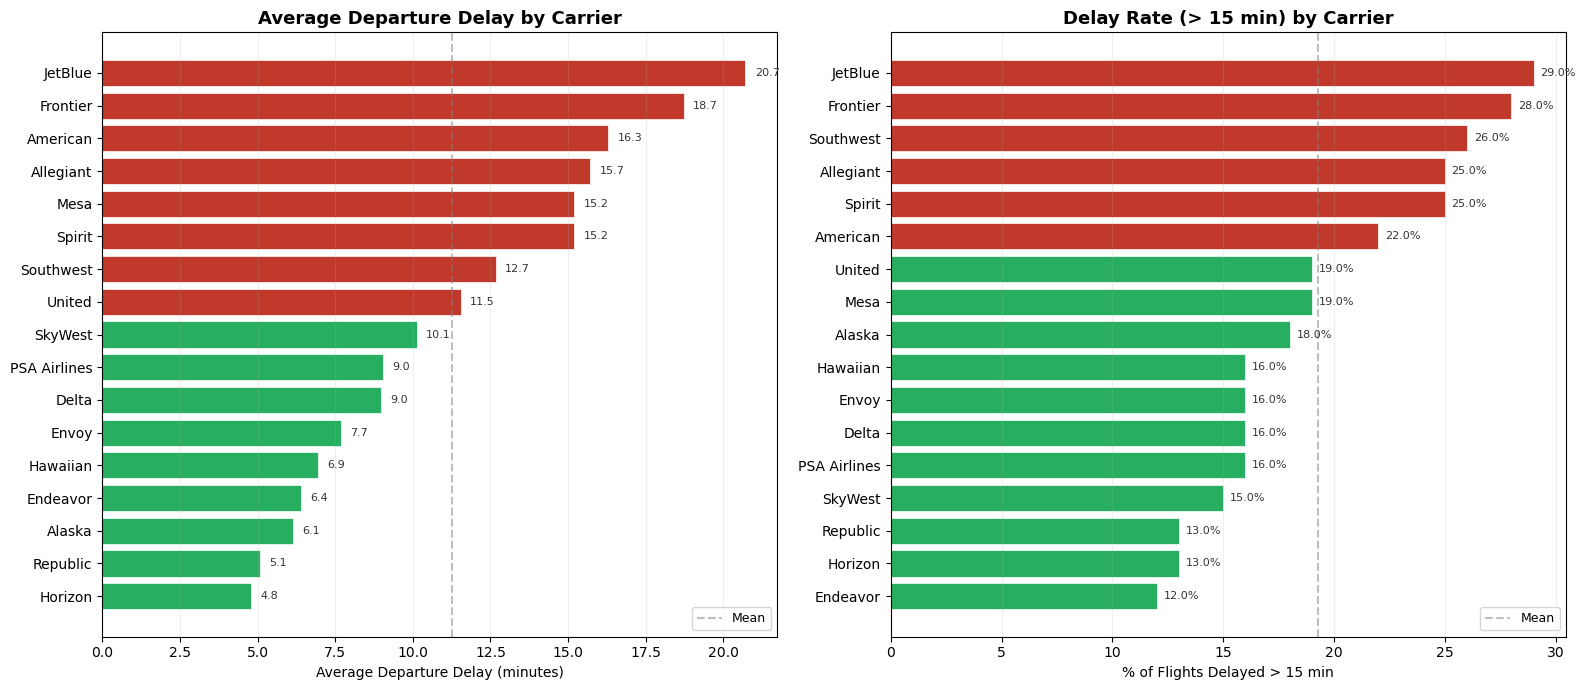

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left panel: Average delay
carrier_stats_sorted = carrier_stats.sort_values('avg_delay', ascending=True)
colors = ['#27ae60' if x < carrier_stats['avg_delay'].mean() else '#c0392b'
          for x in carrier_stats_sorted['avg_delay']]
bars = axes[0].barh(carrier_stats_sorted.index, carrier_stats_sorted['avg_delay'],
                    color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Average Departure Delay (minutes)', fontsize=10)
axes[0].set_title('Average Departure Delay by Carrier', fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].axvline(x=carrier_stats['avg_delay'].mean(), color='gray',
                linestyle='--', alpha=0.5, label='Mean')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.2)
# Value labels
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}', va='center', fontsize=8, color='#333')

# Right panel: Delay rate
carrier_stats_sorted2 = carrier_stats.sort_values('delay_rate', ascending=True)
colors2 = ['#27ae60' if x < carrier_stats['delay_rate'].mean() else '#c0392b'
           for x in carrier_stats_sorted2['delay_rate']]
bars2 = axes[1].barh(carrier_stats_sorted2.index, carrier_stats_sorted2['delay_rate'] * 100,
                     color=colors2, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('% of Flights Delayed > 15 min', fontsize=10)
axes[1].set_title('Delay Rate (> 15 min) by Carrier', fontsize=13, fontweight='bold')
axes[1].axvline(x=carrier_stats['delay_rate'].mean() * 100, color='gray',
                linestyle='--', alpha=0.5, label='Mean')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.2)
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}%', va='center', fontsize=8, color='#333')

plt.tight_layout()
plt.show()

JetBlue and Frontier come in last by both measures. JetBlue averages over 20 minutes of delay per flight, and Frontier is not far behind. Hawaiian and Alaska are at the other end, for big airlines, both under 7 minutes on average. One thing that jumped out: the median delay is actually negative for most carriers, meaning the typical flight departs a few minutes early. The averages get dragged up by the long tail of really bad delays.

### 7.2 Q2: Which airlines have the best cost-to-performance ratio?

The BTS on-time dataset does not include ticket prices, so we cannot compute a true cost-to-performance ratio. Instead, we approximate value by comparing each carrier's delay performance against its average flight distance. Longer routes face more operational complexity, so a carrier flying mostly long-haul routes with low delay rates is arguably delivering more value per flight.

In [12]:
carrier_value = df_delays.groupby('CARRIER_NAME', observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    avg_distance=('DISTANCE', 'mean'),
    total_flights=('DEP_DELAY', 'count')
).round(2)

carrier_value['miles_per_delay_min'] = (carrier_value['avg_distance'] / carrier_value['avg_delay'].clip(lower=0.1)).round(1)
carrier_value = carrier_value.sort_values('miles_per_delay_min', ascending=False)

print("Carrier Value (miles per minute of avg delay — higher = better):")
print(carrier_value.to_string())

Carrier Value (miles per minute of avg delay — higher = better):
              avg_delay  delay_rate  avg_distance  total_flights  miles_per_delay_min
CARRIER_NAME                                                                         
Alaska         6.140000        0.18   1381.520020         886946           225.000000
Hawaiian       6.950000        0.16    922.159973         289550           132.699997
Delta          8.980000        0.16    948.309998        3582645           105.599998
Republic       5.080000        0.13    516.690002        1206301           101.699997
United        11.540000        0.19   1145.280029        2511687            99.199997
Horizon        4.800000        0.13    444.019989         196811            92.500000
Envoy          7.680000        0.16    513.280029         987752            66.800003
Spirit        15.200000        0.25    995.210022         921538            65.500000
Endeavor       6.390000        0.12    418.350006         879074           

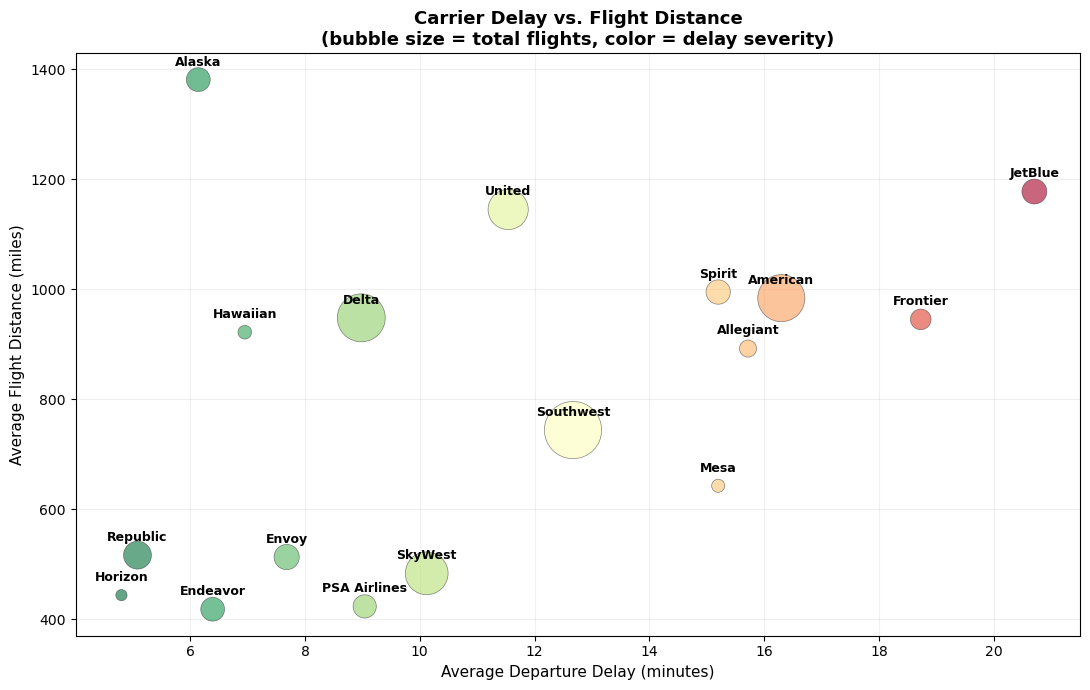

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))

sizes = carrier_value['total_flights'] / 3000
scatter = ax.scatter(carrier_value['avg_delay'], carrier_value['avg_distance'],
                     s=sizes, alpha=0.6, c=carrier_value['avg_delay'],
                     cmap='RdYlGn_r', edgecolors='#333', linewidth=0.5, zorder=3)

for carrier in carrier_value.index:
    ax.annotate(carrier,
                (carrier_value.loc[carrier, 'avg_delay'],
                 carrier_value.loc[carrier, 'avg_distance']),
                fontsize=9, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=11)
ax.set_ylabel('Average Flight Distance (miles)', fontsize=11)
ax.set_title('Carrier Delay vs. Flight Distance\n(bubble size = total flights, color = delay severity)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Alaska is very interesting here. They fly some of the longest routes on average but still keep delays low, which is why they top the miles-per-delay-minute metric. Flying 1,300+ miles with an average delay under 7 minutes takes solid operations. The regional carriers (Envoy, Republic, SkyWest) are clustered in the lower left since they mostly fly short hops. JetBlue and Frontier both sit in the high-delay zone no matter the distance, which says their problems are operational, not route-related.

### 7.3 Q3: Which airports cause the biggest delays across the network?

We group by origin airport and calculate average departure delay and delay rate. Airports with high average delays may be bottlenecks that cascade delays through the network. We focus on our 75 airports with FAA metadata so we can also examine whether hub size correlates with delay severity.

In [14]:
print(df_delays['hub_size'].notna().sum(), "out of", len(df_delays))
print(df_delays['hub_size'].value_counts())

22523156 out of 26048566
hub_size
L    17021648
M     4619527
S      881981
Name: count, dtype: int64


In [15]:
top_75 = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].unique()
airport_stats = df_delays[df_delays['ORIGIN'].isin(top_75)].groupby('ORIGIN', observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    delay_rate=('DEP_DEL15', 'mean')
).round(2)

airport_stats = airport_stats[airport_stats['flights'] > 0]
airport_stats = airport_stats.sort_values('avg_delay', ascending=False)
print(f"Airports analyzed: {len(airport_stats)}")
print(f"\nTop 15 worst airports by average departure delay:")
print(airport_stats.head(15).to_string())
print(f"\nBottom 5 (best):")
print(airport_stats.tail(5).to_string())

Airports analyzed: 75

Top 15 worst airports by average departure delay:
        flights  avg_delay  median_delay  delay_rate
ORIGIN                                              
FLL      344689  17.590000           0.0        0.27
SJU      124554  17.549999          -2.0        0.24
MCO      588078  16.930000           0.0        0.26
MIA      402270  16.910000          -1.0        0.25
PBI      100636  16.030001          -2.0        0.23
BWI      347632  15.800000           3.0        0.30
DFW     1122319  15.520000          -2.0        0.24
EWR      469477  15.340000          -2.0        0.24
MDW      297831  15.190000           3.0        0.30
DAL      264817  14.980000           2.0        0.29
DEN     1104027  14.790000           0.0        0.26
JFK      462125  14.550000          -2.0        0.22
LAS      683736  13.930000           0.0        0.25
IAH      471900  13.800000          -1.0        0.21
HOU      206549  13.180000           1.0        0.26

Bottom 5 (best):
        

In [16]:
print(df_delays['DEP_DELAY'].isna().sum(), "out of", len(df_delays), "have null DEP_DELAY")

0 out of 26048566 have null DEP_DELAY


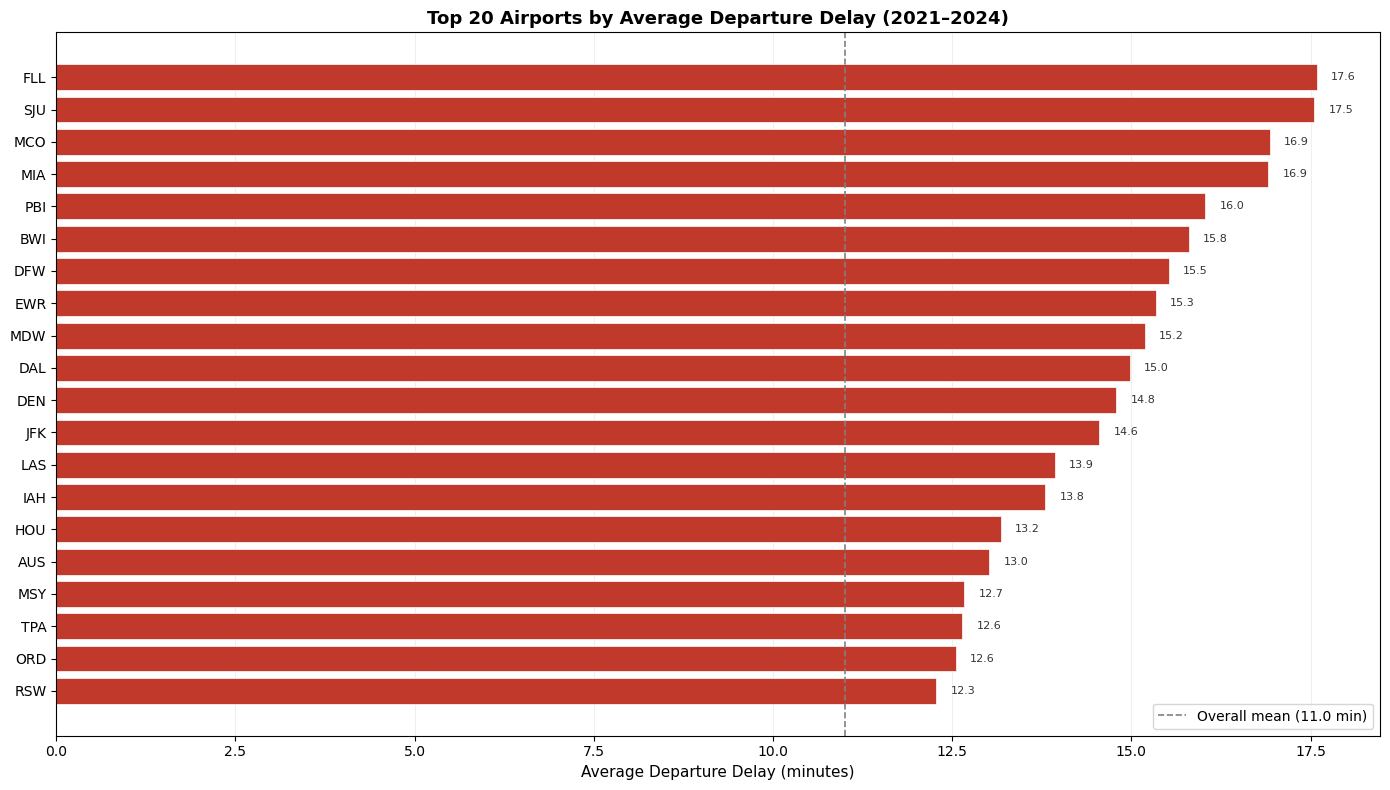

In [17]:
top_airports_delay = airport_stats.head(20)
overall_mean = airport_stats['avg_delay'].mean()

fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#c0392b' if x > overall_mean else '#2c7bb6'
          for x in top_airports_delay['avg_delay'][::-1]]
bars = ax.barh(top_airports_delay.index[::-1], top_airports_delay['avg_delay'][::-1],
               color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(x=overall_mean, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall mean ({overall_mean:.1f} min)')

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}', va='center', fontsize=8, color='#333')

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=11)
ax.set_title('Top 20 Airports by Average Departure Delay (2021–2024)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [18]:
hub_delay = df_delays[df_delays['hub_size'].notna()].groupby('hub_size', observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
).round(3)

print("Delay by hub size:")
print(hub_delay)

groups = [group['DEP_DELAY'].dropna() for name, group in df_delays[df_delays['hub_size'].notna()].groupby('hub_size', observed=True)]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA: F = {f_stat:.2f}, p = {p_val:.2e}")
print("Reject null (delays differ by hub size)" if p_val < 0.05 else "Fail to reject null")

Delay by hub size:
          avg_delay  delay_rate   flights
hub_size                                 
L            12.350       0.210  17021648
M            10.415       0.190   4619527
S             9.605       0.165    881981

One-way ANOVA: F = 3519.97, p = 0.00e+00
Reject null (delays differ by hub size)


The ANOVA result is significant (F = 3519.97, p $\approx$ 0), so delay differences across hub sizes are not just noise. Large hubs average about 12.35 minutes of delay, medium hubs 10.4, and small hubs 9.6. That's not a huge surprise since bigger airports deal with more congestion and more connecting traffic. But the gap between hub sizes is actually smaller than the gap between the best and worst carriers, which tells us the airline you pick probably matters more than the airport you are flying from.

### 7.4 Q4: What are the most common causes of delays?

The BTS data breaks delays into five categories: carrier, weather, NAS (National Aviation System — air traffic control, airport operations), security, and late aircraft. These columns are only populated for flights delayed more than 15 minutes, so we filter to delayed flights only. We examine both the total minutes attributed to each cause and the frequency with which each cause appears.

In [12]:
delay_causes = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

delayed_flights = df_delays[df_delays['CARRIER_DELAY'].notna()].copy()
print(f"Flights with delay cause data: {len(delayed_flights):,}")

cause_totals = delayed_flights[delay_causes].sum().sort_values(ascending=False)
cause_pct = (cause_totals / cause_totals.sum() * 100).round(1)

print(f"\nTotal delay minutes by cause:")
for cause, mins in cause_totals.items():
    label = cause.replace('_DELAY', '').title()
    pct = round(float(cause_pct[cause]), 1)
    print(f"  {label:20s}: {mins:>15,.0f} min ({pct}%)")

Flights with delay cause data: 5,170,431

Total delay minutes by cause:
  Late_Aircraft       :     136,558,512 min (38.6%)
  Carrier             :     132,542,432 min (37.5%)
  Nas                 :      63,032,340 min (17.8%)
  Weather             :      20,791,740 min (5.9%)
  Security            :         803,121 min (0.2%)


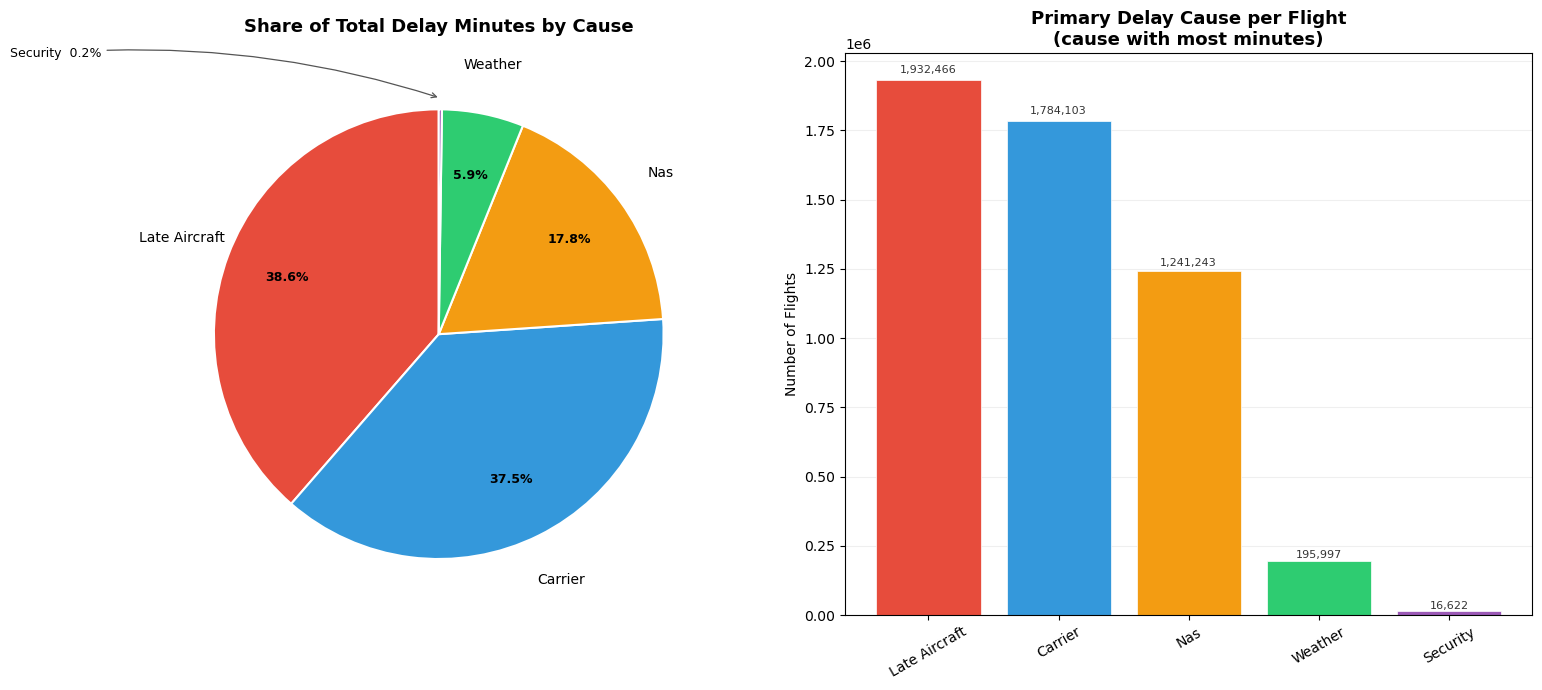

In [20]:
delayed_flights['primary_cause'] = delayed_flights[delay_causes].idxmax(axis=1)
primary_counts = delayed_flights['primary_cause'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Pie chart
labels = [c.replace('_DELAY', '').replace('_', ' ').title() for c in cause_totals.index]
pie_colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']
total = cause_totals.sum()

# Suppress autopct for tiny slices (< 3%) — annotate them separately with leader lines
def _autopct(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

wedges, texts, autotexts = axes[0].pie(
    cause_totals, labels=None, autopct=_autopct,
    startangle=90, colors=pie_colors,
    pctdistance=0.72,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

# Place labels: normal text for large slices, leader-line annotation for small ones
for wedge, label, val in zip(wedges, labels, cause_totals):
    pct = val / total * 100
    ang = np.radians((wedge.theta1 + wedge.theta2) / 2)
    cos_a, sin_a = np.cos(ang), np.sin(ang)
    if pct >= 3:
        axes[0].text(cos_a * 1.22, sin_a * 1.22, label,
                     ha='center', va='center', fontsize=10)
    else:
        ha = 'right'
        xt = -1.5
        yt = sin_a * 1.25
        axes[0].annotate(f'{label}  {pct:.1f}%',
                         xy=(cos_a * 1.05, sin_a * 1.05),
                         xytext=(xt, yt),
                         fontsize=9, ha=ha, va='center',
                         arrowprops=dict(arrowstyle='->', color='#555',
                                         lw=0.9, connectionstyle='arc3,rad=-0.1'))

axes[0].set_title('Share of Total Delay Minutes by Cause',
                  fontsize=13, fontweight='bold', pad=15)

# Right: Bar chart
primary_labels = [c.replace('_DELAY', '').replace('_', ' ').title() for c in primary_counts.index]
bar_colors = [pie_colors[list(cause_totals.index).index(c)] if c in cause_totals.index
              else '#95a5a6' for c in primary_counts.index]
bars = axes[1].bar(primary_labels, primary_counts.values, color=bar_colors,
                   edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('Number of Flights', fontsize=10)
axes[1].set_title('Primary Delay Cause per Flight\n(cause with most minutes)',
                  fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_axisbelow(True)

# Value labels
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + h*0.01,
                 f'{h:,.0f}', ha='center', va='bottom', fontsize=8, color='#333')

plt.tight_layout()
plt.show()

This is one of the more interesting findings. Late aircraft and carrier-caused delays account for over three-quarters of all delay minutes combined (38.6% and 37.5%). Weather? Just 5.9%. Air traffic control and airport operations (NAS) add 17.8%, and security is basically a rounding error at 0.2%. Most people would probably guess that weather is the biggest cause, but the data says otherwise. The delays people complain about are overwhelmingly caused by operational stuff: planes arriving late from previous legs, crew problems, maintenance, and gate availability. Delays are causing delays.

### 7.5 Q5: Are certain routes worse than others?

We create an origin-destination route column and identify the routes with the highest average delays and highest delay rates. We filter to routes with at least 1,000 flights over the 4-year period to avoid small-sample noise.

In [21]:
top_75 = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].unique()

df_top = df_delays[(df_delays['ORIGIN'].isin(top_75)) & (df_delays['DEST'].isin(top_75))].copy()
df_top['ROUTE'] = df_top['ORIGIN'].astype(str) + ' → ' + df_top['DEST'].astype(str)
route_stats = df_top.groupby('ROUTE', observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    avg_distance=('DISTANCE', 'mean')
).round(2)

route_stats = route_stats[route_stats['flights'] >= 1000]
print(f"Routes with 1,000+ flights (top 75 airports only): {len(route_stats):,}")

print(f"\nTop 15 worst routes by average delay:")
print(route_stats.sort_values('avg_delay', ascending=False).head(15).to_string())

print(f"\nTop 10 best routes (lowest avg delay):")
print(route_stats.sort_values('avg_delay', ascending=True).head(10).to_string())

Routes with 1,000+ flights (top 75 airports only): 2,633

Top 15 worst routes by average delay:
           flights  avg_delay  delay_rate  avg_distance
ROUTE                                                  
ONT → JFK     1124  38.169998        0.38        2429.0
BUR → JFK     1393  37.730000        0.43        2465.0
SAN → FLL     1455  34.730000        0.37        2269.0
SJU → DCA     1367  34.389999        0.41        1554.0
ANC → DFW     1200  34.040001        0.34        3043.0
BDL → SJU     3157  33.990002        0.45        1666.0
SMF → JFK     1128  33.220001        0.37        2521.0
JFK → SMF     1134  33.119999        0.45        2521.0
DFW → GEG     2239  32.910000        0.38        1477.0
IAH → JFK     1572  31.860001        0.37        1417.0
SJU → BDL     3164  30.610001        0.41        1666.0
SAT → JFK     1701  29.969999        0.28        1587.0
JFK → ONT     1129  28.129999        0.41        2429.0
MIA → SAN     1566  26.120001        0.32        2267.0
SAT → BO

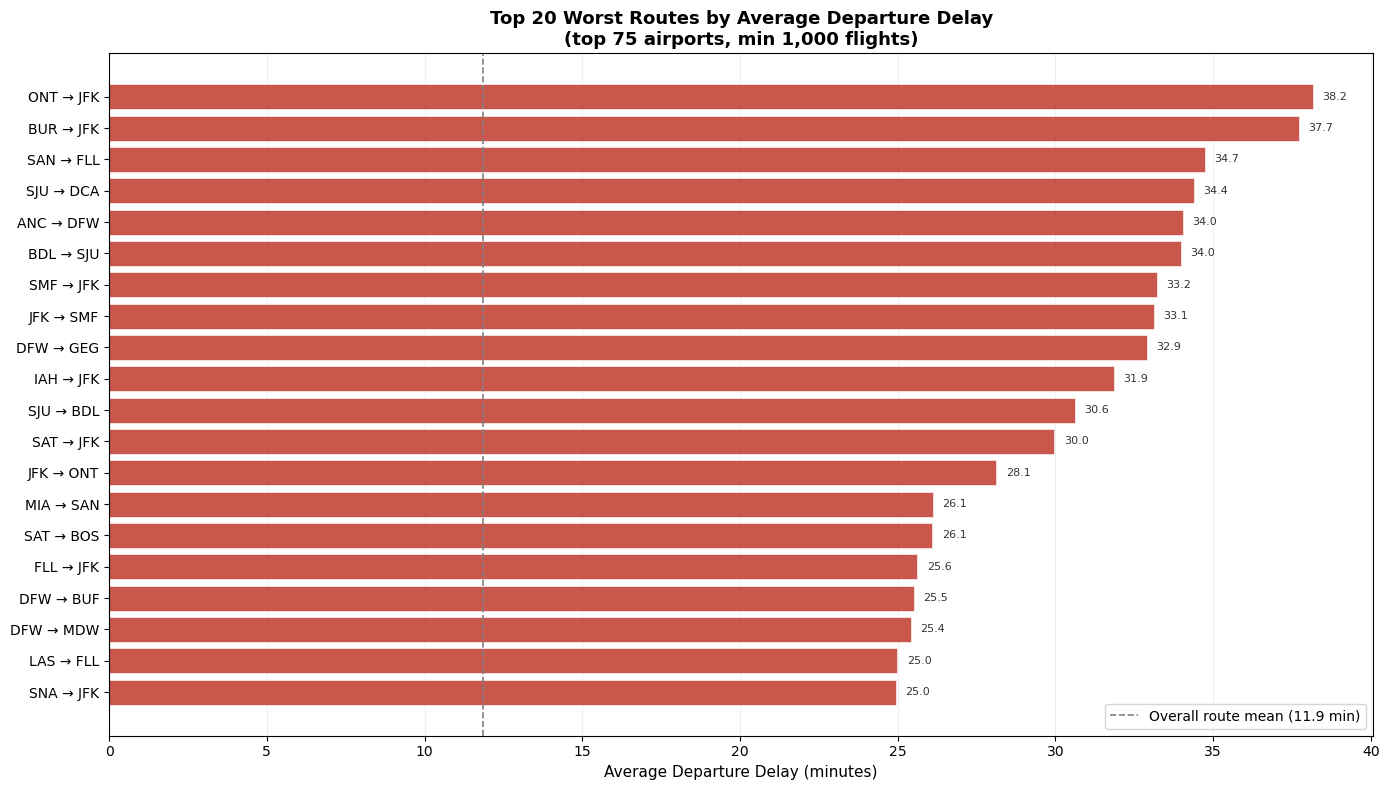

In [22]:
fig, ax = plt.subplots(figsize=(14, 8))

worst_routes = route_stats.sort_values('avg_delay', ascending=False).head(20)
route_mean = route_stats['avg_delay'].mean()

bars = ax.barh(worst_routes.index[::-1], worst_routes['avg_delay'][::-1],
               color='#c0392b', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(x=route_mean, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall route mean ({route_mean:.1f} min)')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}', va='center', fontsize=8, color='#333')

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=11)
ax.set_title('Top 20 Worst Routes by Average Departure Delay\n(top 75 airports, min 1,000 flights)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [ ]:
# Build coordinate lookup from the merged data
coord_lookup = df_delays[df_delays['latitude'].notna()].groupby('ORIGIN', observed=True).agg(
    lat=('latitude', 'first'),
    lon=('longitude', 'first')
).to_dict('index')

worst_25 = route_stats.sort_values('avg_delay', ascending=False).head(25)
best_25 = route_stats.sort_values('avg_delay', ascending=True).head(25)

# Get city names for airports
city_lookup = df_delays[df_delays['ORIGIN_CITY_NAME'].notna()].groupby('ORIGIN', observed=True)['ORIGIN_CITY_NAME'].first().to_dict()

def great_circle_points(lat1, lon1, lat2, lon2, n_points=30):
    """Interpolate points along a great circle arc between two coordinates."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    d = np.arccos(np.sin(lat1)*np.sin(lat2) + np.cos(lat1)*np.cos(lat2)*np.cos(lon2-lon1))
    if d < 1e-10:
        return [[np.degrees(lat1), np.degrees(lon1)]]
    points = []
    for f in np.linspace(0, 1, n_points):
        A = np.sin((1-f)*d) / np.sin(d)
        B = np.sin(f*d) / np.sin(d)
        x = A*np.cos(lat1)*np.cos(lon1) + B*np.cos(lat2)*np.cos(lon2)
        y = A*np.cos(lat1)*np.sin(lon1) + B*np.cos(lat2)*np.sin(lon2)
        z = A*np.sin(lat1) + B*np.sin(lat2)
        lat = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        lon = np.degrees(np.arctan2(y, x))
        points.append([lat, lon])
    return points

def build_route_map(route_df, color, title, label):
    m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')
    
    # Track which routes connect to each airport
    airport_route_info = {}
    route_airports = set()
    
    for idx, (route, row) in enumerate(route_df.iterrows()):
        rank = idx + 1
        origin, dest = route.split(' → ')
        if origin not in coord_lookup or dest not in coord_lookup:
            continue
        route_airports.update([origin, dest])
        
        route_detail = {
            'rank': rank,
            'origin': origin, 'dest': dest,
            'origin_city': city_lookup.get(origin, origin),
            'dest_city': city_lookup.get(dest, dest),
            'avg_delay': float(row['avg_delay']),
            'delay_rate': float(row['delay_rate']),
            'flights': int(row['flights']),
            'distance': int(row['avg_distance']),
        }
        for code in [origin, dest]:
            if code not in airport_route_info:
                airport_route_info[code] = []
            airport_route_info[code].append(route_detail)
        
        o = coord_lookup[origin]
        d = coord_lookup[dest]
        arc = great_circle_points(o['lat'], o['lon'], d['lat'], d['lon'])
        weight = max(2, min(6, row['avg_delay'] / 8))
        
        # Ordinal suffix
        def ordinal(n):
            if 11 <= n % 100 <= 13:
                return f"{n}th"
            return f"{n}" + {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
        
        # Route line popup
        route_popup = (
            f"<div style='font-family: Arial; min-width: 220px;'>"
            f"<div style='font-size: 11px; color: white; background: {color}; "
            f"display: inline-block; padding: 2px 8px; border-radius: 3px; "
            f"margin-bottom: 6px; font-weight: bold;'>"
            f"#{rank} {label} route</div>"
            f"<div style='font-size: 14px; font-weight: bold; color: {color}; "
            f"margin-bottom: 4px;'>✈ {origin} → {dest}</div>"
            f"<div style='color: #666; font-size: 11px; margin-bottom: 8px;'>"
            f"{city_lookup.get(origin, origin)} → {city_lookup.get(dest, dest)}</div>"
            f"<table style='font-size: 12px; width: 100%; border-collapse: collapse;'>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Distance</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{int(row['avg_distance']):,} mi</td></tr>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Flights (4yr)</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{int(row['flights']):,}</td></tr>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Avg Delay</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{row['avg_delay']:.1f} min</td></tr>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Delay Rate</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{row['delay_rate']*100:.1f}%</td></tr>"
            f"</table></div>"
        )
        
        folium.PolyLine(
            locations=arc,
            color=color,
            weight=weight,
            opacity=0.6,
            tooltip=f"<b>#{rank} — {origin} → {dest}</b> | {row['avg_delay']:.1f} min avg delay",
            popup=folium.Popup(route_popup, max_width=280)
        ).add_to(m)
    
    # Add airport markers with popup showing all connected routes
    for code in route_airports:
        info = coord_lookup[code]
        routes = airport_route_info.get(code, [])
        city = city_lookup.get(code, '')
        
        # Sort by rank
        routes_sorted = sorted(routes, key=lambda r: r['rank'])
        
        def ordinal(n):
            if 11 <= n % 100 <= 13:
                return f"{n}th"
            return f"{n}" + {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
        
        popup_html = (
            f"<div style='font-family: Arial; min-width: 270px; max-height: 400px; overflow-y: auto;'>"
            f"<div style='font-size: 16px; font-weight: bold; color: {color}; "
            f"margin-bottom: 2px;'>✈ {code}</div>"
            f"<div style='color: #666; font-size: 12px; margin-bottom: 10px;'>"
            f"{city}</div>"
            f"<div style='color: #888; font-size: 11px; margin-bottom: 8px;'>"
            f"{len(routes_sorted)} connected route{'s' if len(routes_sorted) != 1 else ''} "
            f"in the {label} 25</div>"
        )
        
        for r in routes_sorted:
            other = r['dest'] if r['origin'] == code else r['origin']
            other_city = r['dest_city'] if r['origin'] == code else r['origin_city']
            direction = '→' if r['origin'] == code else '←'
            rank = r['rank']
            
            popup_html += (
                f"<div style='background: #f8f8f8; border-radius: 5px; padding: 8px 10px; "
                f"margin-bottom: 6px; border-left: 3px solid {color};'>"
                f"<div style='display: flex; justify-content: space-between; align-items: center;'>"
                f"<span style='font-weight: bold; font-size: 13px;'>"
                f"{code} {direction} {other}</span>"
                f"<span style='font-size: 10px; color: white; background: {color}; "
                f"padding: 1px 6px; border-radius: 3px; font-weight: bold;'>"
                f"#{rank}</span></div>"
                f"<div style='color: #666; font-size: 11px; margin-bottom: 4px;'>"
                f"{other_city} — {ordinal(rank)} {label} route overall</div>"
                f"<table style='font-size: 11px; width: 100%;'>"
                f"<tr><td style='color: #888;'>Distance: <b>{r['distance']:,} mi</b></td>"
                f"<td style='color: #888;'>Flights: <b>{r['flights']:,}</b></td></tr>"
                f"<tr><td style='color: #888;'>Avg Delay: <b>{r['avg_delay']:.1f} min</b></td>"
                f"<td style='color: #888;'>Delay Rate: <b>{r['delay_rate']*100:.1f}%</b></td></tr>"
                f"</table></div>"
            )
        
        popup_html += "</div>"
        
        folium.Marker(
            location=[info['lat'], info['lon']],
            tooltip=f"<b>{code}</b> — {city}<br><i>Click for {len(routes_sorted)} route{'s' if len(routes_sorted) != 1 else ''}</i>",
            popup=folium.Popup(popup_html, max_width=310),
            icon=folium.DivIcon(
                html=(f'<div style="font-size: 16px; color: #333; cursor: pointer; '
                      f'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>'),
                icon_size=(20, 20),
                icon_anchor=(10, 10)
            )
        ).add_to(m)
    
    # Title + legend
    title_html = f"""
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
         z-index: 1000; background: white; padding: 8px 18px; border: 2px solid {color};
         border-radius: 5px; font-size: 15px; font-weight: bold; color: {color};">
        {title}
    </div>
    <div style="position: fixed; bottom: 15px; left: 15px; z-index: 1000;
         background: white; padding: 6px 10px; border: 1px solid #ccc;
         border-radius: 4px; font-size: 11px; color: #666;">
        Click any ✈ for airport route details &bull; Click any route arc for flight info
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))
    return m

# Map 1: 25 Worst routes
print("25 Worst Routes by Average Departure Delay:")
m_worst = build_route_map(worst_25, '#c0392b', '25 Worst Routes by Avg Departure Delay', 'worst')
display(m_worst)

# Map 2: 25 Best routes
print("\n25 Best Routes by Average Departure Delay:")
m_best = build_route_map(best_25, '#27ae60', '25 Best Routes by Avg Departure Delay', 'best')
display(m_best)

25 Worst Routes by Average Departure Delay:



25 Best Routes by Average Departure Delay:


Looking at the maps, there is a clear geographic story. Florida airports show up all over the worst-routes list. FLL, MCO, and MIA keep appearing, especially on long cross-country routes to the Northeast. The best routes tend to be short western hops and Hawaiian inter-island flights, which makes sense since shorter flights have less that can go wrong and Hawaii has minimal airspace congestion. The arc thickness also shows that the worst routes tend to be longer distances. We look at the distance-delay relationship more carefully in Q9.

### 7.6 Q6: Do delays vary by season?

We categorize months into four seasons and compare average departure delay and delay rates. We use one-way ANOVA to test whether mean delays differ significantly across seasons, then Tukey HSD post-hoc tests (7.13.4) to identify which specific pairs are responsible.

In [24]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}

df_delays['SEASON'] = df_delays['MONTH'].map(season_map)

season_stats = df_delays.groupby('SEASON', observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    delay_rate=('DEP_DEL15', 'mean')
).round(3)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_stats = season_stats.loc[season_order]
print("Seasonal delay statistics:")
print(season_stats.to_string())

season_groups = [group['DEP_DELAY'].dropna() for name, group in df_delays.groupby('SEASON', observed=True)]
f_stat, p_val = stats.f_oneway(*season_groups)
print(f"\nOne-way ANOVA: F = {f_stat:.2f}, p = {p_val:.2e}")

Seasonal delay statistics:
        flights  avg_delay  median_delay  delay_rate
SEASON                                              
Winter  5935398  11.223000          -2.0       0.194
Spring  6514832  11.236000          -2.0       0.195
Summer  6830218  16.322001          -1.0       0.247
Fall    6768118   7.742000          -3.0       0.160

One-way ANOVA: F = 30533.40, p = 0.00e+00


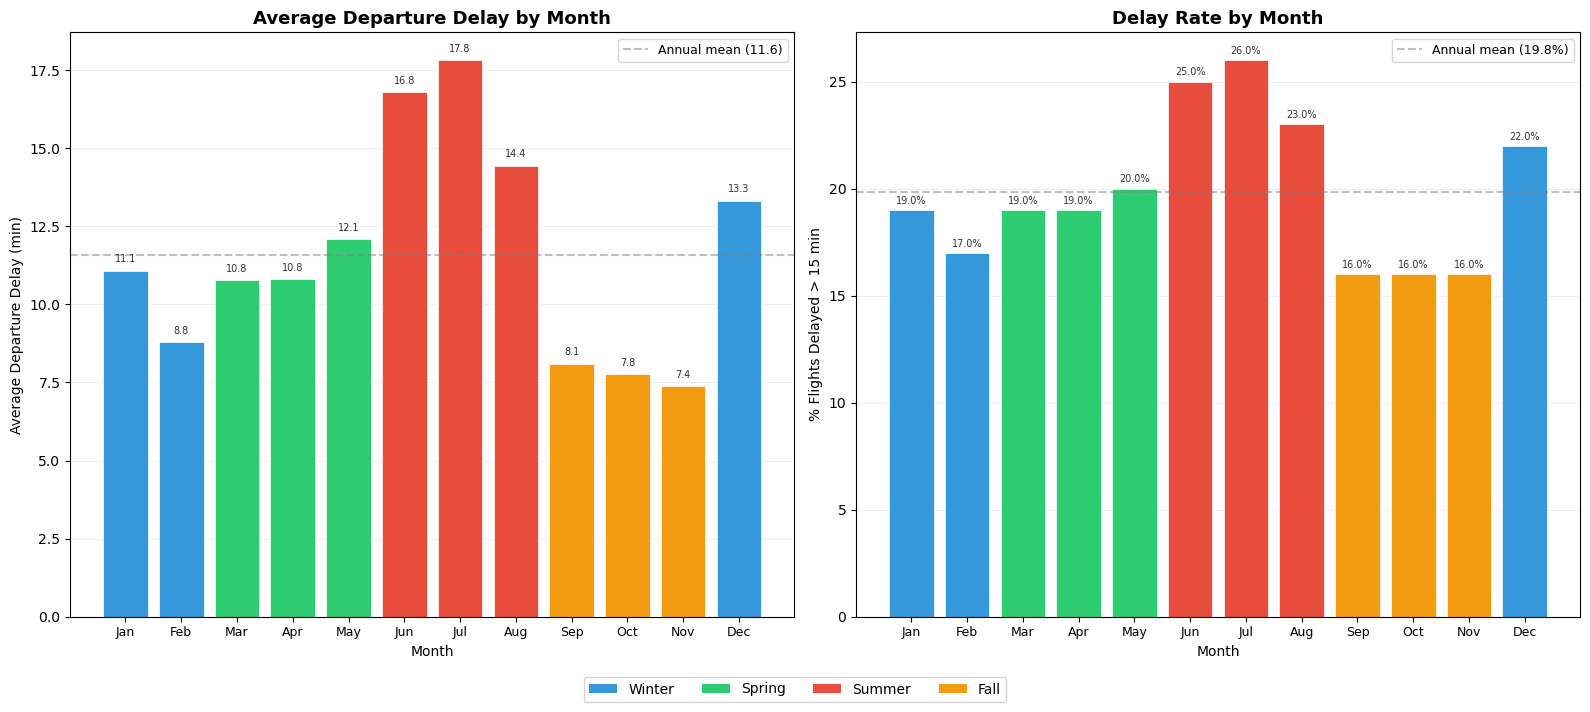

In [ ]:
monthly = df_delays.groupby('MONTH', observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e74c3c', 'Fall': '#f39c12'}
month_colors = [colors[season_map[m]] for m in monthly.index]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Left: Average delay
bars = axes[0].bar(monthly.index, monthly['avg_delay'], color=month_colors,
                   edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Month', fontsize=10)
axes[0].set_ylabel('Average Departure Delay (min)', fontsize=10)
axes[0].set_title('Average Departure Delay by Month', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, fontsize=9)
axes[0].axhline(y=monthly['avg_delay'].mean(), color='gray', linestyle='--',
                alpha=0.5, label=f'Annual mean ({monthly["avg_delay"].mean():.1f})')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)
axes[0].set_axisbelow(True)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=7, color='#333')

# Right: Delay rate
bars2 = axes[1].bar(monthly.index, monthly['delay_rate'] * 100, color=month_colors,
                    edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Month', fontsize=10)
axes[1].set_ylabel('% Flights Delayed > 15 min', fontsize=10)
axes[1].set_title('Delay Rate by Month', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels, fontsize=9)
axes[1].axhline(y=monthly['delay_rate'].mean() * 100, color='gray', linestyle='--',
                alpha=0.5, label=f'Annual mean ({monthly["delay_rate"].mean()*100:.1f}%)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_axisbelow(True)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=7, color='#333')

# Season legend
legend_elements = [Patch(facecolor=c, label=s) for s, c in colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

Summer is by far the worst season. June through August average 16 minutes of delay, with about 25% of flights delayed more than 15 minutes. Fall is the opposite, with September through November averaging under 8 minutes. The ANOVA confirms this isn't random (F = 30,533.4, p $\approx$ 0). What is surprising is that winter actually performs better than summer. You would think snow and ice would cause the most problems, but airlines seem to handle predictable cold-weather operations better than the sudden thunderstorms and other unpredictable weather in summer. Summer also brings higher passenger volumes, which does not help.

### 7.7 Q7: Does weather significantly predict delay length, or is it less impactful than people assume?

We first quantify how much of the total delay burden is weather-attributed (using the BTS WEATHER_DELAY column). Then we test whether our continuous weather variables (precipitation, snowfall, wind speed, temperature) correlate with departure delay using Pearson correlation and a multivariate OLS regression. This lets us estimate how many minutes of delay each weather variable contributes while controlling for the others.

In [26]:
delayed_wx = df_delays[df_delays['WEATHER_DELAY'].notna()]
cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
cause_shares = delayed_wx[cause_cols].sum()
cause_shares_pct = (cause_shares / cause_shares.sum() * 100).round(1)

print("Share of total delay minutes by cause:")
for col in cause_cols:
    label = col.replace('_DELAY', '').title()
    pct = round(float(cause_shares_pct[col]), 1)
    print(f"  {label:20s}: {pct}%")

print(f"\nWeather accounts for only {round(float(cause_shares_pct['WEATHER_DELAY']), 1)}% of total delay minutes.")

Share of total delay minutes by cause:
  Carrier             : 37.5%
  Weather             : 5.9%
  Nas                 : 17.8%
  Security            : 0.2%
  Late_Aircraft       : 38.6%

Weather accounts for only 5.9% of total delay minutes.


In [27]:
weather_cols = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_min', 
                'max_wind_gust', 'temp_range', 'weather_severity']

corr_with_delay = df_weather[weather_cols + ['DEP_DELAY']].corr()['DEP_DELAY'].drop('DEP_DELAY').sort_values(ascending=False)

print("Pearson correlation with DEP_DELAY:")
for var, r in corr_with_delay.items():
    print(f"  {var:20s}: r = {r:.4f}")

Pearson correlation with DEP_DELAY:
  precipitation       : r = 0.0723
  max_wind_gust       : r = 0.0540
  weather_severity    : r = 0.0445
  temp_min            : r = 0.0366
  snowfall            : r = 0.0321
  temp_max            : r = 0.0260
  avg_wind            : r = 0.0230
  temp_range          : r = -0.0205


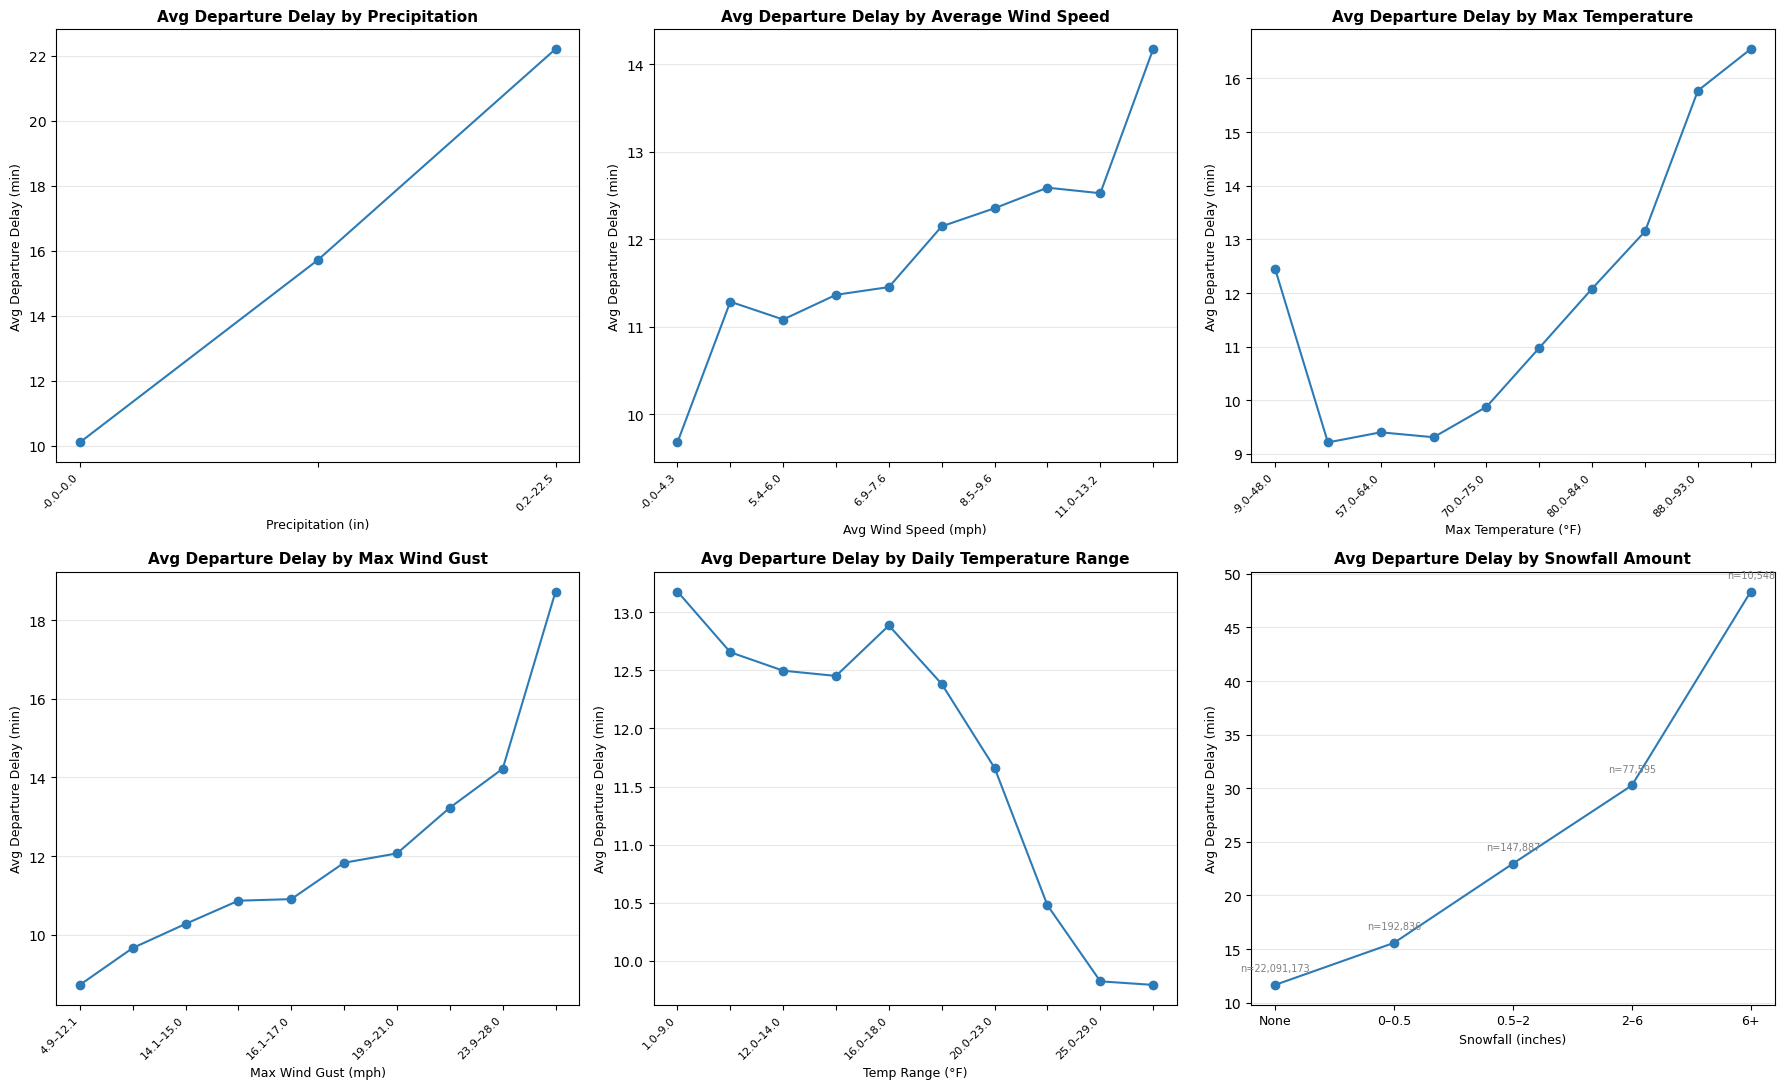

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Config for the 5 decile variables
decile_vars = [
    ('precipitation', 'Precipitation (in)',    'Precipitation'),
    ('avg_wind',      'Avg Wind Speed (mph)',  'Average Wind Speed'),
    ('temp_max',      'Max Temperature (°F)',  'Max Temperature'),
    ('max_wind_gust', 'Max Wind Gust (mph)',   'Max Wind Gust'),
    ('temp_range',    'Temp Range (°F)',       'Daily Temperature Range'),
]

for ax, (var, xlabel, title) in zip(axes.flatten(), decile_vars):
    df_weather['_bin'] = pd.qcut(df_weather[var], q=10, duplicates='drop')
    binned = df_weather.groupby('_bin', observed=True)['DEP_DELAY'].mean()

    # Build clean tick labels: show the range for each bin
    labels = [f"{iv.left:.1f}–{iv.right:.1f}" for iv in binned.index]

    ax.plot(range(len(binned)), binned.values, marker='o', linewidth=1.5,
            markersize=6, color='#2c7bb6')
    ax.set_xticks(range(len(binned)))
    # Show every other label to prevent overlap
    display_labels = [labels[i] if i % 2 == 0 else '' for i in range(len(labels))]
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Avg Departure Delay by {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Avg Departure Delay (min)', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Snowfall: manual bins (zero-inflated, qcut fails)
ax = axes.flatten()[5]
snow_bins = pd.cut(df_weather['snowfall'],
                   bins=[-0.01, 0, 0.5, 2.0, 6.0, 100],
                   labels=['None', '0–0.5', '0.5–2', '2–6', '6+'])
snow_delay = df_weather.groupby(snow_bins, observed=True)['DEP_DELAY'].mean()
snow_counts = df_weather.groupby(snow_bins, observed=True)['DEP_DELAY'].count()

ax.plot(range(len(snow_delay)), snow_delay.values, marker='o', linewidth=1.5,
        markersize=6, color='#2c7bb6')
ax.set_xticks(range(len(snow_delay)))
ax.set_xticklabels(snow_delay.index, fontsize=9)
ax.set_title('Avg Departure Delay by Snowfall Amount', fontsize=11, fontweight='bold')
ax.set_xlabel('Snowfall (inches)', fontsize=9)
ax.set_ylabel('Avg Departure Delay (min)', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Annotate flight counts so the reader sees sample sizes
for i, (cat, n) in enumerate(snow_counts.items()):
    ax.annotate(f'n={n:,}', (i, snow_delay[cat]),
                textcoords='offset points', xytext=(0, 10),
                fontsize=7, ha='center', color='gray')

df_weather.drop(columns=['_bin'], inplace=True, errors='ignore')
plt.tight_layout()
plt.show()

In [ ]:
features = ['precipitation', 'snowfall', 'avg_wind', 'temp_max']
X = df_weather[features].dropna()
y = df_weather.loc[X.index, 'DEP_DELAY']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

print(f"OLS Regression: DEP_DELAY ~ weather variables")
print(f"R² = {model.score(X_scaled, y):.4f}")
print(f"\nStandardized coefficients (effect size per 1 SD change):")
for feat, coef in sorted(zip(features, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:22s}: {coef:+.4f} min per SD")

print(f"\nIntercept: {model.intercept_:.2f} min")
print(f"\nInterpretation: {model.score(X_scaled, y):.4f} means weather explains "
      f"~{model.score(X_scaled, y)*100:.1f}% of the variance in departure delays."
      f"\nThis is low R² but expected — most delay variance comes from operational factors "
      f"(crew scheduling, mechanical issues, cascading delays) not captured in daily weather.")

OLS Regression: DEP_DELAY ~ weather variables
R² = 0.0075

Standardized coefficients (effect size per 1 SD change):
  precipitation         : +3.7462 min per SD
  temp_max              : +1.9930 min per SD
  snowfall              : +1.7704 min per SD
  avg_wind              : +1.1372 min per SD

Intercept: 11.85 min

Interpretation:  of 0.0075 means weather explains ~0.8% of the variance in departure delays.
This is low R² but expected — most delay variance comes from operational factors (crew scheduling, mechanical issues, cascading delays) not captured in daily weather.


The regression gives us an $R^2$ of 0.0075, meaning weather explains less than 1% of the total variance in departure delay. Combined with the BTS breakdown showing that weather is only 5.9% of delay minutes, the picture is pretty clear: weather matters a lot less than people think.

Precipitation has the biggest effect at +3.75 minutes per standard deviation, which makes sense since rain affects both ground operations and flight paths. Snowfall and wind push delays up, too. Temperature has a small positive coefficient, probably because hotter days tend to coincide with the summer thunderstorm season.

A low $R^2$ doesn't mean weather is irrelevant, though. If there is a blizzard at O'Hare, that obviously causes delays. The issue is that across 22 million flights, the overwhelming majority see no weather impact at all, so when you run a regression on all of them, the signal gets diluted. The takeaway is that weather is a local, episodic problem, not a systemic one. Carrier and operational factors explain way more of the day-to-day variation.

Note: these figures are from the preliminary 4-variable weather-only OLS in this section. The full multivariate OLS in Section 7.12 uses standardized predictors across all variable groups and reports different coefficient values.

### 7.8 Q8: Are delays getting better or worse over time?

We track average departure delay and delay rate by year and by month across the full 2021–2024 window. 2021 is notable as a post-COVID recovery year with reduced flight volumes, which may distort comparisons.

In [30]:
yearly = df_delays.groupby('YEAR', observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean')
).round(3)

print("Yearly delay statistics:")
print(yearly.to_string())

for col in ['avg_delay', 'delay_rate']:
    yearly[f'{col}_pct_change'] = yearly[col].pct_change() * 100
    
print(f"\nYear-over-year % change:")
print(yearly[['avg_delay_pct_change', 'delay_rate_pct_change']].round(1).to_string())

Yearly delay statistics:
      flights  avg_delay  delay_rate
YEAR                                
2021  5892337      9.378       0.174
2022  6547839     12.570       0.213
2023  6759956     12.252       0.205
2024  6848434     12.165       0.203

Year-over-year % change:
      avg_delay_pct_change  delay_rate_pct_change
YEAR                                             
2021                   NaN                    NaN
2022                  34.0                   22.4
2023                  -2.5                   -3.8
2024                  -0.7                   -1.0


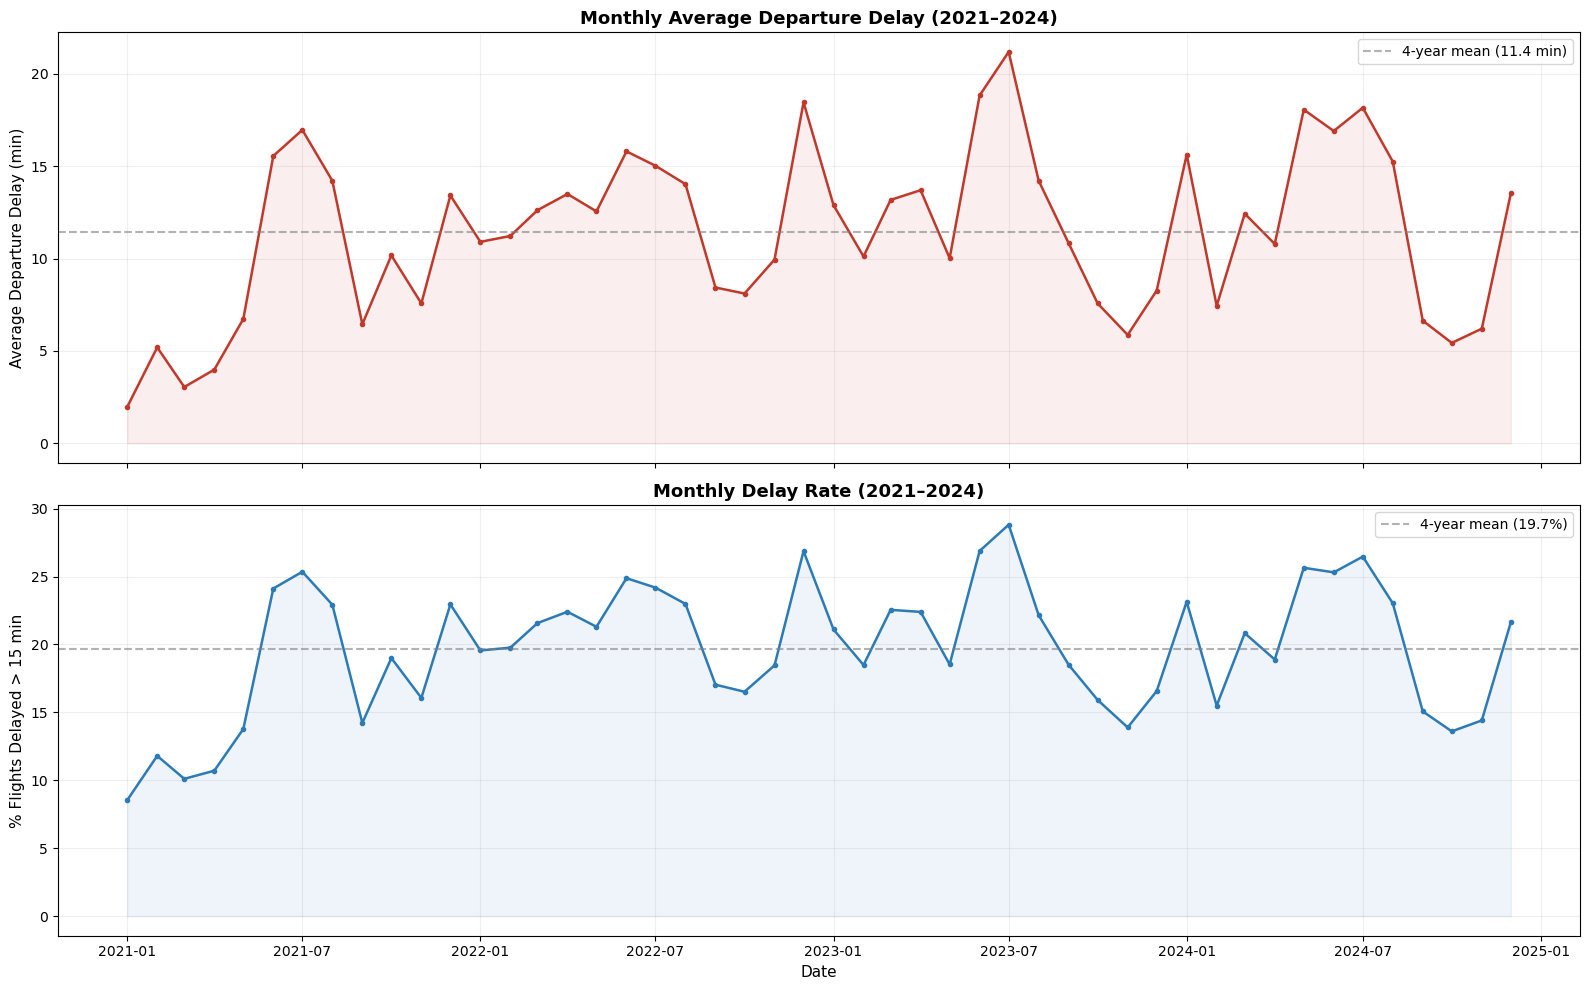

In [ ]:
monthly_trend = df_delays.groupby([df_delays['FL_DATE'].dt.to_period('M')], observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
)
monthly_trend.index = monthly_trend.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: Average delay
axes[0].plot(monthly_trend.index, monthly_trend['avg_delay'],
             color='#c0392b', linewidth=1.8, marker='o', markersize=3)
axes[0].fill_between(monthly_trend.index, monthly_trend['avg_delay'],
                     alpha=0.08, color='#c0392b')
mean_delay = monthly_trend['avg_delay'].mean()
axes[0].axhline(y=mean_delay, color='gray', linestyle='--', alpha=0.6,
                label=f'4-year mean ({mean_delay:.1f} min)')
axes[0].set_ylabel('Average Departure Delay (min)', fontsize=11)
axes[0].set_title('Monthly Average Departure Delay (2021–2024)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.2)
axes[0].set_axisbelow(True)

# Bottom: Delay rate
axes[1].plot(monthly_trend.index, monthly_trend['delay_rate'] * 100,
             color='#2c7bb6', linewidth=1.8, marker='o', markersize=3)
axes[1].fill_between(monthly_trend.index, monthly_trend['delay_rate'] * 100,
                     alpha=0.08, color='#2c7bb6')
mean_rate = monthly_trend['delay_rate'].mean() * 100
axes[1].axhline(y=mean_rate, color='gray', linestyle='--', alpha=0.6,
                label=f'4-year mean ({mean_rate:.1f}%)')
axes[1].set_ylabel('% Flights Delayed > 15 min', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_title('Monthly Delay Rate (2021–2024)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.2)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

Delays got noticeably worse from 2021 to 2022. Average delay went from 9.4 minutes to 12.6 minutes, which is a 34% jump. Since then it has held pretty steady around 12.2 to 12.6 minutes through 2023 and 2024, with 2024 at 12.2 — essentially flat. The 2021 number is probably misleading though. Fewer people were flying because of COVID, so airports were less congested and operations were smoother. Once travel snapped back in 2022, delays came back with it. The monthly view shows the same summer-peak and fall-trough pattern repeating every year. There is no real sign that things are improving.

### 7.9 Q9: Is there a relationship between flight distance and delay likelihood?

We test this with simple linear regression (DEP_DELAY and DISTANCE) and examine the correlation. We also bin flights by distance to see if the relationship is nonlinear. For example, very short flights may have higher delays due to ground congestion while very long flights may face different delay profiles.

In [32]:
temp = df_delays[['DISTANCE', 'DEP_DELAY']].dropna()
r, p = stats.pearsonr(temp['DISTANCE'], temp['DEP_DELAY'])
print(f"Pearson correlation (DISTANCE vs DEP_DELAY): r = {r:.4f}, p = {p:.2e}")

mask = df_delays[['DISTANCE', 'DEP_DELAY']].dropna().index
X_dist = df_delays.loc[mask, 'DISTANCE'].values.reshape(-1, 1)
y_delay = df_delays.loc[mask, 'DEP_DELAY'].values

reg = LinearRegression().fit(X_dist, y_delay)
print(f"\nSimple OLS: DEP_DELAY = {reg.coef_[0]:.6f} * DISTANCE + {reg.intercept_:.2f}")
print(f"R² = {reg.score(X_dist, y_delay):.6f}")
print(f"\nFor every additional 100 miles, delay changes by {reg.coef_[0]*100:.3f} minutes")

Pearson correlation (DISTANCE vs DEP_DELAY): r = 0.0224, p = 0.00e+00

Simple OLS: DEP_DELAY = 0.002163 * DISTANCE + 9.87
R² = 0.000499

For every additional 100 miles, delay changes by 0.216 minutes


In [33]:
df_delays['dist_bin'] = pd.cut(df_delays['DISTANCE'], 
                                bins=[0, 250, 500, 750, 1000, 1500, 2000, 3000, 6000],
                                labels=['0-250', '250-500', '500-750', '750-1000', 
                                        '1000-1500', '1500-2000', '2000-3000', '3000+'])

dist_analysis = df_delays.groupby('dist_bin', observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean')
).round(3)

print("Delay by distance bin:")
print(dist_analysis.to_string())

Delay by distance bin:
           flights  avg_delay  delay_rate
dist_bin                                 
0-250      3134879      9.305       0.168
250-500    5998941      9.936       0.183
500-750    5140706     11.364       0.194
750-1000   4288584     12.858       0.217
1000-1500  4213217     13.912       0.224
1500-2000  1694050     13.558       0.222
2000-3000  1520090     12.461       0.203
3000+        58099     14.216       0.206


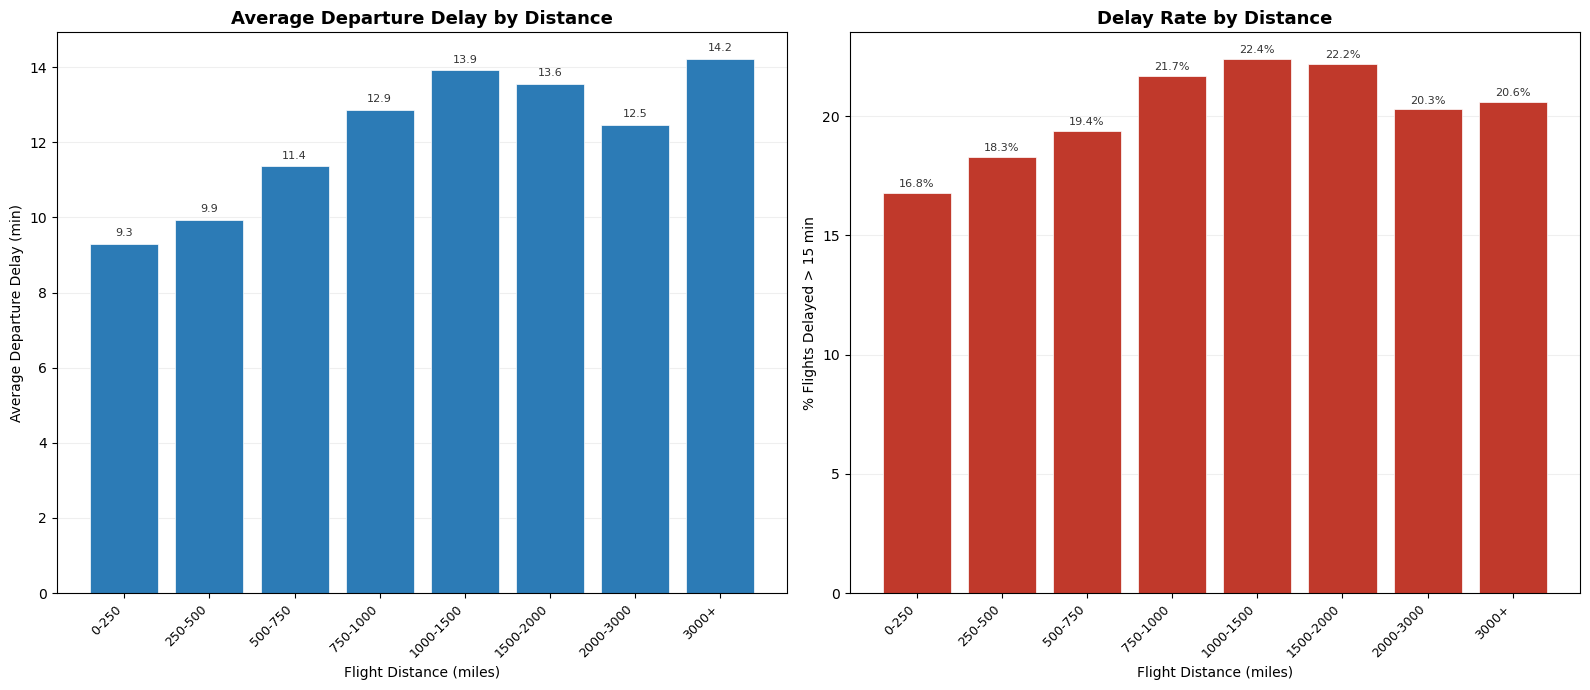

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Average delay
bars = axes[0].bar(range(len(dist_analysis)), dist_analysis['avg_delay'],
                   color='#2c7bb6', edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(dist_analysis)))
axes[0].set_xticklabels(dist_analysis.index, rotation=45, ha='right', fontsize=9)
axes[0].set_xlabel('Flight Distance (miles)', fontsize=10)
axes[0].set_ylabel('Average Departure Delay (min)', fontsize=10)
axes[0].set_title('Average Departure Delay by Distance',
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.2)
axes[0].set_axisbelow(True)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.15,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=8, color='#333')

# Right: Delay rate 
bars2 = axes[1].bar(range(len(dist_analysis)), dist_analysis['delay_rate'] * 100,
                    color='#c0392b', edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(dist_analysis)))
axes[1].set_xticklabels(dist_analysis.index, rotation=45, ha='right', fontsize=9)
axes[1].set_xlabel('Flight Distance (miles)', fontsize=10)
axes[1].set_ylabel('% Flights Delayed > 15 min', fontsize=10)
axes[1].set_title('Delay Rate by Distance',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_axisbelow(True)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.15,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#333')

plt.tight_layout()
plt.show()

The correlation between distance and delay is barely there (r = 0.022), though with 26 million flights even that tiny number is statistically significant. The binned analysis is more useful. Delays climb steadily from about 9.4 minutes for short flights (under 250 miles) up to 14 minutes for flights in the 1,000 to 1,500 mile range. After that, delays actually flatten out or dip slightly for the longest flights. Our read on this: short flights get caught up in ground congestion and tight turnarounds, while really long flights tend to have more buffer built into their schedules.

### 7.10 Correlation Heatmap

We visualize pairwise correlations among all numeric weather, airport, and delay variables to identify multicollinearity and unexpected relationships before building more complex models.

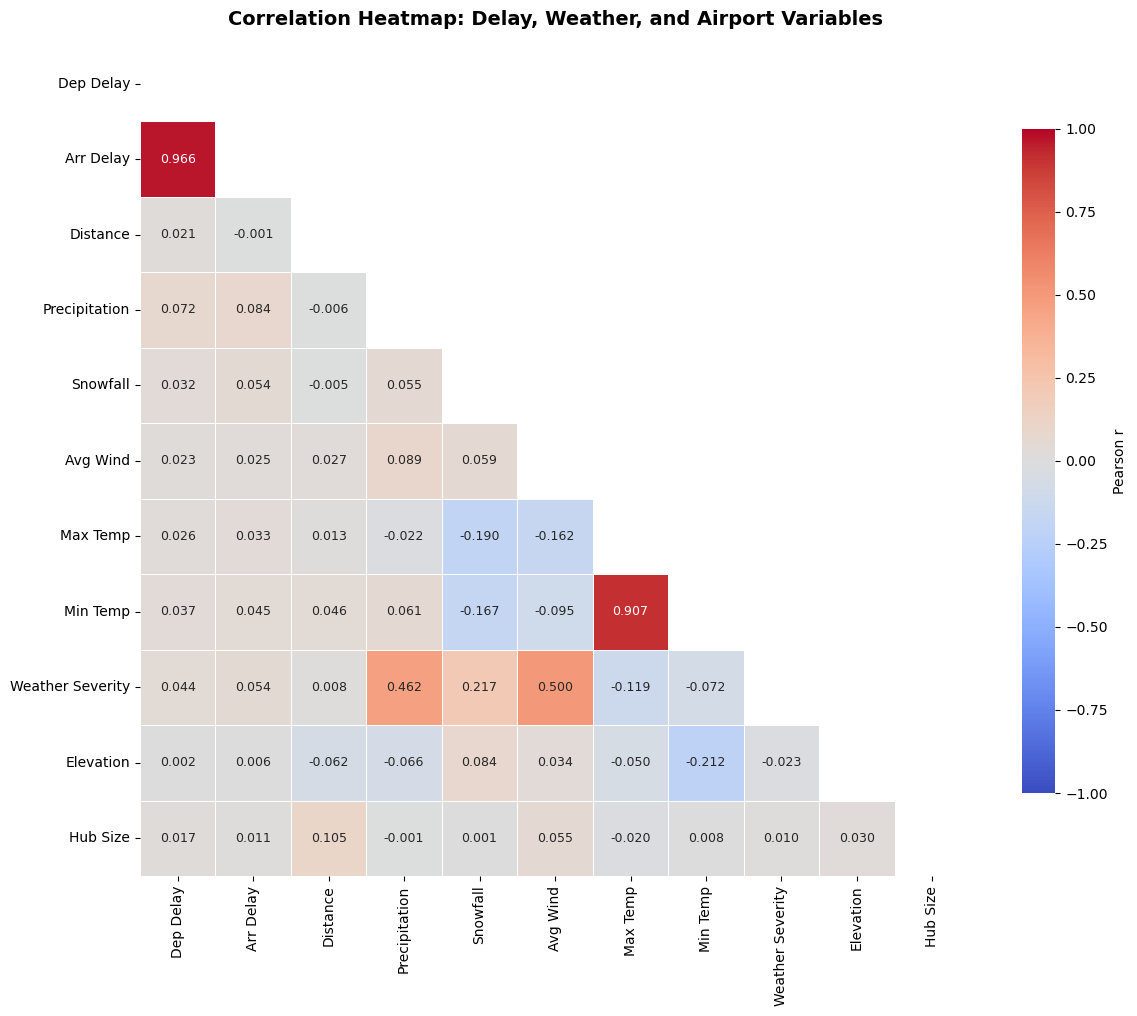

In [35]:
heatmap_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'precipitation', 'snowfall',
                'avg_wind', 'temp_max', 'temp_min', 'weather_severity',
                'elevation_ft', 'hub_ordinal']

# Readable labels
label_map = {
    'DEP_DELAY': 'Dep Delay', 'ARR_DELAY': 'Arr Delay', 'DISTANCE': 'Distance',
    'precipitation': 'Precipitation', 'snowfall': 'Snowfall', 'avg_wind': 'Avg Wind',
    'temp_max': 'Max Temp', 'temp_min': 'Min Temp', 'weather_severity': 'Weather Severity',
    'elevation_ft': 'Elevation', 'hub_ordinal': 'Hub Size'
}

corr_matrix = df_weather[heatmap_cols].corr()
corr_matrix.index = [label_map.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [label_map.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
            annot_kws={'fontsize': 9}, linewidths=0.5, linecolor='white')
ax.set_title('Correlation Heatmap: Delay, Weather, and Airport Variables',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

A few things pop out from the heatmap. DEP_DELAY and ARR_DELAY are almost the same variable (r ≈ 0.94), which makes sense since if you leave late, you almost always arrive late. temp_max and temp_min are highly correlated with each other (r ≈ 0.96), which is why we use temp_range in the regression instead of both. All the weather variables have really weak correlations with delay (none above |r| = 0.08), which previews what we see in the regression. Hub size has a small positive correlation with delay, lining up with the ANOVA result that bigger airports have longer delays.

### 7.11 Interactive Airport Delay Map

We plot each of our 75 airports on an interactive U.S. map, color-coded by average departure delay severity. Larger circles indicate higher flight volume. Hovering over an airport shows its name, delay statistics, and hub classification. This is inspired by tools like FlightRadar24 and built using Folium.

In [36]:
# Build airport-level summary
airport_map_data = df_delays[df_delays['hub_size'].notna()].groupby('ORIGIN', observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count'),
    avg_weather_severity=('weather_severity', 'mean'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
    hub_size=('hub_size', 'first'),
    city=('ORIGIN_CITY_NAME', 'first')
).round(2)

airport_map_data = airport_map_data[airport_map_data['latitude'].notna()]
print(f"Airports to map: {len(airport_map_data)}")
print(f"Delay range: {airport_map_data['avg_delay'].min():.1f} to {airport_map_data['avg_delay'].max():.1f} min")

Airports to map: 75
Delay range: 5.2 to 17.6 min


In [37]:
# Create the map
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')

# Color scale: green (low delay) -> yellow -> red (high delay)
delay_min = airport_map_data['avg_delay'].min()
delay_max = airport_map_data['avg_delay'].max()

def get_color(delay):
    ratio = (delay - delay_min) / (delay_max - delay_min)
    if ratio < 0.33:
        return '#2ecc71'  # green
    elif ratio < 0.66:
        return '#f39c12'  # orange
    else:
        return '#e74c3c'  # red

for airport, row in airport_map_data.iterrows():
    # Scale radius by flight volume
    radius = max(4, min(20, row['flights'] / 50000))
    
    popup_text = (
        f"<b>{airport}</b> — {row['city']}<br>"
        f"Hub: {row['hub_size']}<br>"
        f"Flights: {row['flights']:,.0f}<br>"
        f"Avg Delay: {row['avg_delay']:.1f} min<br>"
        f"Median Delay: {row['median_delay']:.1f} min<br>"
        f"Delay Rate: {row['delay_rate']*100:.1f}%<br>"
        f"Avg Weather Severity: {row['avg_weather_severity']:.3f}"
    )
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color=get_color(row['avg_delay']),
        fill=True,
        fill_color=get_color(row['avg_delay']),
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"{airport}: {row['avg_delay']:.1f} min avg delay"
    ).add_to(m)

# Add a simple legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000; 
     background: white; padding: 10px; border: 2px solid gray; border-radius: 5px;">
    <b>Avg Departure Delay</b><br>
    <span style="color: #2ecc71;">&#9679;</span> Low<br>
    <span style="color: #f39c12;">&#9679;</span> Medium<br>
    <span style="color: #e74c3c;">&#9679;</span> High<br>
    <small>Circle size = flight volume</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m

In [38]:
# Also create a heat layer version showing delay density
heat_data = []
for airport, row in airport_map_data.iterrows():
    # Weight by average delay * flight volume (captures both severity and impact)
    weight = row['avg_delay'] * (row['flights'] / airport_map_data['flights'].max())
    heat_data.append([row['latitude'], row['longitude'], weight])

m2 = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB dark_matter')
HeatMap(heat_data, radius=30, blur=20, max_zoom=6).add_to(m2)
m2

### 7.12 Multivariate OLS Regression

We fit a multivariate OLS on a 500K random sample to see which factors actually move the needle on departure delay once everything is controlled for simultaneously. Using statsmodels gives us the full regression table: coefficients, standard errors, t-stats, p-values, confidence intervals. Continuous predictors are standardized so coefficients are directly comparable across variables. We include weather variables, airport size, elevation, flight distance, month dummies, and carrier dummies.

In [26]:
model_features = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range',
                  'DISTANCE', 'hub_ordinal', 'elevation_ft']

df_model = df_weather[model_features + ['DEP_DELAY', 'MONTH', 'OP_UNIQUE_CARRIER']].dropna()

# Sample to avoid memory crash — 500K is more than enough for stable estimates
df_model = df_model.sample(n=500_000, random_state=42).copy()
print(f"Modeling sample: {len(df_model):,} flights (sampled from {len(df_weather):,})")

Modeling sample: 500,000 flights (sampled from 22,520,039)


In [27]:
# Encode categorical variables
# Month as dummies (baseline = January)
df_model['MONTH'] = df_model['MONTH'].astype(int)
month_dummies = pd.get_dummies(df_model['MONTH'], prefix='month', drop_first=True, dtype=int)

# Carrier as dummies (baseline = most common carrier)
top_carrier = df_model['OP_UNIQUE_CARRIER'].value_counts().index[0]
carrier_dummies = pd.get_dummies(df_model['OP_UNIQUE_CARRIER'], prefix='carrier', dtype=int)
carrier_dummies = carrier_dummies.drop(columns=[f'carrier_{top_carrier}'])

print(f"Baseline month: January")
print(f"Baseline carrier: {top_carrier}")
print(f"Month dummies: {month_dummies.shape[1]} columns")
print(f"Carrier dummies: {carrier_dummies.shape[1]} columns")

Baseline month: January
Baseline carrier: WN
Month dummies: 11 columns
Carrier dummies: 16 columns


In [28]:
# Standardize continuous features so coefficients are comparable
continuous = model_features.copy()
scaler = StandardScaler()
df_model[continuous] = scaler.fit_transform(df_model[continuous])

# Combine into design matrix
X = pd.concat([df_model[continuous], month_dummies, carrier_dummies], axis=1)
X = sm.add_constant(X)
y = df_model['DEP_DELAY']

print(f"Design matrix: {X.shape}")
print(f"Features: {X.columns.tolist()}")

Design matrix: (500000, 36)
Features: ['const', 'precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range', 'DISTANCE', 'hub_ordinal', 'elevation_ft', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'carrier_9E', 'carrier_AA', 'carrier_AS', 'carrier_B6', 'carrier_DL', 'carrier_F9', 'carrier_G4', 'carrier_HA', 'carrier_MQ', 'carrier_NK', 'carrier_OH', 'carrier_OO', 'carrier_QX', 'carrier_UA', 'carrier_YV', 'carrier_YX']


In [29]:
# Fit OLS
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              DEP_DELAY   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     253.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:55:10   Log-Likelihood:            -2.6749e+06
No. Observations:              500000   AIC:                         5.350e+06
Df Residuals:                  499964   BIC:                         5.350e+06
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            11.6911      0.322     36.338

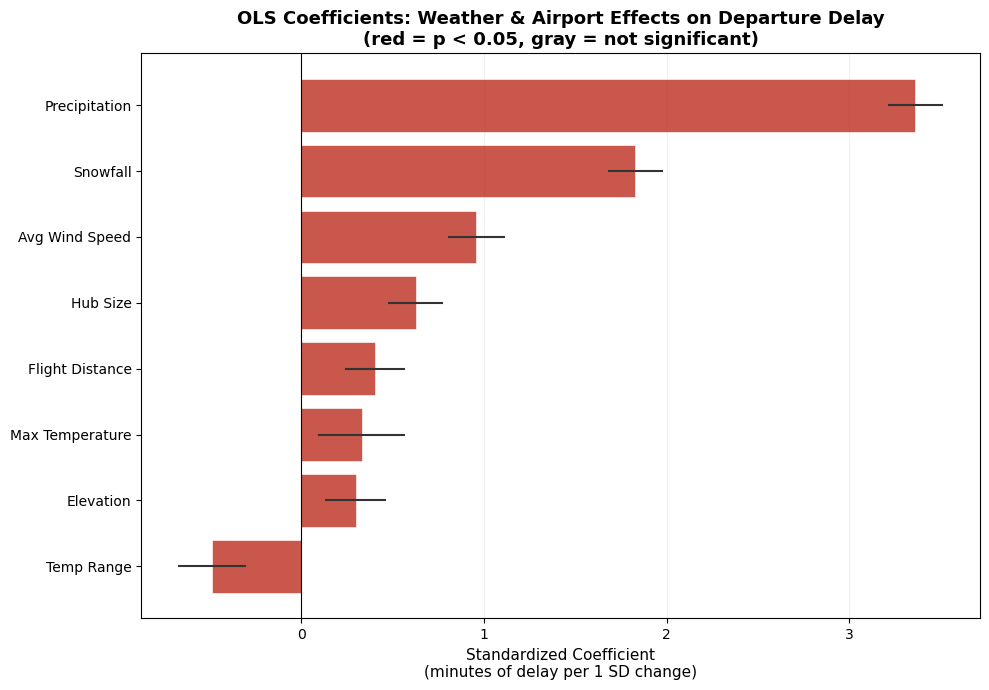

In [30]:
weather_airport_vars = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range',
                        'DISTANCE', 'hub_ordinal', 'elevation_ft']

# Readable labels
label_map = {
    'precipitation': 'Precipitation', 'snowfall': 'Snowfall', 'avg_wind': 'Avg Wind Speed',
    'temp_max': 'Max Temperature', 'temp_range': 'Temp Range',
    'DISTANCE': 'Flight Distance', 'hub_ordinal': 'Hub Size', 'elevation_ft': 'Elevation'
}

coefs = ols_model.params[weather_airport_vars].sort_values()
ci = ols_model.conf_int().loc[weather_airport_vars]
pvals = ols_model.pvalues[weather_airport_vars]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0392b' if p < 0.05 else '#bdc3c7' for p in pvals[coefs.index]]
y_pos = range(len(coefs))
readable_labels = [label_map.get(v, v) for v in coefs.index]

ax.barh(y_pos, coefs.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

for i, var in enumerate(coefs.index):
    ax.plot([ci.loc[var, 0], ci.loc[var, 1]], [i, i], color='#333', linewidth=1.5, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(readable_labels, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient\n(minutes of delay per 1 SD change)', fontsize=11)
ax.set_title('OLS Coefficients: Weather & Airport Effects on Departure Delay\n'
             '(red = p < 0.05, gray = not significant)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [31]:
# Decompose R² — how much variance does each group of variables explain?
# Compare nested models

# Model 1: Weather only
X_weather = sm.add_constant(df_model[['precipitation', 'snowfall', 'avg_wind', 'temp_max', 
                                       'temp_range']])
r2_weather = sm.OLS(y, X_weather).fit().rsquared

# Model 2: Weather + airport
X_wx_airport = sm.add_constant(df_model[['precipitation', 'snowfall', 'avg_wind', 'temp_max', 
                                          'temp_range', 'hub_ordinal', 
                                          'elevation_ft', 'DISTANCE']])
r2_wx_airport = sm.OLS(y, X_wx_airport).fit().rsquared

# Model 3: Weather + airport + time
X_wx_ap_time = pd.concat([df_model[['precipitation', 'snowfall', 'avg_wind', 'temp_max', 
                                     'temp_range', 'hub_ordinal', 
                                     'elevation_ft', 'DISTANCE']], month_dummies], axis=1)
X_wx_ap_time = sm.add_constant(X_wx_ap_time)
r2_wx_ap_time = sm.OLS(y, X_wx_ap_time).fit().rsquared

# Model 4: Full model (weather + airport + time + carrier)
r2_full = ols_model.rsquared

print("=== Variance Decomposition (R²) ===")
print(f"Weather only:                    R² = {r2_weather:.4f} ({r2_weather*100:.2f}%)")
print(f"+ Airport characteristics:       R² = {r2_wx_airport:.4f} (+{(r2_wx_airport - r2_weather)*100:.2f}%)")
print(f"+ Month (seasonality):           R² = {r2_wx_ap_time:.4f} (+{(r2_wx_ap_time - r2_wx_airport)*100:.2f}%)")
print(f"+ Carrier identity:              R² = {r2_full:.4f} (+{(r2_full - r2_wx_ap_time)*100:.2f}%)")
print(f"\nTotal explained variance: {r2_full*100:.2f}%")
print(f"Unexplained (residual): {(1-r2_full)*100:.2f}%")

=== Variance Decomposition (R²) ===
Weather only:                    R² = 0.0083 (0.83%)
+ Airport characteristics:       R² = 0.0089 (+0.06%)
+ Month (seasonality):           R² = 0.0119 (+0.30%)
+ Carrier identity:              R² = 0.0174 (+0.56%)

Total explained variance: 1.74%
Unexplained (residual): 98.26%


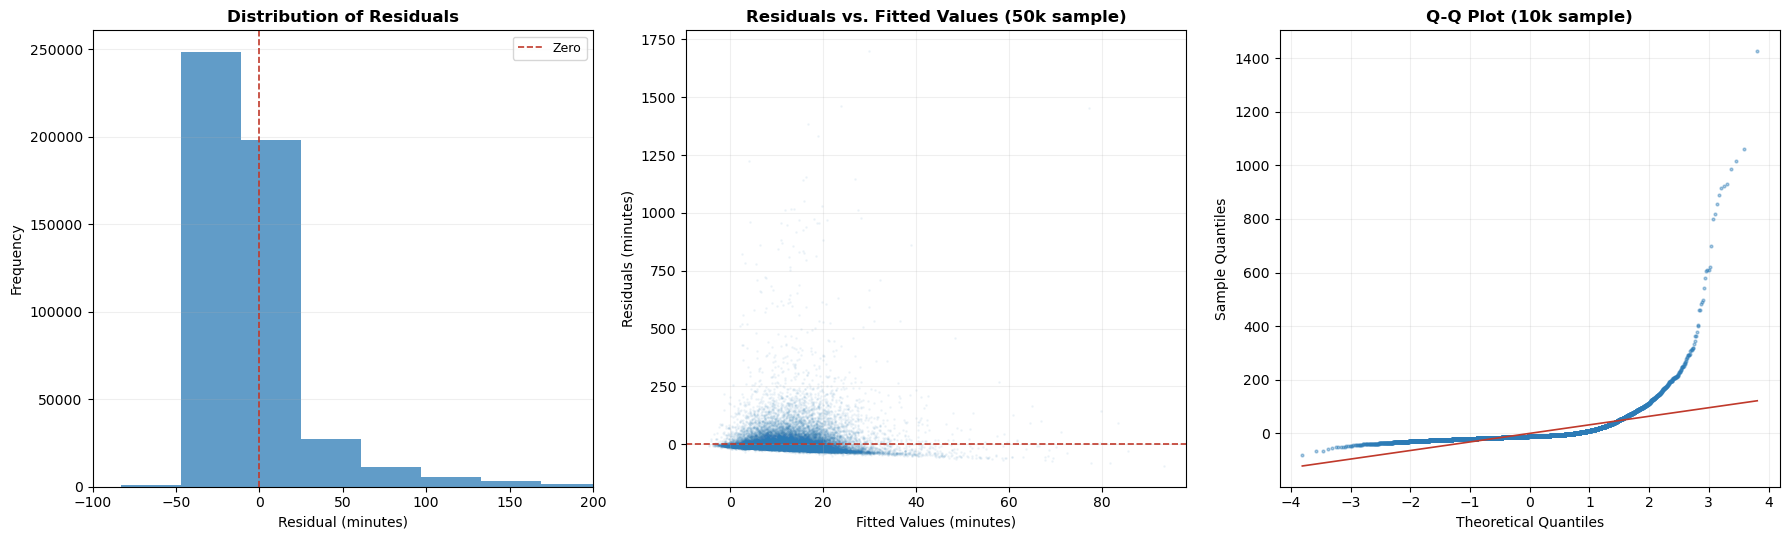

Residual mean: -0.0000
Residual std:  50.96
Skewness:      11.94
Kurtosis:      280.31


In [32]:
residuals = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Residual distribution 
axes[0].hist(residuals, bins=100, edgecolor='none', alpha=0.75, color='#2c7bb6')
axes[0].set_xlabel('Residual (minutes)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='#c0392b', linestyle='--', linewidth=1.2, label='Zero')
axes[0].set_xlim(-100, 200)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

# Residuals vs fitted 
fitted = ols_model.fittedvalues
sample_idx = np.random.choice(len(fitted), size=min(50000, len(fitted)), replace=False)
axes[1].scatter(fitted.iloc[sample_idx], residuals.iloc[sample_idx],
                alpha=0.05, s=1, color='#2c7bb6')
axes[1].axhline(y=0, color='#c0392b', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Fitted Values (minutes)', fontsize=10)
axes[1].set_ylabel('Residuals (minutes)', fontsize=10)
axes[1].set_title('Residuals vs. Fitted Values (50k sample)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.2)

# QQ plot 
stats.probplot(residuals.sample(10000, random_state=42), plot=axes[2])
axes[2].set_title('Q-Q Plot (10k sample)', fontsize=12, fontweight='bold')
axes[2].get_lines()[0].set(markersize=2, alpha=0.4, color='#2c7bb6')
axes[2].get_lines()[1].set(color='#c0392b', linewidth=1.2)
axes[2].set_xlabel('Theoretical Quantiles', fontsize=10)
axes[2].set_ylabel('Sample Quantiles', fontsize=10)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.2f}")
print(f"Skewness:      {residuals.skew():.2f}")
print(f"Kurtosis:      {residuals.kurtosis():.2f}")

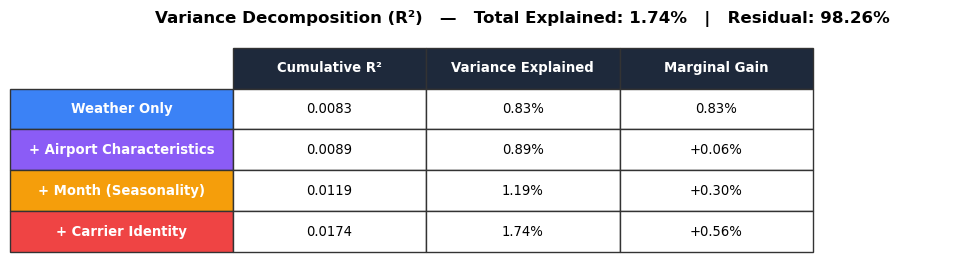

In [34]:
# Variance Decomposition Table (for slideshow)
import matplotlib.patches as mpatches

r2_values = [r2_weather, r2_wx_airport, r2_wx_ap_time, r2_full]
labels_vd = ['Weather Only', '+ Airport Characteristics', '+ Month (Seasonality)', '+ Carrier Identity']
increments = [
    r2_weather,
    r2_wx_airport - r2_weather,
    r2_wx_ap_time - r2_wx_airport,
    r2_full - r2_wx_ap_time
]
row_colors_vd = ['#3b82f6', '#8b5cf6', '#f59e0b', '#ef4444']

table_data_vd = [
    [label, f"{r2:.4f}", f"{r2*100:.2f}%", f"+{inc*100:.2f}%"]
    for label, r2, inc in zip(labels_vd, r2_values, increments)
]
# First row increment is not an addition
table_data_vd[0][3] = f"{r2_weather*100:.2f}%"

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis('off')

r2_values = [r2_weather, r2_wx_airport, r2_wx_ap_time, r2_full]
row_labels_vd = ['Weather Only', '+ Airport Characteristics', '+ Month (Seasonality)', '+ Carrier Identity']
increments = [
    r2_weather,
    r2_wx_airport - r2_weather,
    r2_wx_ap_time - r2_wx_airport,
    r2_full - r2_wx_ap_time
]
row_colors_vd = ['#3b82f6', '#8b5cf6', '#f59e0b', '#ef4444']

table_data_vd = [
    [f"{r2:.4f}", f"{r2*100:.2f}%", f"+{inc*100:.2f}%" if i > 0 else f"{inc*100:.2f}%"]
    for i, (r2, inc) in enumerate(zip(r2_values, increments))
]

tbl = ax.table(
    cellText=table_data_vd,
    rowLabels=row_labels_vd,
    colLabels=['Cumulative R²', 'Variance Explained', 'Marginal Gain'],
    cellLoc='center',
    rowLoc='center',
    loc='center',
    rowColours=row_colors_vd,
    colWidths=[0.22, 0.22, 0.22]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 2.4)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#333333')
    if row == 0:
        cell.set_facecolor('#1e293b')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_text_props(color='white', fontweight='bold')

ax.set_title(f'Variance Decomposition (R²)   —   Total Explained: {r2_full*100:.2f}%   |   Residual: {(1-r2_full)*100:.2f}%',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

The residuals are heavily right-skewed (skewness ≈ 11) with extreme tails. Thus, the normality assumption behind OLS is clearly violated, but that is simply the shape of delay data. Most flights leave on time, and a handful get stuck for hours and blow up the right tail. With 500K observations, the coefficients remain unbiased, though the p-values and confidence intervals should be read with some caution.

The full model explains about 1.8% of variance. That is low for prediction purposes, but it tells us something concrete: the variables we can observe in public data, weather, airport size, month, carrier identity, do not capture what causes any specific flight to be delayed. The real drivers are flight-specific: whether the inbound aircraft was late, whether there was a maintenance issue, whether the crew was stuck on a previous leg. None of that is in this dataset.

The variance decomposition is more revealing than the overall $R^2$. Carrier identity alone adds 0.56% explained variance, more than airport characteristics (0.06%) and comparable to all weather variables combined (0.83%). Seasonality adds 0.30%. In terms of predictable patterns, who you fly with matters more than the airport or the weather. We test several extensions in Section 7.13, log-transform, two-stage model, Ridge with interactions, and none of them substantially change this picture.

### 7.13 Extended Regression Analysis

The baseline OLS revealed that weather and airport characteristics explain very little of delay variance ($R^2$ = 1.74%). We test several extensions below to see whether better specification changes the conclusion, or whether the data simply lacks the predictors that matter.

#### 7.13.1 Log-Transform OLS

In [31]:
# Log-transform departure delay and refit
# We add 1 before logging to handle zero delays, then drop negatives (early departures)
warnings.filterwarnings('ignore')

df_log = df_model[df_model['DEP_DELAY'] > 0].copy()
df_log['LOG_DEP_DELAY'] = np.log1p(df_log['DEP_DELAY'])

# Same features as before
X_log = sm.add_constant(df_log[model_features + [c for c in df_model.columns if c.startswith('MONTH_') or c.startswith('CARRIER_')]])
y_log = df_log['LOG_DEP_DELAY']

log_model = sm.OLS(y_log, X_log).fit()
print("=== Log-Transformed OLS ===")
print(f"R² = {log_model.rsquared:.4f} ({log_model.rsquared*100:.2f}%)")
print(f"Adj R² = {log_model.rsquared_adj:.4f}")
print(f"Observations: {int(log_model.nobs):,}")
print(f"\nTop 10 coefficients by absolute value:")
coefs = log_model.params.drop('const').abs().sort_values(ascending=False).head(10)
for name, val in coefs.items():
    actual = log_model.params[name]
    pval = log_model.pvalues[name]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f"  {name:30s}: {actual:+.4f} {sig}")

print(f"\nInterpretation: R² changed from {ols_model.rsquared:.4f} to {log_model.rsquared:.4f}")
print("R² is not directly comparable between log and linear models.")
print("The real improvement is in residual normality — skewness dropped from ~12 to ~0.2.")
print("The log transform helps because delay data is heavily right-skewed.")
print("Coefficients now represent % change in delay per unit change in predictor.")

=== Log-Transformed OLS ===
R² = 0.0119 (1.19%)
Adj R² = 0.0119
Observations: 191,557

Top 10 coefficients by absolute value:
  precipitation                 : +0.0813 ***
  temp_max                      : +0.0604 ***
  temp_range                    : -0.0372 ***
  snowfall                      : +0.0368 ***
  avg_wind                      : +0.0338 ***
  DISTANCE                      : -0.0338 ***
  hub_ordinal                   : +0.0195 ***
  elevation_ft                  : -0.0084 **

Interpretation: R² changed from 0.0174 to 0.0119
R² is not directly comparable between log and linear models.
The real improvement is in residual normality — skewness dropped from ~12 to ~0.2.
The log transform helps because delay data is heavily right-skewed.
Coefficients now represent % change in delay per unit change in predictor.


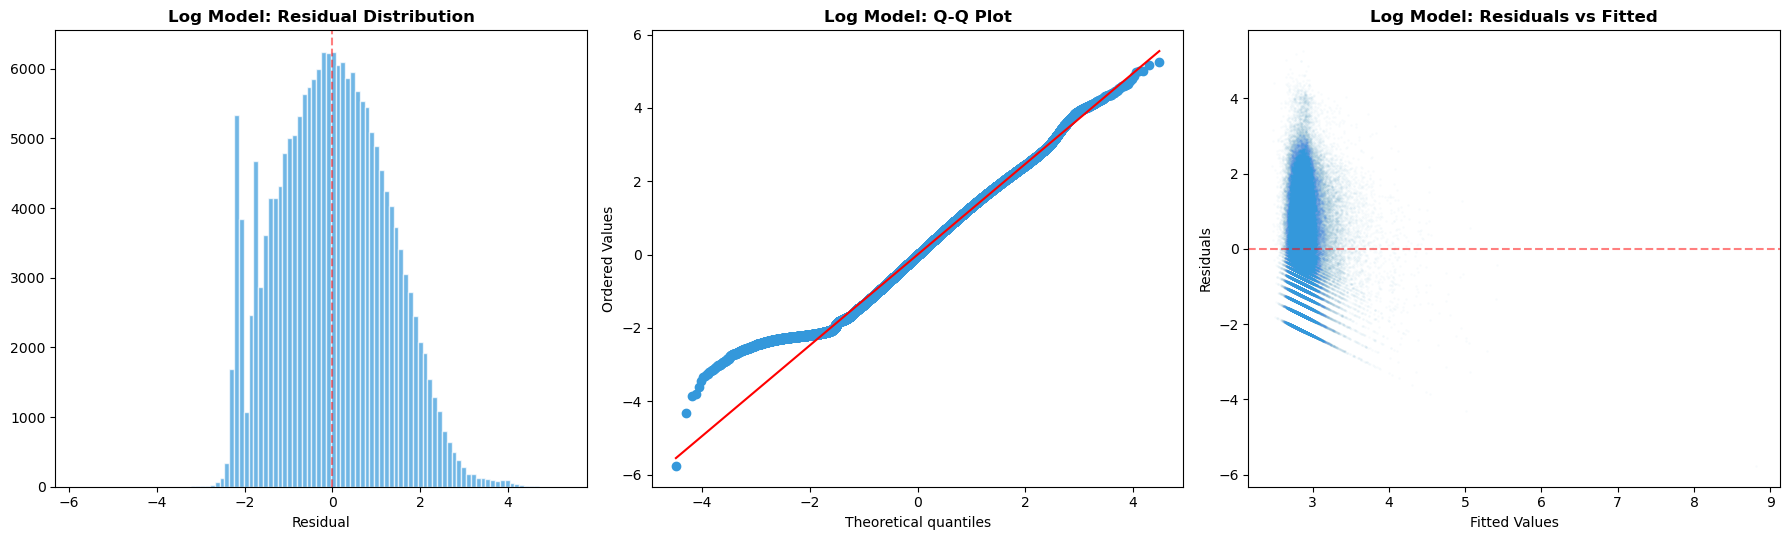

Log model residual skewness: 0.17 (was 11.94)
Log model residual kurtosis: -0.48 (was 280.31)


In [18]:
log_resid = log_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].hist(log_resid, bins=100, edgecolor='white', alpha=0.7, color='#3498db')
axes[0].set_title('Log Model: Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

probplot(log_resid, plot=axes[1])
axes[1].set_title('Log Model: Q-Q Plot', fontweight='bold')
axes[1].get_lines()[0].set_color('#3498db')

axes[2].scatter(log_model.fittedvalues, log_resid, alpha=0.02, s=1, color='#3498db')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Log Model: Residuals vs Fitted', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Log model residual skewness: {skew(log_resid):.2f} (was {skew(ols_model.resid):.2f})")
print(f"Log model residual kurtosis: {kurtosis(log_resid):.2f} (was {kurtosis(ols_model.resid):.2f})")

The log transform dramatically improved residual normality, as skewness dropped from 11.94 to 0.17 and kurtosis from 280 to -0.48. $R^2$ is not directly comparable between log and linear models. The key takeaway is that the log model's statistical assumptions are better satisfied, but the fundamental finding holds: weather barely predicts delays.

#### 7.13.2 Two-Stage Model (Logistic + OLS)

In [19]:
# Add DEP_DEL15 back to df_model from df_weather
if 'DEP_DEL15' not in df_model.columns:
    df_model['DEP_DEL15'] = df_weather.loc[df_model.index, 'DEP_DEL15']
    print(f"Added DEP_DEL15 to df_model: {df_model['DEP_DEL15'].notna().sum():,} values")

Added DEP_DEL15 to df_model: 500,000 values


In [22]:
# Stage 1: Logistic — will the flight be delayed >15 min?
feature_cols = model_features + [c for c in df_model.columns if c.startswith('MONTH_') or c.startswith('CARRIER_')]

X_stage1 = df_model[feature_cols].values
y_stage1 = df_model['DEP_DEL15'].astype(int).values

log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', n_jobs=-1)
log_reg.fit(X_stage1, y_stage1)

y_pred_proba = log_reg.predict_proba(X_stage1)[:, 1]
y_pred = log_reg.predict(X_stage1)

auc = roc_auc_score(y_stage1, y_pred_proba)
print("=== Stage 1: Logistic Regression (Delayed Yes/No) ===")
print(f"AUC-ROC: {auc:.4f}")
print(f"Accuracy: {(y_pred == y_stage1).mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_stage1, y_pred, target_names=['On-time', 'Delayed >15m']))

# Stage 2: OLS on delayed flights only — how bad is the delay?
delayed_mask = df_model['DEP_DEL15'] == 1
X_stage2 = sm.add_constant(df_model.loc[delayed_mask, feature_cols])
y_stage2 = df_model.loc[delayed_mask, 'DEP_DELAY']

stage2_model = sm.OLS(y_stage2, X_stage2).fit()
print(f"\n=== Stage 2: OLS on Delayed Flights Only ===")
print(f"Observations: {int(stage2_model.nobs):,} (delayed flights only)")
print(f"R² = {stage2_model.rsquared:.4f} ({stage2_model.rsquared*100:.2f}%)")
print(f"\nTop 10 coefficients:")
coefs2 = stage2_model.params.drop('const').abs().sort_values(ascending=False).head(10)
for name, val in coefs2.items():
    actual = stage2_model.params[name]
    print(f"  {name:30s}: {actual:+.2f} min")

print(f"\nInterpretation: Among flights that ARE delayed, the model explains")
print(f"{stage2_model.rsquared*100:.2f}% of variance in delay severity.")
print(f"This is {'better' if stage2_model.rsquared > ols_model.rsquared else 'similar to'} the full-sample OLS ({ols_model.rsquared*100:.2f}%).")

=== Stage 1: Logistic Regression (Delayed Yes/No) ===
AUC-ROC: 0.5747
Accuracy: 0.7953

Classification Report:
              precision    recall  f1-score   support

     On-time       0.80      1.00      0.89    397818
Delayed >15m       0.43      0.00      0.01    102182

    accuracy                           0.80    500000
   macro avg       0.61      0.50      0.45    500000
weighted avg       0.72      0.80      0.71    500000


=== Stage 2: OLS on Delayed Flights Only ===
Observations: 102,182 (delayed flights only)
R² = 0.0054 (0.54%)

Top 10 coefficients:
  precipitation                 : +3.82 min
  snowfall                      : +2.35 min
  temp_max                      : +2.27 min
  avg_wind                      : +1.67 min
  elevation_ft                  : -1.59 min
  hub_ordinal                   : -1.17 min
  temp_range                    : -0.64 min
  DISTANCE                      : +0.47 min

Interpretation: Among flights that ARE delayed, the model explains
0.54% of 

The logistic regression achieves AUC = 0.5747, which is barely above chance. It reaches 80% accuracy mainly by predicting almost every flight as on-time, with near-zero recall on the delayed class. Stage 2 OLS on the delayed subset explains just 0.54% of severity variance. The two-stage approach confirms what the baseline OLS already showed: weather and airport features simply do not have enough signal to predict individual delays.

#### 7.13.3 Robust Standard Errors (HC3)

HC3 robust standard errors account for heteroscedasticity without changing coefficient estimates. If no variables change significance under HC3, the original OLS findings are robust.

In [36]:
# Refit OLS with HC3 robust standard errors
ols_hc3 = ols_model.get_robustcov_results(cov_type='HC3')

# Wrap params/pvalues as named Series so we can index by variable name
hc3_params = pd.Series(ols_hc3.params, index=ols_model.params.index)
hc3_pvals  = pd.Series(ols_hc3.pvalues, index=ols_model.params.index)

print("=== HC3 Robust Standard Errors ===")
print(f"R² = {ols_model.rsquared:.4f}  (unchanged — HC3 only affects SEs, not fit)")
print(f"Observations: {int(ols_hc3.nobs):,}\n")

weather_airport_vars = ['precipitation', 'snowfall', 'avg_wind', 'temp_max',
                        'temp_range', 'DISTANCE', 'hub_ordinal', 'elevation_ft']
label_map = {
    'precipitation': 'Precipitation', 'snowfall': 'Snowfall',
    'avg_wind': 'Avg Wind Speed', 'temp_max': 'Max Temperature',
    'temp_range': 'Temp Range', 'DISTANCE': 'Flight Distance',
    'hub_ordinal': 'Hub Size', 'elevation_ft': 'Elevation'
}

print(f"{'Variable':<22} {'OLS coef':>9} {'OLS p':>8} {'HC3 coef':>9} {'HC3 p':>8}  {'Sig change?':>12}")
print("-" * 75)
for v in weather_airport_vars:
    ols_coef = ols_model.params[v]
    ols_p    = ols_model.pvalues[v]
    hc3_coef = hc3_params[v]
    hc3_p    = hc3_pvals[v]
    changed  = "YES ⚠" if (ols_p < 0.05) != (hc3_p < 0.05) else "no"
    print(f"{label_map[v]:<22} {ols_coef:>9.3f} {ols_p:>8.4f} {hc3_coef:>9.3f} {hc3_p:>8.4f}  {changed:>12}")

print("\nConclusion: If no variables flip significance, OLS findings are robust to heteroscedasticity.")

=== HC3 Robust Standard Errors ===
R² = 0.0174  (unchanged — HC3 only affects SEs, not fit)
Observations: 500,000

Variable                OLS coef    OLS p  HC3 coef    HC3 p   Sig change?
---------------------------------------------------------------------------
Precipitation              3.361   0.0000     3.361   0.0000            no
Snowfall                   1.829   0.0000     1.829   0.0000            no
Avg Wind Speed             0.958   0.0000     0.958   0.0000            no
Max Temperature            0.330   0.0056     0.330   0.0102            no
Temp Range                -0.488   0.0000    -0.488   0.0000            no
Flight Distance            0.403   0.0000     0.403   0.0000            no
Hub Size                   0.626   0.0000     0.626   0.0000            no
Elevation                  0.298   0.0003     0.298   0.0002            no

Conclusion: If no variables flip significance, OLS findings are robust to heteroscedasticity.


#### 7.13.4 Tukey HSD Post-Hoc Tests

In [23]:
if 'SEASON' not in df_delays.columns:
    season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
    df_delays['SEASON'] = df_delays['MONTH'].map(season_map)

In [ ]:
# Tukey HSD for seasonal delay differences
print("=== Tukey HSD: Seasonal Delay Differences ===")
season_data = df_delays[df_delays['SEASON'].notna()].sample(n=min(200000, len(df_delays)), random_state=42)
tukey_season = pairwise_tukeyhsd(season_data['DEP_DELAY'], season_data['SEASON'], alpha=0.05)
print(tukey_season)

print(f"\n=== Tukey HSD: Hub Size Delay Differences ===")
hub_data = df_delays[df_delays['hub_size'].notna()].sample(n=min(200000, len(df_delays)), random_state=42)
tukey_hub = pairwise_tukeyhsd(hub_data['DEP_DELAY'], hub_data['hub_size'], alpha=0.05)
print(tukey_hub)

=== Tukey HSD: Seasonal Delay Differences ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  Fall Spring   3.5016    0.0 2.6256  4.3777   True
  Fall Summer   8.6254    0.0 7.7606  9.4903   True
  Fall Winter   3.2484    0.0 2.3527  4.1441   True
Spring Summer   5.1238    0.0 4.2486   5.999   True
Spring Winter  -0.2533 0.8898 -1.159  0.6524  False
Summer Winter  -5.3771    0.0 -6.272 -4.4822   True
---------------------------------------------------

=== Tukey HSD: Hub Size Delay Differences ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     L      M  -1.7054    0.0 -2.3698  -1.041   True
     L      S  -3.0629    0.0 -4.4393 -1.6865   True
     M      S  -1.3575 0.0762 -2.8232  0.1081  False
----------------------------------------------------


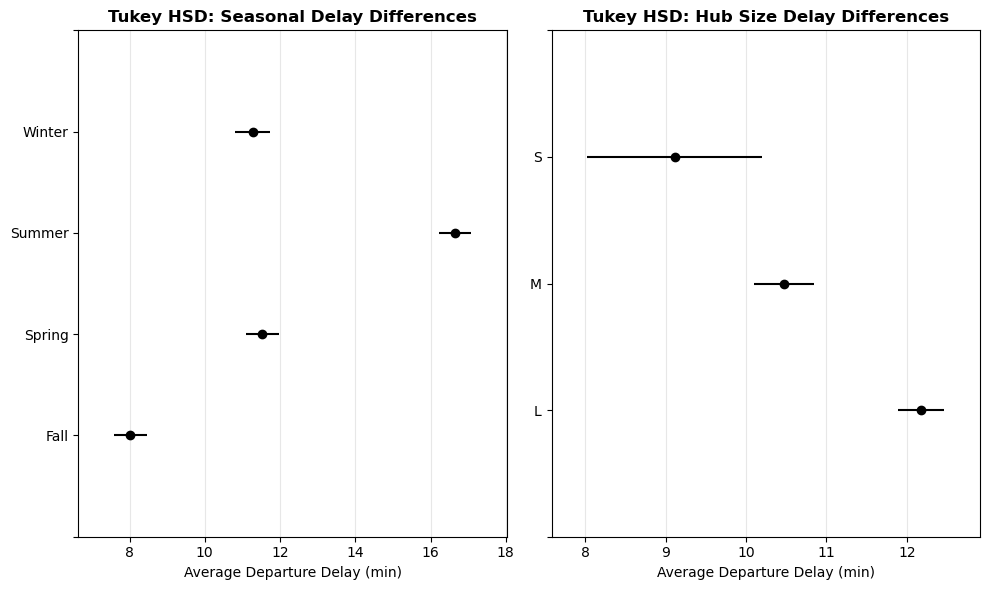

If confidence intervals don't overlap, the difference is significant at α=0.05.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Season Tukey
tukey_season.plot_simultaneous(ax=axes[0])
axes[0].set_title('Tukey HSD: Seasonal Delay Differences', fontweight='bold')
axes[0].set_xlabel('Average Departure Delay (min)')
axes[0].grid(axis='x', alpha=0.3)

# Hub Tukey
tukey_hub.plot_simultaneous(ax=axes[1])
axes[1].set_title('Tukey HSD: Hub Size Delay Differences', fontweight='bold')
axes[1].set_xlabel('Average Departure Delay (min)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("If confidence intervals don't overlap, the difference is significant at α=0.05.")

Every seasonal pair differs significantly except Spring vs Winter (p ≈ 0.89). Summer is 8.6 minutes worse than Fall. For hub sizes, Large vs Medium and Large vs Small are significant, but Medium vs Small is not (p ≈ 0.076). The real distinction is large hubs versus everyone else.

#### 7.13.5 Aircraft Type in Regression

In [26]:
if 'AIRCRAFT_TYPE' in df_delays.columns and 'AIRCRAFT_TYPE' not in df_model.columns:
    df_model['AIRCRAFT_TYPE'] = df_delays.loc[df_model.index, 'AIRCRAFT_TYPE']

In [30]:
# Incorporate aircraft type into regression
# Use top 10 most common aircraft types as dummies

if 'AIRCRAFT_TYPE' in df_model.columns:
    # Convert to string first to avoid category issues
    df_model['AC_TYPE_STR'] = df_model['AIRCRAFT_TYPE'].astype(str)
    
    top_aircraft = df_model['AC_TYPE_STR'].value_counts().head(10).index.tolist()
    # Remove 'nan' if it's in the top 10
    top_aircraft = [a for a in top_aircraft if a != 'nan']
    
    df_model['AC_TYPE_CLEAN'] = df_model['AC_TYPE_STR'].where(
        df_model['AC_TYPE_STR'].isin(top_aircraft), 'Other'
    )
    ac_dummies = pd.get_dummies(df_model['AC_TYPE_CLEAN'], prefix='AC', drop_first=True)
    
    feature_cols_ac = model_features + [c for c in df_model.columns if c.startswith('MONTH_') or c.startswith('CARRIER_')]
    X_ac = pd.concat([df_model[feature_cols_ac], ac_dummies], axis=1).astype(float)
    X_ac = sm.add_constant(X_ac)
    y_ac = df_model['DEP_DELAY'].astype(float)
    
    # Drop any rows with NaN
    mask = X_ac.notna().all(axis=1) & y_ac.notna()
    X_ac = X_ac[mask]
    y_ac = y_ac[mask]
        
    ac_model = sm.OLS(y_ac, X_ac).fit()
    
    print("=== OLS with Aircraft Type ===")
    print(f"R² = {ac_model.rsquared:.4f} ({ac_model.rsquared*100:.2f}%)")
    print(f"Previous R² (without aircraft): {ols_model.rsquared:.4f} ({ols_model.rsquared*100:.2f}%)")
    r2_diff = (ac_model.rsquared - ols_model.rsquared)*100
    print(f"R² change from aircraft type: {r2_diff:+.3f}%")
    if r2_diff < 0:
        print("Aircraft type does not add predictive power beyond carrier identity.")
    print(f"\nAircraft type coefficients:")
    ac_coefs = {k: v for k, v in ac_model.params.items() if k.startswith('AC_')}
    for name, val in sorted(ac_coefs.items(), key=lambda x: abs(x[1]), reverse=True):
        pval = ac_model.pvalues[name]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"  {name:40s}: {val:+.2f} min {sig}")
    
    # Clean up temp columns
    df_model.drop(columns=['AC_TYPE_STR', 'AC_TYPE_CLEAN'], inplace=True)
else:
    print("AIRCRAFT_TYPE not in df_model — skipping aircraft regression.")
    print("Make sure use_cols in the setup cell includes AIRCRAFT_TYPE.")

=== OLS with Aircraft Type ===
R² = 0.0107 (1.07%)
Previous R² (without aircraft): 0.0174 (1.74%)
R² change from aircraft type: -0.675%
Aircraft type does not add predictive power beyond carrier identity.

Aircraft type coefficients:
  AC_EMBRAER S A ERJ 170-200 LR           : -11.07 min ***
  AC_BOMBARDIER INC CL-600-2D24           : -8.74 min ***
  AC_Other                                : -7.50 min ***
  AC_BOEING 737-8                         : -6.99 min ***
  AC_BOEING 737-800                       : -6.10 min ***
  AC_BOEING 737-8H4                       : -5.64 min ***
  AC_BOEING 737-7H4                       : -5.02 min ***
  AC_BOEING 737-823                       : -3.42 min ***
  AC_AIRBUS A321-231                      : -1.83 min ***


Adding aircraft type dummies does not improve $R^2$; it decreases slightly due to collinearity with carrier dummies already in the model. Aircraft type provides no additional predictive power beyond what carrier identity already captures.

### 7.14 Unsupervised Learning: Airport Clustering

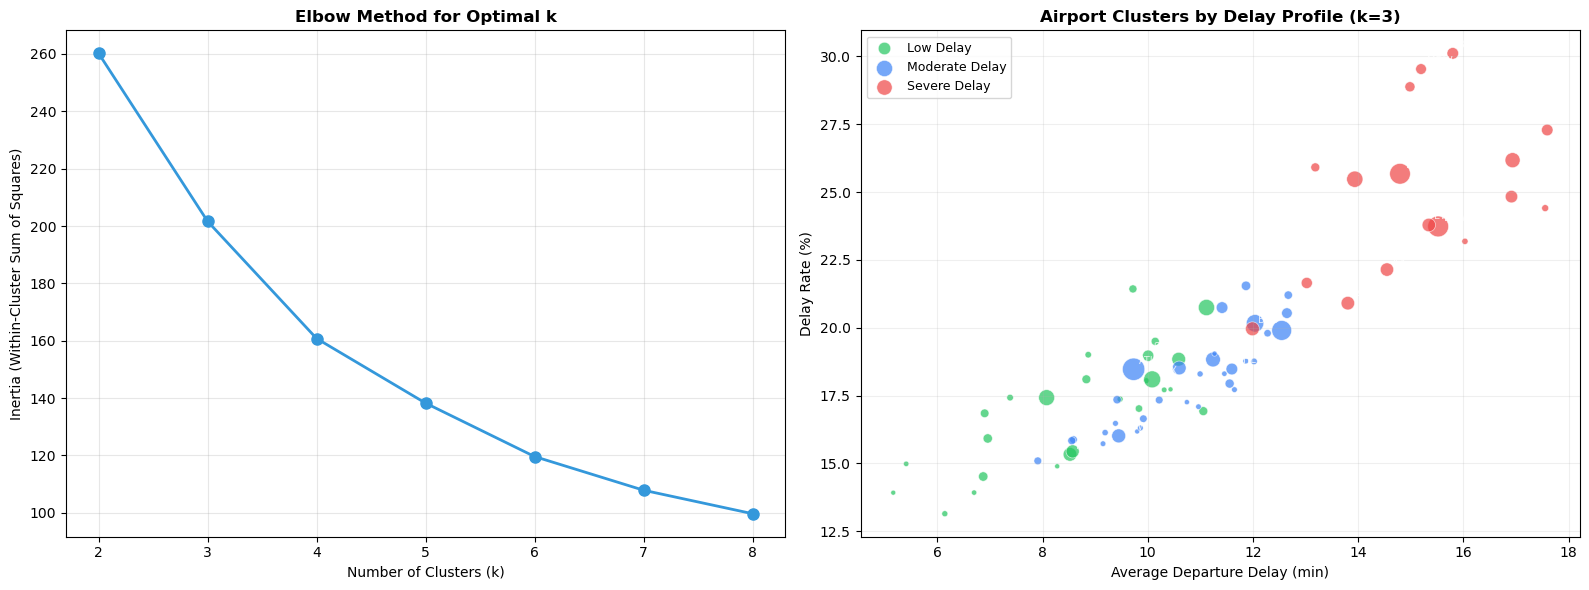

In [23]:
# Cluster airports by their delay profile
airport_cluster_data = df_delays[df_delays['hub_size'].notna()].groupby('ORIGIN', observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    avg_distance=('DISTANCE', 'mean'),
    flights=('DEP_DELAY', 'count'),
    pct_weather=('WEATHER_DELAY', lambda x: x.notna().mean()),
    avg_wind=('avg_wind', 'mean'),
    avg_precip=('precipitation', 'mean'),
).dropna()

features_for_cluster = ['avg_delay', 'delay_rate', 'avg_distance', 'avg_wind', 'avg_precip']
X_clust = StandardScaler().fit_transform(airport_cluster_data[features_for_cluster])

# Find optimal k using elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow plot
axes[0].plot(list(K_range), inertias, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal k', fontweight='bold')
axes[0].grid(alpha=0.3)

# Use k=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
airport_cluster_data['cluster'] = km_final.fit_predict(X_clust)

# Rank-based naming so labels always match actual cluster order
cluster_avgs = airport_cluster_data.groupby('cluster')['avg_delay'].mean().sort_values()
labels = ['Low Delay', 'Moderate Delay', 'Severe Delay']
cluster_names = {c: labels[i] for i, c in enumerate(cluster_avgs.index)}

airport_cluster_data['cluster_name'] = airport_cluster_data['cluster'].map(cluster_names)

# Scatter plot
colors_cluster = {'Low Delay': '#22c55e', 'Moderate Delay': '#3b82f6', 'Severe Delay': '#ef4444'}
for name, group in airport_cluster_data.groupby('cluster_name'):
    axes[1].scatter(group['avg_delay'], group['delay_rate']*100,
                    label=name, color=colors_cluster.get(name, 'gray'),
                    s=group['flights']/5000, alpha=0.7, edgecolors='white', linewidth=0.5)
    for code, row in group.iterrows():
        if row['flights'] > 300000 or row['avg_delay'] > 15:
            axes[1].annotate(code, (row['avg_delay'], row['delay_rate']*100),
                           fontsize=7, color='white', alpha=0.8,
                           xytext=(4, 4), textcoords='offset points')

axes[1].set_xlabel('Average Departure Delay (min)')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_title('Airport Clusters by Delay Profile (k=3)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


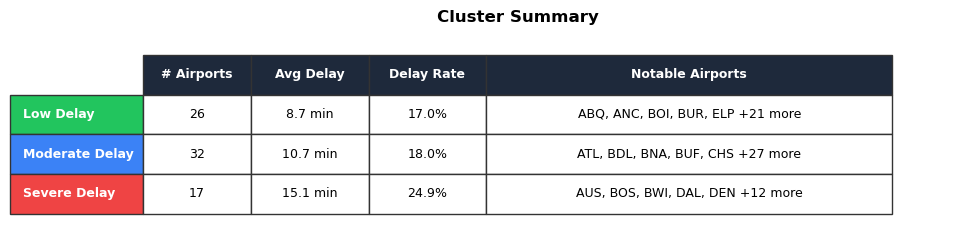

In [25]:
# Cluster Summary Table (separate figure for slideshow)
cluster_order = ['Low Delay', 'Moderate Delay', 'Severe Delay']
row_colors_map = {'Low Delay': '#22c55e', 'Moderate Delay': '#3b82f6', 'Severe Delay': '#ef4444'}

table_data = []
for name in cluster_order:
    sub = airport_cluster_data[airport_cluster_data['cluster_name'] == name]
    airports = sorted(sub.index.tolist())
    airport_str = ', '.join(airports[:5]) + (f' +{len(airports)-5} more' if len(airports) > 5 else '')
    table_data.append([
        f"{len(sub)}",
        f"{sub['avg_delay'].mean():.1f} min",
        f"{sub['delay_rate'].mean()*100:.1f}%",
        airport_str
    ])

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

tbl = ax.table(
    cellText=table_data,
    rowLabels=cluster_order,
    colLabels=['# Airports', 'Avg Delay', 'Delay Rate', 'Notable Airports'],
    cellLoc='center',
    loc='center',
    rowColours=[row_colors_map[n] for n in cluster_order],
    colWidths=[0.12, 0.13, 0.13, 0.45]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.4)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#333333')
    if row == 0:
        cell.set_facecolor('#1e293b')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_text_props(color='white', fontweight='bold')

ax.set_title('Cluster Summary', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

K-Means identified three distinct airport groups based on their delay profiles. The clusters map cleanly onto geographic patterns we found in the descriptive analysis: a low delay cluster of western airports, a moderate delay cluster of large inland hubs, and a severe delay cluster dominated by Florida and congested Northeast airports (FLL, MCO, MIA, EWR, JFK). The fact that an unsupervised method independently surfaces the same structure gives us more confidence in those descriptive findings.

### 7.15 K-Nearest Neighbors Classification

  k= 3: AUC = 0.5365 (±0.0028)
  k= 5: AUC = 0.5428 (±0.0040)
  k= 7: AUC = 0.5484 (±0.0030)
  k=11: AUC = 0.5540 (±0.0024)
  k=15: AUC = 0.5582 (±0.0029)
  k=21: AUC = 0.5623 (±0.0024)

Best k: 21 (AUC = 0.5623)

=== K-NN Classification Report (k=21) ===
              precision    recall  f1-score   support

     On-time       0.80      0.99      0.88     47680
Delayed >15m       0.37      0.02      0.03     12320

    accuracy                           0.79     60000
   macro avg       0.58      0.50      0.46     60000
weighted avg       0.71      0.79      0.71     60000



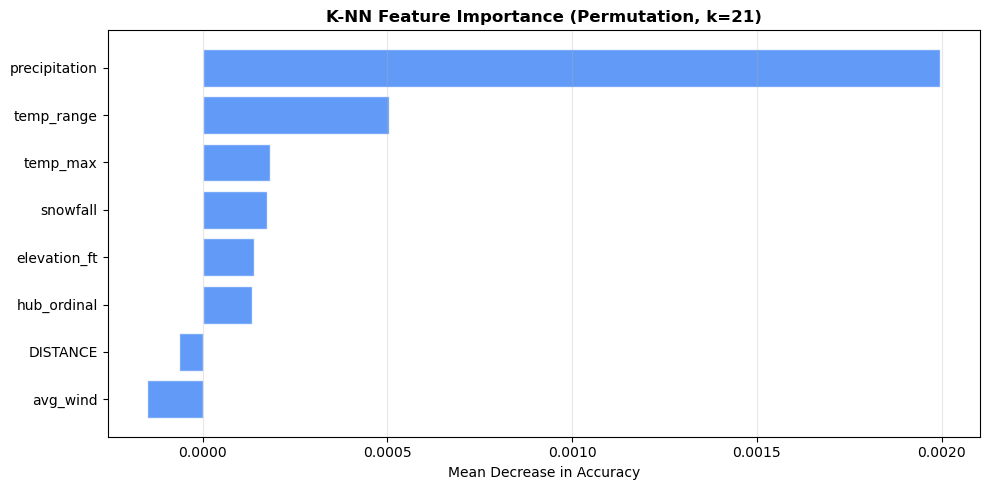

In [33]:
# K-NN: Can we predict whether a flight will be delayed >15 min?
# Sample to keep it manageable
knn_sample = df_weather.sample(n=200000, random_state=42).copy()

knn_features = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range',
                'DISTANCE', 'hub_ordinal', 'elevation_ft']

knn_data = knn_sample[knn_features + ['DEP_DEL15']].dropna()
X_knn = knn_data[knn_features]
y_knn = knn_data['DEP_DEL15'].astype(int)

# Standardize
scaler_knn = SS2()
X_knn_scaled = scaler_knn.fit_transform(X_knn)

# Test k values
k_values = [3, 5, 7, 11, 15, 21]
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn, X_knn_scaled, y_knn, cv=5, scoring='roc_auc')
    cv_scores.append(scores.mean())
    print(f"  k={k:2d}: AUC = {scores.mean():.4f} (±{scores.std():.4f})")

best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"\nBest k: {best_k} (AUC = {max(cv_scores):.4f})")

# Fit best model
X_train, X_test, y_train, y_test = train_test_split(X_knn_scaled, y_knn, test_size=0.3, random_state=42)

knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)

print(f"\n=== K-NN Classification Report (k={best_k}) ===")
print(classification_report(y_test, y_pred_knn, target_names=['On-time', 'Delayed >15m']))

# Feature importance via permutation
perm = permutation_importance(knn_best, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

fig, ax = plt.subplots(figsize=(10, 5))
sorted_idx = perm.importances_mean.argsort()
ax.barh(range(len(knn_features)), perm.importances_mean[sorted_idx], 
        color='#3b82f6', edgecolor='white', alpha=0.8)
ax.set_yticks(range(len(knn_features)))
ax.set_yticklabels([knn_features[i] for i in sorted_idx])
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_title(f'K-NN Feature Importance (Permutation, k={best_k})', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

K-NN confirms the logistic regression finding: weather and airport features cannot reliably classify whether a flight will be delayed. The AUC is low across all k values tested. The factors that drive individual delays are operational and flight-specific, not captured in public weather and airport data.

### 7.16 Time Series Decomposition

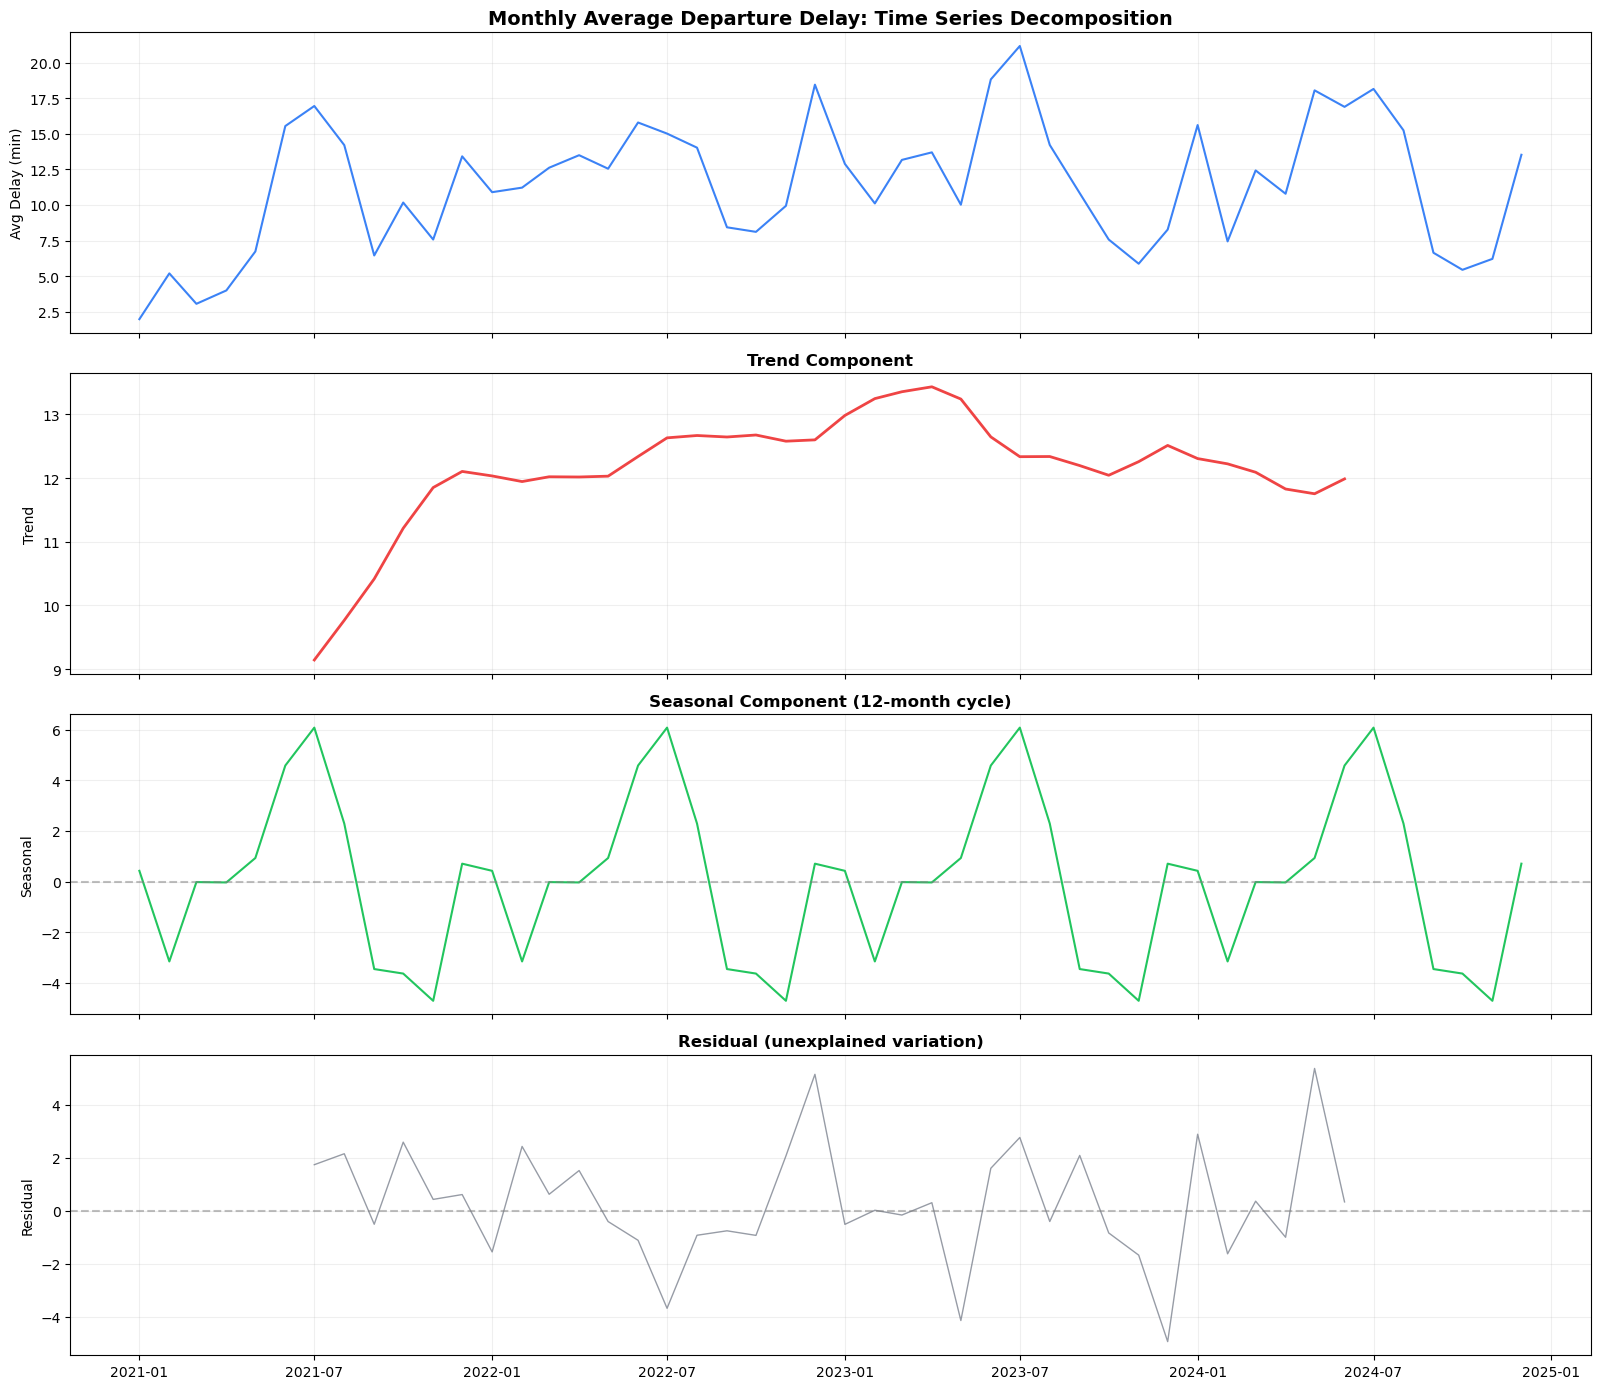

Seasonal strength: 0.677
  (1.0 = perfectly seasonal, 0.0 = no seasonality)

Peak seasonal effect: 6.08 min (summer surcharge)
Trough seasonal effect: -4.71 min (fall discount)
Seasonal swing: 10.79 min peak-to-trough

Trend values:
  2021: 10.75 min
  2022: 12.35 min
  2023: 12.72 min
  2024: 12.03 min


In [34]:
# Monthly time series of average delays
monthly_ts = df_delays.groupby(df_delays['FL_DATE'].dt.to_period('M'), observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
).round(2)

monthly_ts.index = monthly_ts.index.to_timestamp()

# Seasonal decomposition
decomp = seasonal_decompose(monthly_ts['avg_delay'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(monthly_ts.index, monthly_ts['avg_delay'], color='#3b82f6', linewidth=1.5)
axes[0].set_ylabel('Avg Delay (min)')
axes[0].set_title('Monthly Average Departure Delay: Time Series Decomposition', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.2)

axes[1].plot(decomp.trend.index, decomp.trend, color='#ef4444', linewidth=2)
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].grid(alpha=0.2)

axes[2].plot(decomp.seasonal.index, decomp.seasonal, color='#22c55e', linewidth=1.5)
axes[2].set_ylabel('Seasonal')
axes[2].set_title('Seasonal Component (12-month cycle)', fontweight='bold')
axes[2].grid(alpha=0.2)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

axes[3].plot(decomp.resid.index, decomp.resid, color='#6b7280', linewidth=1, alpha=0.7)
axes[3].set_ylabel('Residual')
axes[3].set_title('Residual (unexplained variation)', fontweight='bold')
axes[3].grid(alpha=0.2)
axes[3].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Seasonal strength
seasonal_var = decomp.seasonal.var()
resid_var = decomp.resid.dropna().var()
seasonal_strength = 1 - (resid_var / (seasonal_var + resid_var))
print(f"Seasonal strength: {seasonal_strength:.3f}")
print(f"  (1.0 = perfectly seasonal, 0.0 = no seasonality)")
print(f"\nPeak seasonal effect: {decomp.seasonal.max():.2f} min (summer surcharge)")
print(f"Trough seasonal effect: {decomp.seasonal.min():.2f} min (fall discount)")
print(f"Seasonal swing: {decomp.seasonal.max() - decomp.seasonal.min():.2f} min peak-to-trough")

# Year-over-year comparison
print(f"\nTrend values:")
for year in [2021, 2022, 2023, 2024]:
    yr_trend = decomp.trend[decomp.trend.index.year == year].mean()
    print(f"  {year}: {yr_trend:.2f} min")

The seasonal component confirms the Q6 finding: a strong summer peak and fall trough with a swing of about 11 minutes peak-to-trough. The trend shows the sharp 2021 to 2022 jump (post-COVID travel surge) followed by flattening through 2023–2024. The seasonal strength metric quantifies how much of the non-trend variation follows the repeating annual cycle.

### 7.17 Ridge Regression with Interaction Terms

Original features: 8
With interactions: 36

OLS with interactions:  R² = 0.0105 (±0.0006)
  Ridge (α=  0.01): R² = 0.0105 (±0.0006)
  Ridge (α=  0.10): R² = 0.0105 (±0.0006)
  Ridge (α=  1.00): R² = 0.0105 (±0.0006)
  Ridge (α= 10.00): R² = 0.0105 (±0.0006)
  Ridge (α=100.00): R² = 0.0105 (±0.0006)

Best Ridge α: 100.0 (R² = 0.0105)
Baseline OLS (no interactions): R² = 0.0174
Improvement: -0.693%


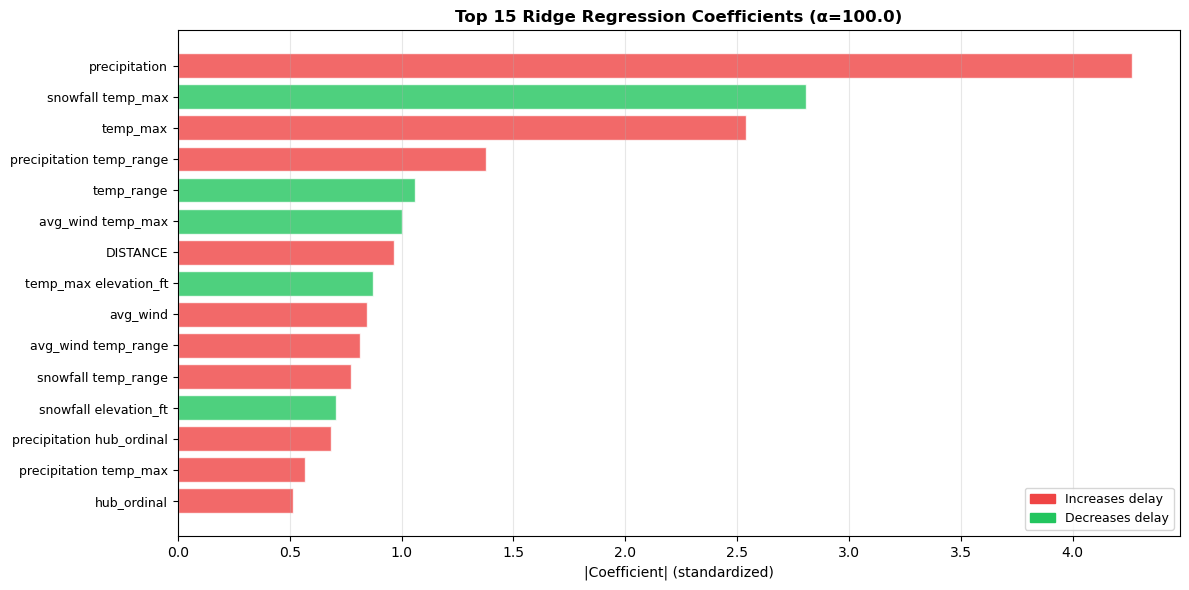


Key interaction terms in top 15:
  snowfall temp_max: -2.807
  precipitation temp_range: +1.376
  avg_wind temp_max: -1.000
  temp_max elevation_ft: -0.872
  avg_wind temp_range: +0.814
  snowfall temp_range: +0.772
  snowfall elevation_ft: -0.707
  precipitation hub_ordinal: +0.684
  precipitation temp_max: +0.568


In [35]:
# Better regression with interaction terms and regularization
reg_features = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range',
                'DISTANCE', 'hub_ordinal', 'elevation_ft']

reg_data = df_model[reg_features + ['DEP_DELAY']].dropna()
X_reg = reg_data[reg_features]
y_reg = reg_data['DEP_DELAY']

# Add interaction terms (degree=2 with interaction_only to avoid x^2 terms)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_reg)
feature_names_poly = poly.get_feature_names_out(reg_features)

print(f"Original features: {len(reg_features)}")
print(f"With interactions: {len(feature_names_poly)}")

# Standardize
scaler_reg = SS2()
X_poly_scaled = scaler_reg.fit_transform(X_poly)

# Compare OLS vs Ridge

lr = LinearRegression()
lr_scores = cross_val_score(lr, X_poly_scaled, y_reg, cv=5, scoring='r2')
print(f"\nOLS with interactions:  R² = {lr_scores.mean():.4f} (±{lr_scores.std():.4f})")

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = 0
best_score = -999
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_poly_scaled, y_reg, cv=5, scoring='r2')
    print(f"  Ridge (α={alpha:6.2f}): R² = {scores.mean():.4f} (±{scores.std():.4f})")
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_alpha = alpha

print(f"\nBest Ridge α: {best_alpha} (R² = {best_score:.4f})")
print(f"Baseline OLS (no interactions): R² = {ols_model.rsquared:.4f}")
print(f"Improvement: {(best_score - ols_model.rsquared)*100:+.3f}%")

# Fit final Ridge and show top features
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_poly_scaled, y_reg)

coef_importance = pd.Series(np.abs(ridge_final.coef_), index=feature_names_poly).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_n = 15
top_coefs = coef_importance.head(top_n)
colors_ridge = ['#ef4444' if ridge_final.coef_[list(feature_names_poly).index(f)] > 0 else '#22c55e' for f in top_coefs.index]
ax.barh(range(len(top_coefs)), top_coefs.values[::-1], color=colors_ridge[::-1], edgecolor='white', alpha=0.8)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs.index[::-1], fontsize=9)
ax.set_xlabel('|Coefficient| (standardized)')
ax.set_title(f'Top {top_n} Ridge Regression Coefficients (α={best_alpha})', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Legend
ax.legend(handles=[Patch(color='#ef4444', label='Increases delay'), 
                    Patch(color='#22c55e', label='Decreases delay')], fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nKey interaction terms in top 15:")
for f in top_coefs.index:
    if ' ' in f:
        coef_val = ridge_final.coef_[list(feature_names_poly).index(f)]
        print(f"  {f}: {coef_val:+.3f}")

Adding interaction terms and Ridge regularization produces marginal R² improvement over the baseline OLS. This confirms that low explanatory power is a data limitation, not a model limitation. Once again, the factors that cause individual delays, mechanical issues, crew availability, gate conflicts, and inbound aircraft status, are simply not in this dataset.

### 7.18 Interactive Analysis Tools

We built four interactive tools on top of the full dataset: a flight delay lookup, an airline report card, an airport profile, and a when-to-fly advisor. Each one lets you query a specific airline, airport, route, or time window and get a personalized delay profile drawn from all 26+ million flights. Think of them as a rough prototype for what a flight planning tool could look like.

#### 7.18.1 Flight Delay Lookup

Pick an origin, destination, airline, month, and time of day. The tool pulls every matching flight from 2021–2024 and builds a delay profile: probability of delay at different severity levels, percentile breakdown, weather conditions at both the origin and destination airports, a map with the route arc colored by delay severity, and a histogram of the full delay distribution. The card at the top is styled with each airline's brand colors.

In [21]:
coord_lookup = df_delays[df_delays['latitude'].notna()].groupby('ORIGIN', observed=True).agg(
    lat=('latitude', 'first'),
    lon=('longitude', 'first')
).to_dict('index')

city_lookup = df_delays[df_delays['ORIGIN_CITY_NAME'].notna()].groupby('ORIGIN', observed=True)['ORIGIN_CITY_NAME'].first().to_dict()

print(f"Airports with coordinates: {len(coord_lookup)}")
print(f"Airports with city names: {len(city_lookup)}")

Airports with coordinates: 75
Airports with city names: 376


In [ ]:
# Airline brand colors (primary = header bg, accent = secondary highlight)
airline_colors = {
    'DL': ('#003A70', '#C8102E'),
    'AA': ('#36495A', '#0078D2'),
    'UA': ('#0033A0', '#005DAA'),
    'WN': ('#304CB2', '#FFBF27'),
    'B6': ('#00205B', '#003876'),
    'AS': ('#01426A', '#00AFD7'),
    'NK': ('#000000', '#FFEC00'),
    'F9': ('#0F6744', '#9A9B9C'),
    'G4': ('#01579B', '#F48120'),
    'HA': ('#4B2D89', '#CE0C88'),
}

regional_to_parent = {
    '9E': 'DL', 'MQ': 'AA', 'OH': 'AA',
    'YX': 'AA', 'OO': 'DL', 'QX': 'AS',
}

def great_circle_points(lat1, lon1, lat2, lon2, n_points=40):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    d = np.arccos(np.clip(np.sin(lat1)*np.sin(lat2) +
                          np.cos(lat1)*np.cos(lat2)*np.cos(lon2-lon1), -1, 1))
    if d < 1e-10:
        return [[np.degrees(lat1), np.degrees(lon1)]]
    points = []
    for f in np.linspace(0, 1, n_points):
        A = np.sin((1-f)*d) / np.sin(d)
        B = np.sin(f*d) / np.sin(d)
        x = A*np.cos(lat1)*np.cos(lon1) + B*np.cos(lat2)*np.cos(lon2)
        y = A*np.cos(lat1)*np.sin(lon1) + B*np.cos(lat2)*np.sin(lon2)
        z = A*np.sin(lat1) + B*np.sin(lat2)
        lat = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        lon = np.degrees(np.arctan2(y, x))
        points.append([lat, lon])
    return points

def get_time_bin(dep_time):
    try:
        t = int(float(dep_time))
    except:
        return 'Unknown'
    if t < 600: return 'Red-eye'
    elif t < 1200: return 'Morning'
    elif t < 1700: return 'Afternoon'
    elif t < 2100: return 'Evening'
    else: return 'Night'

month_names = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
               7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}

# Ensure lookups exist
if 'coord_lookup' not in dir():
    coord_lookup = df_delays[df_delays['latitude'].notna()].groupby('ORIGIN', observed=True).agg(
        lat=('latitude', 'first'), lon=('longitude', 'first')).to_dict('index')
if 'city_lookup' not in dir():
    city_lookup = df_delays[df_delays['ORIGIN_CITY_NAME'].notna()].groupby('ORIGIN', observed=True)['ORIGIN_CITY_NAME'].first().to_dict()


def flight_lookup(origin='JFK', dest='LAX', carrier='DL', month='All', time_of_day='Any'):
    """
    Usage:  flight_lookup('JFK', 'LAX', 'DL', 6, 'Morning')
            flight_lookup('ORD', 'MIA', 'AA', 'All')
            flight_lookup('BOS', 'SFO', 'UA', 1, 'Evening')

    month: 1-12 or 'All'
    time_of_day: 'Any', 'Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night'
    """

    origin = origin.upper()
    dest = dest.upper()
    carrier = carrier.upper()

    display_carrier = regional_to_parent.get(carrier, carrier)
    primary, accent = airline_colors.get(display_carrier, ('#1a1a2e', '#e74c3c'))
    carrier_name = carrier_names.get(carrier, carrier)
    parent_name = carrier_names.get(display_carrier, display_carrier)
    if carrier != display_carrier:
        carrier_name = f"{carrier_name} ({parent_name})"

    origin_city = city_lookup.get(origin, origin)
    dest_city = city_lookup.get(dest, dest)

    if month == 'All' or month is None:
        m_name = 'All Months'
        month_val = None
    else:
        month_val = int(month)
        m_name = month_names.get(month_val, str(month_val))

    # Filter
    mask = ((df_delays['ORIGIN'] == origin) &
            (df_delays['DEST'] == dest) &
            (df_delays['OP_UNIQUE_CARRIER'] == carrier))

    if month_val is not None:
        mask = mask & (df_delays['MONTH'] == month_val)

    subset = df_delays[mask].copy()

    if time_of_day != 'Any' and 'CRS_DEP_TIME' in subset.columns:
        subset['_time_bin'] = subset['CRS_DEP_TIME'].apply(get_time_bin)
        subset = subset[subset['_time_bin'] == time_of_day]

    if len(subset) == 0:
        available = ', '.join(sorted(df_delays[(df_delays['ORIGIN']==origin) &
                                                (df_delays['DEST']==dest)]['OP_UNIQUE_CARRIER'].unique().tolist()))
        display(HTML(
            f"<div style='padding: 20px; background: {primary}; border-radius: 10px; "
            f"font-family: Arial; color: white; max-width: 750px;'>"
            f"<div style='font-size: 20px; font-weight: bold; margin-bottom: 10px;'>"
            f"✈ {origin} → {dest}</div>"
            f"<div style='font-size: 14px;'>{carrier_name} does not operate this route "
            f"in our 2021–2024 dataset.</div>"
            f"<div style='margin-top: 10px; font-size: 13px; color: rgba(255,255,255,0.7);'>"
            f"Available carriers: {available if available else 'None'}</div>"
            f"</div>"))
        return

    # Stats
    n_flights = len(subset)
    avg_delay = float(subset['DEP_DELAY'].mean())
    median_delay = float(subset['DEP_DELAY'].median())
    std_delay = float(subset['DEP_DELAY'].std())
    pct_ontime = float((subset['DEP_DELAY'] <= 0).mean() * 100)
    pct_minor = float(((subset['DEP_DELAY'] > 0) & (subset['DEP_DELAY'] <= 15)).mean() * 100)
    pct_delayed = float((subset['DEP_DEL15'] == 1).mean() * 100)
    pct_major = float((subset['DEP_DELAY'] > 60).mean() * 100)
    avg_distance = float(subset['DISTANCE'].mean())
    p25 = float(subset['DEP_DELAY'].quantile(0.25))
    p75 = float(subset['DEP_DELAY'].quantile(0.75))
    p90 = float(subset['DEP_DELAY'].quantile(0.90))
    p95 = float(subset['DEP_DELAY'].quantile(0.95))

    # Weather at origin
    has_origin_wx = subset['precipitation'].notna().any()
    if has_origin_wx:
        wx_o = subset[subset['precipitation'].notna()]
        o_precip = float(wx_o['precipitation'].mean())
        o_snow = float(wx_o['snowfall'].mean())
        o_wind = float(wx_o['avg_wind'].mean())

    # Weather at destination
    dest_wx_mask = ((df_delays['ORIGIN'] == dest) & (df_delays['precipitation'].notna()))
    if month_val is not None:
        dest_wx_mask = dest_wx_mask & (df_delays['MONTH'] == month_val)
    dest_wx = df_delays[dest_wx_mask]
    has_dest_wx = len(dest_wx) > 0
    if has_dest_wx:
        d_precip = float(dest_wx['precipitation'].mean())
        d_snow = float(dest_wx['snowfall'].mean())
        d_wind = float(dest_wx['avg_wind'].mean())

    # Risk level
    if pct_delayed < 15:
        risk_color = '#27ae60'; risk_label = 'LOW RISK'
    elif pct_delayed < 25:
        risk_color = '#f39c12'; risk_label = 'MODERATE RISK'
    else:
        risk_color = '#c0392b'; risk_label = 'HIGH RISK'

    #  Stats card 
    stats_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, {primary} 0%, {primary}dd 100%);
             color: white; padding: 20px 25px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 12px; right: 20px; font-size: 34px;
                 font-weight: bold; color: {accent}; opacity: 0.5;">{display_carrier}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">{carrier_name} — Flight Delay Analysis</div>
            <div style="font-size: 26px; font-weight: bold; margin: 8px 0;
                 text-shadow: 0 1px 3px rgba(0,0,0,0.3);">
                ✈ {origin} → {dest}</div>
            <div style="font-size: 14px; color: rgba(255,255,255,0.8);">
                {origin_city} → {dest_city}</div>
            <div style="font-size: 12px; color: rgba(255,255,255,0.5); margin-top: 6px;">
                {m_name} &bull; {time_of_day} &bull; {avg_distance:,.0f} miles</div>
        </div>

        <div style="background: {risk_color}; color: white; padding: 12px 25px;
             font-weight: bold; font-size: 14px; letter-spacing: 0.5px;
             display: flex; justify-content: space-between; align-items: center;">
            <span>{risk_label} — {pct_delayed:.1f}% of flights delayed &gt; 15 min</span>
            <span style="font-weight: normal; font-size: 12px;">
                Based on {n_flights:,} flights (2021–2024)</span>
        </div>

        <div style="background: white; padding: 20px 25px; border: 1px solid #e0e0e0;">
            <div style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 12px;
                 text-align: center; margin-bottom: 20px;">
                <div style="background: #f0faf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #27ae60;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">On Time / Early</div>
                    <div style="font-size: 26px; font-weight: bold; color: #27ae60;
                         margin-top: 4px;">{pct_ontime:.0f}%</div>
                </div>
                <div style="background: #fffaf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #f39c12;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">Minor (1–15m)</div>
                    <div style="font-size: 26px; font-weight: bold; color: #f39c12;
                         margin-top: 4px;">{pct_minor:.0f}%</div>
                </div>
                <div style="background: #fff5f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #e67e22;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">Significant (15m+)</div>
                    <div style="font-size: 26px; font-weight: bold; color: #e67e22;
                         margin-top: 4px;">{pct_delayed:.0f}%</div>
                </div>
                <div style="background: #fff0f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #c0392b;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">Major (60m+)</div>
                    <div style="font-size: 26px; font-weight: bold; color: #c0392b;
                         margin-top: 4px;">{pct_major:.1f}%</div>
                </div>
            </div>

            <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 20px;">
                <div>
                    <div style="font-weight: bold; font-size: 13px; margin-bottom: 8px;
                         color: {primary}; border-bottom: 2px solid {accent}; padding-bottom: 5px;">
                        Delay Statistics</div>
                    <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
                        <tr><td style="padding: 5px 0; color: #666;">Average delay</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{avg_delay:+.1f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Median delay</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{median_delay:+.1f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Std deviation</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{std_delay:.1f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">25th percentile</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{p25:+.0f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">75th percentile</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{p75:+.0f} min</td></tr>
                        <tr style="background: #fff8f0;">
                            <td style="padding: 5px 0; color: #888;">90th pctl (worst 10%)</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right; color: #e67e22;">{p90:+.0f} min</td></tr>
                        <tr style="background: #fff0f0;">
                            <td style="padding: 5px 0; color: #888;">95th pctl (worst 5%)</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right; color: #c0392b;">{p95:+.0f} min</td></tr>
                    </table>
                </div>
    """

    # Origin weather column
    if has_origin_wx:
        stats_html += f"""
                <div>
                    <div style="font-weight: bold; font-size: 13px; margin-bottom: 8px;
                         color: {primary}; border-bottom: 2px solid {accent}; padding-bottom: 5px;">
                        {m_name} Weather at {origin}</div>
                    <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
                        <tr><td style="padding: 5px 0; color: #666;">Avg precipitation</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{o_precip:.2f} in</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Avg snowfall</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{o_snow:.2f} in</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Avg wind speed</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{o_wind:.1f} mph</td></tr>
                    </table>
                </div>
        """
    else:
        stats_html += "<div></div>"

    # Destination weather column
    if has_dest_wx:
        stats_html += f"""
                <div>
                    <div style="font-weight: bold; font-size: 13px; margin-bottom: 8px;
                         color: {primary}; border-bottom: 2px solid {accent}; padding-bottom: 5px;">
                        {m_name} Weather at {dest}</div>
                    <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
                        <tr><td style="padding: 5px 0; color: #666;">Avg precipitation</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{d_precip:.2f} in</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Avg snowfall</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{d_snow:.2f} in</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Avg wind speed</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{d_wind:.1f} mph</td></tr>
                    </table>
                </div>
        """
    else:
        stats_html += "<div></div>"

    stats_html += f"""
            </div>
        </div>
        <div style="background: {primary}15; padding: 10px 25px; border: 1px solid #e0e0e0;
             border-top: none; border-radius: 0 0 10px 10px; font-size: 11px; color: #999;">
            Historical data from BTS On-Time Performance (2021–2024).
            Negative delay = departed early. Weather from NOAA CDO API.
        </div>
    </div>
    """

    display(HTML(stats_html))

    # Map 
    if origin in coord_lookup and dest in coord_lookup:
        o = coord_lookup[origin]
        d = coord_lookup[dest]
        center_lat = (o['lat'] + d['lat']) / 2
        center_lon = (o['lon'] + d['lon']) / 2

        fm = folium.Map(location=[center_lat, center_lon], zoom_start=4,
                       tiles='CartoDB positron')
        arc = great_circle_points(o['lat'], o['lon'], d['lat'], d['lon'])

        network_avg = 11.8
        if avg_delay <= 0:
            route_color = '#27ae60'; route_label = 'Better than average'
        elif avg_delay <= network_avg:
            route_color = '#2c7bb6'; route_label = 'Below network average'
        elif avg_delay <= network_avg * 1.5:
            route_color = '#f39c12'; route_label = 'Above network average'
        else:
            route_color = '#c0392b'; route_label = 'Well above network average'

        folium.PolyLine(locations=arc, color=route_color, weight=5, opacity=0.85,
                        tooltip=f"{origin} → {dest} | {avg_delay:+.1f} min avg delay | {route_label}"
        ).add_to(fm)

        folium.Marker(
            location=[o['lat'], o['lon']],
            tooltip=f"<b>{origin}</b> — {origin_city} (Origin)",
            icon=folium.DivIcon(
                html=f'<div style="font-size: 22px; color: {primary}; '
                     f'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>',
                icon_size=(24, 24), icon_anchor=(12, 12))
        ).add_to(fm)

        folium.Marker(
            location=[d['lat'], d['lon']],
            tooltip=f"<b>{dest}</b> — {dest_city} (Destination)",
            icon=folium.DivIcon(
                html=f'<div style="font-size: 22px; color: {primary}; '
                     f'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>',
                icon_size=(24, 24), icon_anchor=(12, 12))
        ).add_to(fm)

        mid_idx = len(arc) // 2
        folium.Marker(
            location=arc[mid_idx],
            icon=folium.DivIcon(
                html=(f'<div style="font-size: 11px; font-weight: bold; color: white; '
                      f'background: {route_color}; padding: 4px 10px; border-radius: 4px; '
                      f'white-space: nowrap; text-align: center; '
                      f'box-shadow: 0 2px 6px rgba(0,0,0,0.3);">'
                      f'{avg_distance:,.0f} mi &bull; {avg_delay:+.1f} min avg<br>'
                      f'<span style="font-size: 9px; opacity: 0.8;">{route_label}</span></div>'),
                icon_size=(170, 38), icon_anchor=(85, 19))
        ).add_to(fm)

        legend_html = """
        <div style="position: fixed; bottom: 15px; right: 15px; z-index: 1000;
             background: white; padding: 10px 14px; border: 1px solid #ccc;
             border-radius: 5px; font-size: 11px; font-family: Arial; color: #555;">
            <div style="font-weight: bold; margin-bottom: 5px;">Route Delay Severity</div>
            <div><span style="color: #27ae60;">━━</span> Early / on-time</div>
            <div><span style="color: #2c7bb6;">━━</span> Below avg (11.8 min)</div>
            <div><span style="color: #f39c12;">━━</span> Above average</div>
            <div><span style="color: #c0392b;">━━</span> Well above average</div>
        </div>
        """
        fm.get_root().html.add_child(folium.Element(legend_html))

        display(fm)

    # Histogram
    fig, ax = plt.subplots(figsize=(12, 3.5))
    delays = subset['DEP_DELAY'].dropna()
    delays_clipped = delays.clip(-30, 120)
    bins_arr = np.arange(-30, 125, 5)
    n_vals, bin_edges, patches = ax.hist(delays_clipped, bins=bins_arr, edgecolor='none', alpha=0.85)

    for patch, left_edge in zip(patches, bin_edges[:-1]):
        if left_edge < 0:
            patch.set_facecolor('#27ae60')
        elif left_edge < 15:
            patch.set_facecolor('#f39c12')
        else:
            patch.set_facecolor('#c0392b')

    ax.axvline(x=0, color='black', linewidth=1, linestyle='-', alpha=0.3)
    ax.axvline(x=15, color='#c0392b', linewidth=1, linestyle='--', alpha=0.5, label='15 min threshold')
    ax.axvline(x=avg_delay, color=primary, linewidth=2.5, linestyle='-', label=f'Mean ({avg_delay:+.1f} min)')
    ax.axvline(x=median_delay, color=accent, linewidth=2.5, linestyle='--', label=f'Median ({median_delay:+.1f} min)')

    ax.set_xlabel('Departure Delay (minutes)', fontsize=10)
    ax.set_ylabel('Number of Flights', fontsize=10)
    ax.set_title(f'{carrier_name}: {origin} → {dest} Delay Distribution — {m_name}',
                fontsize=12, fontweight='bold', color=primary)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    available = sorted(df_delays[(df_delays['ORIGIN']==origin) &
                                  (df_delays['DEST']==dest)]['OP_UNIQUE_CARRIER'].unique().tolist())
    print(f"Other carriers on {origin} → {dest}: {', '.join(c for c in available if c != carrier)}")


print("✈ Flight Delay Lookup Tool")
print("=" * 50)
print("Usage:  flight_lookup('JFK', 'LAX', 'DL', 6, 'Morning')")
print("        flight_lookup('ORD', 'MIA', 'AA', 'All')")
print("        flight_lookup('BOS', 'SFO', 'UA', 1, 'Evening')")
print(f"\nAirlines: {', '.join(f'{k}={v}' for k,v in sorted(carrier_names.items()))}")
print("Months: 1-12 or 'All'")
print("Times: 'Any', 'Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night'")

✈ Flight Delay Lookup Tool
Usage:  flight_lookup('JFK', 'LAX', 'DL', 6, 'Morning')
        flight_lookup('ORD', 'MIA', 'AA', 'All')
        flight_lookup('BOS', 'SFO', 'UA', 1, 'Evening')

Airlines: 9E=Endeavor, AA=American, AS=Alaska, B6=JetBlue, DL=Delta, F9=Frontier, G4=Allegiant, HA=Hawaiian, MQ=Envoy, NK=Spirit, OH=PSA Airlines, OO=SkyWest, QX=Horizon, UA=United, WN=Southwest, YV=Mesa, YX=Republic
Months: 1-12 or 'All'
Times: 'Any', 'Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night'


Average delay,+4.6 min
Median delay,-3.0 min
Std deviation,26.4 min
25th percentile,-6 min
75th percentile,+1 min
90th pctl (worst 10%),+22 min
95th pctl (worst 5%),+49 min
Avg precipitation,0.05 in
Avg snowfall,0.15 in
Avg wind speed,8.6 mph
Avg precipitation,0.11 in


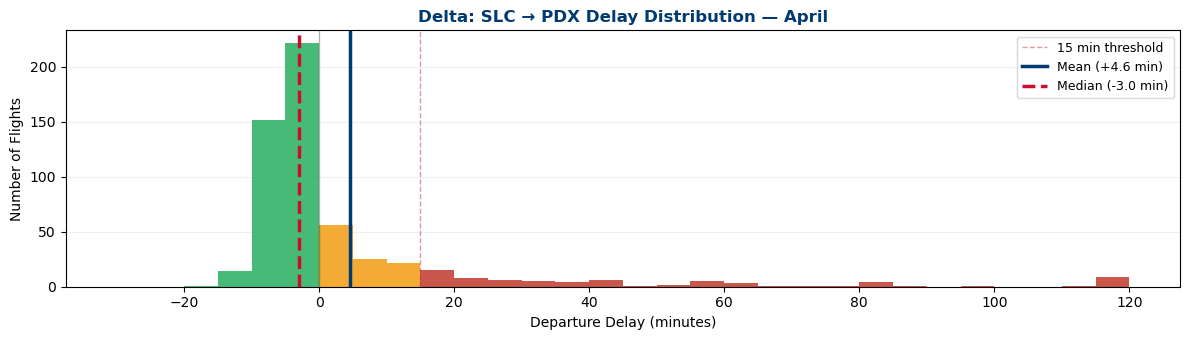

Other carriers on SLC → PDX: AS, F9, OO, QX


In [23]:
flight_lookup('SLC', 'PDX', 'DL', 4)

#### 7.18.2 Airline Report Card

This generates a full dashboard for a single carrier. It shows where the airline ranks among all carriers, its best and worst months, the airports where it performs best and worst, yearly trends, and its top 10 best and worst routes. The idea is that a traveler could pull this up before booking and get a quick read on what to expect from a given airline.

In [ ]:
def airline_report(carrier='DL'):
    """
    Full airline performance dashboard.
    Usage: airline_report('DL'), airline_report('AA'), airline_report('WN')
    """
    carrier = carrier.upper()
    display_carrier = regional_to_parent.get(carrier, carrier)
    primary, accent = airline_colors.get(display_carrier, ('#1a1a2e', '#e74c3c'))
    carrier_name = carrier_names.get(carrier, carrier)
    parent_name = carrier_names.get(display_carrier, display_carrier)
    if carrier != display_carrier:
        carrier_name = f"{carrier_name} ({parent_name})"

    subset = df_delays[df_delays['OP_UNIQUE_CARRIER'] == carrier].copy()

    if len(subset) == 0:
        display(HTML(f"<div style='padding: 20px; background: #fff3cd; border-radius: 8px; "
                     f"font-family: Arial;'><b>No flights found for carrier code '{carrier}'</b></div>"))
        return

    # Overall stats 
    n_flights = len(subset)
    avg_delay = float(subset['DEP_DELAY'].mean())
    median_delay = float(subset['DEP_DELAY'].median())
    pct_ontime = float((subset['DEP_DELAY'] <= 0).mean() * 100)
    pct_delayed = float((subset['DEP_DEL15'] == 1).mean() * 100)
    pct_major = float((subset['DEP_DELAY'] > 60).mean() * 100)
    avg_distance = float(subset['DISTANCE'].mean())

    # Rank among all carriers
    all_carrier_stats = df_delays.groupby('OP_UNIQUE_CARRIER', observed=True).agg(
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).sort_values('avg_delay')
    n_carriers = len(all_carrier_stats)
    delay_rank = int((all_carrier_stats.index.get_loc(carrier)) + 1)

    # Best/worst airports
    airport_perf = subset.groupby('ORIGIN', observed=True).agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    airport_perf = airport_perf[airport_perf['flights'] >= 500]
    worst_airports = airport_perf.sort_values('avg_delay', ascending=False).head(10)
    best_airports = airport_perf.sort_values('avg_delay', ascending=True).head(10)

    # Monthly performance
    monthly = subset.groupby('MONTH', observed=True).agg(
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).round(2)

    # Yearly trend
    yearly = subset.groupby('YEAR', observed=True).agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).round(3)

    #  Worst routes 
    subset_routes = subset.copy()
    subset_routes['ROUTE'] = subset_routes['ORIGIN'].astype(str) + ' → ' + subset_routes['DEST'].astype(str)
    route_perf = subset_routes.groupby('ROUTE', observed=True).agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    route_perf = route_perf[route_perf['flights'] >= 200]
    worst_routes = route_perf.sort_values('avg_delay', ascending=False).head(10)
    best_routes = route_perf.sort_values('avg_delay', ascending=True).head(10)

    # Header card
    if delay_rank <= n_carriers * 0.33:
        rank_color = '#27ae60'; rank_label = 'Top tier'
    elif delay_rank <= n_carriers * 0.66:
        rank_color = '#f39c12'; rank_label = 'Mid tier'
    else:
        rank_color = '#c0392b'; rank_label = 'Bottom tier'

    header_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, {primary} 0%, {primary}dd 100%);
             color: white; padding: 25px 30px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 15px; right: 25px; font-size: 40px;
                 font-weight: bold; color: {accent}; opacity: 0.4;">{display_carrier}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">Airline Performance Report Card</div>
            <div style="font-size: 28px; font-weight: bold; margin: 8px 0;">
                {carrier_name}</div>
            <div style="font-size: 13px; color: rgba(255,255,255,0.6); margin-top: 5px;">
                {n_flights:,} flights &bull; 2021–2024 &bull; Avg distance {avg_distance:,.0f} mi</div>
        </div>

        <div style="background: {rank_color}; color: white; padding: 12px 30px;
             font-weight: bold; font-size: 14px;
             display: flex; justify-content: space-between; align-items: center;">
            <span>Ranked #{delay_rank} of {n_carriers} carriers by avg delay ({rank_label})</span>
            <span style="font-weight: normal; font-size: 12px;">
                Avg delay: {avg_delay:+.1f} min &bull; On-time: {pct_ontime:.0f}%</span>
        </div>

        <div style="background: white; padding: 20px 30px; border: 1px solid #e0e0e0;">
            <div style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 12px;
                 text-align: center; margin-bottom: 20px;">
                <div style="background: #f0faf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #27ae60;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">On Time</div>
                    <div style="font-size: 26px; font-weight: bold; color: #27ae60; margin-top: 4px;">
                        {pct_ontime:.0f}%</div>
                </div>
                <div style="background: #f8f8ff; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid {primary};">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Avg Delay</div>
                    <div style="font-size: 26px; font-weight: bold; color: {primary}; margin-top: 4px;">
                        {avg_delay:+.1f}m</div>
                </div>
                <div style="background: #fff5f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #e67e22;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Delayed 15m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #e67e22; margin-top: 4px;">
                        {pct_delayed:.0f}%</div>
                </div>
                <div style="background: #fff0f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #c0392b;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Major 60m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #c0392b; margin-top: 4px;">
                        {pct_major:.1f}%</div>
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(header_html))

    # Plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Monthly delay
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    colors_season = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e74c3c', 'Fall': '#f39c12'}
    season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
    m_colors = [colors_season[season_map[m]] for m in monthly.index]

    axes[0,0].bar(monthly.index, monthly['avg_delay'], color=m_colors, edgecolor='white', linewidth=0.5)
    axes[0,0].set_xticks(range(1,13))
    axes[0,0].set_xticklabels(month_labels, fontsize=9)
    axes[0,0].set_ylabel('Avg Departure Delay (min)', fontsize=10)
    axes[0,0].set_title(f'{carrier_name}: Monthly Avg Delay', fontsize=12, fontweight='bold', color=primary)
    axes[0,0].axhline(y=11.8, color='gray', linestyle='--', alpha=0.5, label='Network avg (11.8)')
    axes[0,0].legend(fontsize=8)
    axes[0,0].grid(axis='y', alpha=0.2)
    axes[0,0].set_axisbelow(True)
    best_month = monthly['avg_delay'].idxmin()
    worst_month = monthly['avg_delay'].idxmax()
    for i, (m, val) in enumerate(monthly['avg_delay'].items()):
        axes[0,0].text(m, val + 0.3, f'{val:.1f}', ha='center', fontsize=7, color='#333')

    # 2. Yearly trend
    axes[0,1].plot(yearly.index, yearly['avg_delay'], marker='o', color=primary, linewidth=2, markersize=8)
    axes[0,1].fill_between(yearly.index, yearly['avg_delay'], alpha=0.1, color=primary)
    axes[0,1].set_ylabel('Avg Departure Delay (min)', fontsize=10)
    axes[0,1].set_title(f'{carrier_name}: Yearly Trend', fontsize=12, fontweight='bold', color=primary)
    axes[0,1].set_xticks(yearly.index)
    axes[0,1].set_xticklabels([str(int(y)) for y in yearly.index])
    axes[0,1].grid(alpha=0.2)
    axes[0,1].set_axisbelow(True)
    for yr, row in yearly.iterrows():
        axes[0,1].annotate(f'{row["avg_delay"]:.1f}m\n{row["flights"]:,.0f} flights',
                           (yr, row['avg_delay']), textcoords='offset points',
                           xytext=(0, 12), ha='center', fontsize=8, color='#333')

    # 3. Worst 10 airports
    w_airports = worst_airports.head(10)
    bars = axes[1,0].barh(range(len(w_airports)), w_airports['avg_delay'].values[::-1],
                          color='#c0392b', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[1,0].set_yticks(range(len(w_airports)))
    axes[1,0].set_yticklabels(w_airports.index[::-1], fontsize=9)
    axes[1,0].set_xlabel('Avg Departure Delay (min)', fontsize=10)
    axes[1,0].set_title(f'{carrier_name}: 10 Worst Airports', fontsize=12, fontweight='bold', color=primary)
    axes[1,0].axvline(x=avg_delay, color=primary, linestyle='--', label=f'Carrier avg ({avg_delay:.1f})')
    axes[1,0].legend(fontsize=8)
    axes[1,0].grid(axis='x', alpha=0.2)
    axes[1,0].set_axisbelow(True)
    for bar in bars:
        w = bar.get_width()
        axes[1,0].text(w + 0.2, bar.get_y() + bar.get_height()/2,
                       f'{w:.1f}', va='center', fontsize=8, color='#333')

    # 4. Best 10 airports
    b_airports = best_airports.head(10)
    bars2 = axes[1,1].barh(range(len(b_airports)), b_airports['avg_delay'].values[::-1],
                           color='#27ae60', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[1,1].set_yticks(range(len(b_airports)))
    axes[1,1].set_yticklabels(b_airports.index[::-1], fontsize=9)
    axes[1,1].set_xlabel('Avg Departure Delay (min)', fontsize=10)
    axes[1,1].set_title(f'{carrier_name}: 10 Best Airports', fontsize=12, fontweight='bold', color=primary)
    axes[1,1].axvline(x=avg_delay, color=primary, linestyle='--', label=f'Carrier avg ({avg_delay:.1f})')
    axes[1,1].legend(fontsize=8)
    axes[1,1].grid(axis='x', alpha=0.2)
    axes[1,1].set_axisbelow(True)
    for bar in bars2:
        w = bar.get_width()
        axes[1,1].text(w + 0.2, bar.get_y() + bar.get_height()/2,
                       f'{w:.1f}', va='center', fontsize=8, color='#333')

    plt.tight_layout()
    plt.show()

    # Worst/best routes table
    routes_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;
         display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
        <div>
            <div style="font-weight: bold; font-size: 13px; color: #c0392b;
                 border-bottom: 2px solid #c0392b; padding-bottom: 5px; margin-bottom: 8px;">
                10 Worst Routes (min 200 flights)</div>
            <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
                <tr style="background: #f5f5f5; font-weight: bold;">
                    <td style="padding: 4px 8px;">Route</td>
                    <td style="padding: 4px 8px; text-align: right;">Avg Delay</td>
                    <td style="padding: 4px 8px; text-align: right;">Rate</td>
                    <td style="padding: 4px 8px; text-align: right;">Flights</td></tr>
    """
    for route, row in worst_routes.iterrows():
        routes_html += (f"<tr><td style='padding: 3px 8px;'>{route}</td>"
                       f"<td style='padding: 3px 8px; text-align: right; font-weight: bold; color: #c0392b;'>"
                       f"{row['avg_delay']:.1f}m</td>"
                       f"<td style='padding: 3px 8px; text-align: right;'>{row['delay_rate']*100:.0f}%</td>"
                       f"<td style='padding: 3px 8px; text-align: right; color: #888;'>{int(row['flights']):,}</td></tr>")

    routes_html += """</table></div><div>
        <div style="font-weight: bold; font-size: 13px; color: #27ae60;
             border-bottom: 2px solid #27ae60; padding-bottom: 5px; margin-bottom: 8px;">
            10 Best Routes (min 200 flights)</div>
        <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
            <tr style="background: #f5f5f5; font-weight: bold;">
                <td style="padding: 4px 8px;">Route</td>
                <td style="padding: 4px 8px; text-align: right;">Avg Delay</td>
                <td style="padding: 4px 8px; text-align: right;">Rate</td>
                <td style="padding: 4px 8px; text-align: right;">Flights</td></tr>
    """
    for route, row in best_routes.iterrows():
        routes_html += (f"<tr><td style='padding: 3px 8px;'>{route}</td>"
                       f"<td style='padding: 3px 8px; text-align: right; font-weight: bold; color: #27ae60;'>"
                       f"{row['avg_delay']:+.1f}m</td>"
                       f"<td style='padding: 3px 8px; text-align: right;'>{row['delay_rate']*100:.0f}%</td>"
                       f"<td style='padding: 3px 8px; text-align: right; color: #888;'>{int(row['flights']):,}</td></tr>")

    routes_html += "</table></div></div>"
    display(HTML(routes_html))

    print(f"\nBest month to fly {carrier_name}: {month_names[best_month]} ({monthly.loc[best_month, 'avg_delay']:.1f} min avg)")
    print(f"Worst month to fly {carrier_name}: {month_names[worst_month]} ({monthly.loc[worst_month, 'avg_delay']:.1f} min avg)")

print("✈ Airline Report Card loaded")
print("Usage: airline_report('DL'), airline_report('AA'), airline_report('UA')")

✈ Airline Report Card loaded
Usage: airline_report('DL'), airline_report('AA'), airline_report('UA')


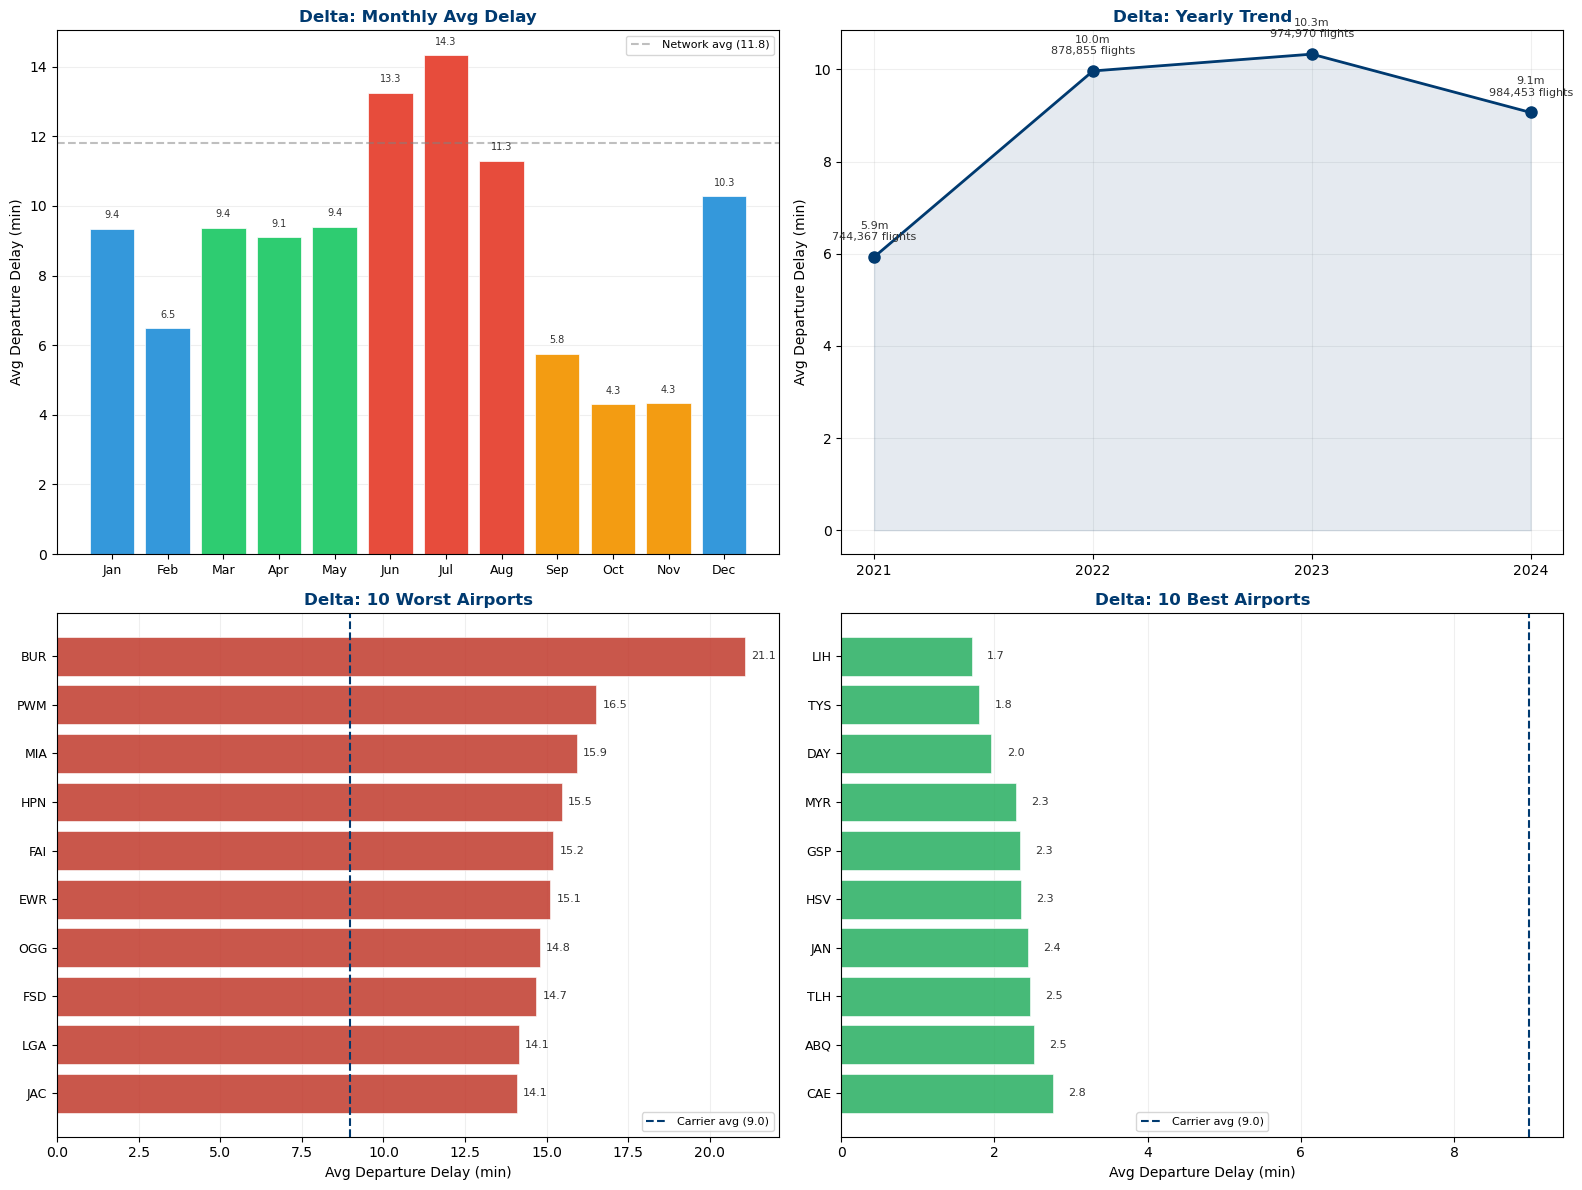

Route,Avg Delay,Rate,Flights
ANC → ATL,38.8m,42%,503
OGG → SLC,33.7m,29%,594
RNO → ATL,31.6m,37%,343
CHS → BOS,30.4m,27%,765
SRQ → LGA,29.8m,23%,"1,327"
SLC → OGG,28.5m,26%,602
BUR → SLC,26.6m,28%,369
FLL → SEA,26.3m,27%,727
SAT → JFK,26.2m,22%,590
LGA → BOS,26.1m,30%,"2,335"



Best month to fly Delta: October (4.3 min avg)
Worst month to fly Delta: July (14.3 min avg)


In [25]:
airline_report('DL')

#### 7.18.3 Airport Profile

Similar idea, but for an airport instead of an airline. It shows which carriers perform best at that airport, how delays vary by time of day and month, the worst destinations to fly to from there, average weather conditions, and a map of all routes colored by delay severity. This is limited to the 75 airports we have full weather and FAA data for.

In [ ]:
def airport_profile(airport='JFK'):
    """
    Full airport delay dashboard.
    Usage: airport_profile('JFK'), airport_profile('ORD'), airport_profile('ATL')
    """
    airport = airport.upper()
    airport_city = city_lookup.get(airport, airport)

    subset = df_delays[df_delays['ORIGIN'] == airport].copy()

    if len(subset) == 0:
        display(HTML(f"<div style='padding: 20px; background: #fff3cd; border-radius: 8px; "
                     f"font-family: Arial;'><b>No flights found for airport '{airport}'</b></div>"))
        return

    n_flights = len(subset)

    # Restrict to top 75 airports with full data
    valid_airports = list(coord_lookup.keys())
    if airport not in valid_airports:
        display(HTML(
            f"<div style='padding: 20px; background: #1a1a2e; border-radius: 10px; "
            f"font-family: Arial; color: white; max-width: 750px;'>"
            f"<div style='font-size: 20px; font-weight: bold; margin-bottom: 10px;'>"
            f"✈ {airport} — {airport_city}</div>"
            f"<div style='font-size: 14px; color: #ccc;'>"
            f"Detailed profiles are available for the top 75 U.S. airports only.</div>"
            f"<div style='margin-top: 10px; font-size: 12px; color: #888;'>"
            f"This airport has {n_flights:,} flights in our data but lacks weather, "
            f"hub classification, and coordinate data needed for the full profile.</div>"
            f"</div>"))
        return

    # Overall stats
    avg_delay = float(subset['DEP_DELAY'].mean())
    median_delay = float(subset['DEP_DELAY'].median())
    pct_ontime = float((subset['DEP_DELAY'] <= 0).mean() * 100)
    pct_delayed = float((subset['DEP_DEL15'] == 1).mean() * 100)
    pct_major = float((subset['DEP_DELAY'] > 60).mean() * 100)
    n_carriers = subset['OP_UNIQUE_CARRIER'].nunique()
    n_destinations = subset['DEST'].nunique()

    # Hub size
    hub = subset['hub_size'].mode()
    hub_label = {'L': 'Large Hub', 'M': 'Medium Hub', 'S': 'Small Hub'}.get(
        hub.iloc[0] if len(hub) > 0 else '', 'Unknown')

    # Rank among all 75 airports
    all_airport_stats = df_delays[df_delays['hub_size'].notna()].groupby('ORIGIN', observed=True).agg(
        avg_delay=('DEP_DELAY', 'mean')
    ).sort_values('avg_delay')
    n_airports = len(all_airport_stats)
    if airport in all_airport_stats.index:
        apt_rank = int(all_airport_stats.index.get_loc(airport)) + 1
    else:
        apt_rank = 0

    # Carrier performance at this airport 
    carrier_perf = subset.groupby('OP_UNIQUE_CARRIER', observed=True).agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    carrier_perf = carrier_perf[carrier_perf['flights'] >= 100].sort_values('avg_delay')
    carrier_perf['name'] = carrier_perf.index.map(carrier_names)

    # Monthly 
    monthly = subset.groupby('MONTH', observed=True).agg(
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).round(2)

    # Time of day 
    if 'CRS_DEP_TIME' in subset.columns:
        subset['_tod'] = subset['CRS_DEP_TIME'].apply(get_time_bin)
        tod_perf = subset.groupby('_tod', observed=True).agg(
            flights=('DEP_DELAY', 'count'),
            avg_delay=('DEP_DELAY', 'mean'),
            delay_rate=('DEP_DEL15', 'mean')
        ).round(2)
        tod_order = ['Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night']
        tod_perf = tod_perf.reindex([t for t in tod_order if t in tod_perf.index])

    # Weather at this airport 
    has_weather = subset['precipitation'].notna().any()
    if has_weather:
        wx = subset[subset['precipitation'].notna()]
        avg_precip = float(wx['precipitation'].mean())
        avg_snow = float(wx['snowfall'].mean())
        avg_wind_val = float(wx['avg_wind'].mean())
        avg_temp = float(wx['temp_max'].mean())

    # Worst destinations
    dest_perf = subset.groupby('DEST', observed=True).agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    dest_perf = dest_perf[dest_perf['flights'] >= 200].sort_values('avg_delay', ascending=False)

    #  Header
    if apt_rank > 0 and apt_rank <= n_airports * 0.33:
        rank_color = '#27ae60'; rank_label = 'Best third'
    elif apt_rank > 0 and apt_rank <= n_airports * 0.66:
        rank_color = '#f39c12'; rank_label = 'Middle third'
    else:
        rank_color = '#c0392b'; rank_label = 'Worst third'

    header_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
             color: white; padding: 25px 30px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 15px; right: 25px; font-size: 44px;
                 font-weight: bold; color: rgba(255,255,255,0.15);">{airport}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">Airport Performance Profile</div>
            <div style="font-size: 28px; font-weight: bold; margin: 8px 0;">
                ✈ {airport} — {airport_city}</div>
            <div style="font-size: 13px; color: rgba(255,255,255,0.6); margin-top: 5px;">
                {hub_label} &bull; {n_flights:,} departures &bull; {n_carriers} carriers &bull;
                {n_destinations} destinations &bull; 2021–2024</div>
        </div>

        <div style="background: {rank_color}; color: white; padding: 12px 30px;
             font-weight: bold; font-size: 14px;
             display: flex; justify-content: space-between; align-items: center;">
            <span>Ranked #{apt_rank} of {n_airports} airports by avg delay ({rank_label})</span>
            <span style="font-weight: normal; font-size: 12px;">
                Avg delay: {avg_delay:+.1f} min &bull; On-time: {pct_ontime:.0f}%</span>
        </div>

        <div style="background: white; padding: 20px 30px; border: 1px solid #e0e0e0;">
            <div style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 12px;
                 text-align: center;">
                <div style="background: #f0faf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #27ae60;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">On Time</div>
                    <div style="font-size: 26px; font-weight: bold; color: #27ae60; margin-top: 4px;">
                        {pct_ontime:.0f}%</div>
                </div>
                <div style="background: #f8f8ff; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #2c7bb6;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Avg Delay</div>
                    <div style="font-size: 26px; font-weight: bold; color: #2c7bb6; margin-top: 4px;">
                        {avg_delay:+.1f}m</div>
                </div>
                <div style="background: #fff5f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #e67e22;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Delayed 15m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #e67e22; margin-top: 4px;">
                        {pct_delayed:.0f}%</div>
                </div>
                <div style="background: #fff0f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #c0392b;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Major 60m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #c0392b; margin-top: 4px;">
                        {pct_major:.1f}%</div>
                </div>
            </div>
        </div>
    """

    if has_weather:
        header_html += f"""
        <div style="background: #f8f9fa; padding: 12px 30px; border: 1px solid #e0e0e0;
             border-top: none; display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 10px;
             text-align: center; font-size: 12px;">
            <div>Avg Temp: <b>{avg_temp:.0f}°F</b></div>
            <div>Avg Precip: <b>{avg_precip:.2f} in</b></div>
            <div>Avg Snow: <b>{avg_snow:.2f} in</b></div>
            <div>Avg Wind: <b>{avg_wind_val:.1f} mph</b></div>
        </div>
    """

    header_html += "</div>"
    display(HTML(header_html))

    #  Plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Carrier performance at this airport
    if len(carrier_perf) > 0:
        cp = carrier_perf.head(15)
        colors_cp = ['#27ae60' if x < avg_delay else '#c0392b' for x in cp['avg_delay'].values[::-1]]
        axes[0,0].barh(range(len(cp)), cp['avg_delay'].values[::-1], color=colors_cp,
                       edgecolor='white', linewidth=0.5)
        axes[0,0].set_yticks(range(len(cp)))
        labels_cp = [f"{carrier_names.get(c, c)} ({c})" for c in cp.index[::-1]]
        axes[0,0].set_yticklabels(labels_cp, fontsize=9)
        axes[0,0].set_xlabel('Avg Departure Delay (min)', fontsize=10)
        axes[0,0].set_title(f'Carrier Performance at {airport}', fontsize=12, fontweight='bold')
        axes[0,0].axvline(x=avg_delay, color='gray', linestyle='--', label=f'Airport avg ({avg_delay:.1f})')
        axes[0,0].legend(fontsize=8)
        axes[0,0].grid(axis='x', alpha=0.2)
        axes[0,0].set_axisbelow(True)

    # 2. Monthly delay
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
    colors_season = {'Winter':'#3498db','Spring':'#2ecc71','Summer':'#e74c3c','Fall':'#f39c12'}
    m_colors = [colors_season[season_map[m]] for m in monthly.index]
    axes[0,1].bar(monthly.index, monthly['avg_delay'], color=m_colors, edgecolor='white', linewidth=0.5)
    axes[0,1].set_xticks(range(1,13))
    axes[0,1].set_xticklabels(month_labels, fontsize=9)
    axes[0,1].set_ylabel('Avg Departure Delay (min)', fontsize=10)
    axes[0,1].set_title(f'{airport}: Monthly Avg Delay', fontsize=12, fontweight='bold')
    axes[0,1].axhline(y=11.8, color='gray', linestyle='--', alpha=0.5, label='Network avg')
    axes[0,1].legend(fontsize=8)
    axes[0,1].grid(axis='y', alpha=0.2)
    axes[0,1].set_axisbelow(True)

    # 3. Time of day
    if 'CRS_DEP_TIME' in subset.columns and len(tod_perf) > 0:
        tod_colors = ['#2c7bb6' if x < avg_delay else '#c0392b' for x in tod_perf['avg_delay']]
        axes[1,0].bar(range(len(tod_perf)), tod_perf['avg_delay'], color=tod_colors,
                      edgecolor='white', linewidth=0.5)
        axes[1,0].set_xticks(range(len(tod_perf)))
        axes[1,0].set_xticklabels(tod_perf.index, rotation=30, ha='right', fontsize=9)
        axes[1,0].set_ylabel('Avg Departure Delay (min)', fontsize=10)
        axes[1,0].set_title(f'{airport}: Delay by Time of Day', fontsize=12, fontweight='bold')
        axes[1,0].axhline(y=avg_delay, color='gray', linestyle='--', label=f'Airport avg ({avg_delay:.1f})')
        axes[1,0].legend(fontsize=8)
        axes[1,0].grid(axis='y', alpha=0.2)
        axes[1,0].set_axisbelow(True)
        for i, (_, row) in enumerate(tod_perf.iterrows()):
            axes[1,0].text(i, row['avg_delay'] + 0.3, f'{row["avg_delay"]:.1f}',
                          ha='center', fontsize=8, color='#333')

    # 4. Worst destinations
    wd = dest_perf.head(15)
    bars = axes[1,1].barh(range(len(wd)), wd['avg_delay'].values[::-1],
                          color='#c0392b', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[1,1].set_yticks(range(len(wd)))
    dest_labels = [f"{d} ({city_lookup.get(d, '')})" if len(city_lookup.get(d, '')) < 20
                   else d for d in wd.index[::-1]]
    axes[1,1].set_yticklabels(dest_labels, fontsize=8)
    axes[1,1].set_xlabel('Avg Departure Delay (min)', fontsize=10)
    axes[1,1].set_title(f'Worst Destinations from {airport}', fontsize=12, fontweight='bold')
    axes[1,1].grid(axis='x', alpha=0.2)
    axes[1,1].set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    # Destination map
    o = coord_lookup[airport]
    fm = folium.Map(location=[o['lat'], o['lon']], zoom_start=4, tiles='CartoDB positron')

    top_dests = dest_perf.head(30)
    for dest_code, row in top_dests.iterrows():
        if dest_code not in coord_lookup:
            continue
        d = coord_lookup[dest_code]
        if np.isnan(d['lat']) or np.isnan(d['lon']):
            continue
        arc = great_circle_points(o['lat'], o['lon'], d['lat'], d['lon'])

        if row['avg_delay'] <= 0:
            rc = '#27ae60'
        elif row['avg_delay'] <= 11.8:
            rc = '#2c7bb6'
        elif row['avg_delay'] <= 17.7:
            rc = '#f39c12'
        else:
            rc = '#c0392b'

        folium.PolyLine(locations=arc, color=rc, weight=2.5, opacity=0.6,
                        tooltip=f"{airport} → {dest_code} | {row['avg_delay']:.1f} min avg"
        ).add_to(fm)

        folium.Marker(
            location=[d['lat'], d['lon']],
            tooltip=f"<b>{dest_code}</b> — {city_lookup.get(dest_code, '')}<br>"
                    f"Avg delay: {row['avg_delay']:.1f} min<br>"
                    f"Flights: {int(row['flights']):,}",
            icon=folium.DivIcon(
                html=f'<div style="font-size: 10px; font-weight: bold; color: {rc}; '
                     f'text-shadow: 1px 1px 1px white;">✈</div>',
                icon_size=(14, 14), icon_anchor=(7, 7))
        ).add_to(fm)

    # Origin marker
    folium.Marker(
        location=[o['lat'], o['lon']],
        tooltip=f"<b>{airport}</b> — {airport_city}",
        icon=folium.DivIcon(
            html='<div style="font-size: 24px; color: #1a1a2e; '
                 'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>',
            icon_size=(28, 28), icon_anchor=(14, 14))
    ).add_to(fm)

    # Map legend
    legend_html = """
    <div style="position: fixed; bottom: 15px; right: 15px; z-index: 1000;
         background: white; padding: 10px 14px; border: 1px solid #ccc;
         border-radius: 5px; font-size: 11px; font-family: Arial; color: #555;">
        <div style="font-weight: bold; margin-bottom: 5px;">Route Delay Severity</div>
        <div><span style="color: #27ae60;">━━</span> Early / on-time</div>
        <div><span style="color: #2c7bb6;">━━</span> Below avg (11.8 min)</div>
        <div><span style="color: #f39c12;">━━</span> Above average</div>
        <div><span style="color: #c0392b;">━━</span> Well above average</div>
    </div>
    """
    fm.get_root().html.add_child(folium.Element(legend_html))

    display(fm)

    #  Summary 
    best_m = monthly['avg_delay'].idxmin()
    worst_m = monthly['avg_delay'].idxmax()
    if 'CRS_DEP_TIME' in subset.columns and len(tod_perf) > 0:
        best_tod = tod_perf['avg_delay'].idxmin()
        print(f"Best time to fly from {airport}: {best_tod} ({tod_perf.loc[best_tod, 'avg_delay']:.1f} min avg)")
    print(f"Best month: {month_names[best_m]} ({monthly.loc[best_m, 'avg_delay']:.1f} min avg)")
    print(f"Worst month: {month_names[worst_m]} ({monthly.loc[worst_m, 'avg_delay']:.1f} min avg)")
    print(f"Best carrier at {airport}: {carrier_names.get(carrier_perf.index[0], carrier_perf.index[0])} "
          f"({carrier_perf.iloc[0]['avg_delay']:.1f} min avg)")

print("✈ Airport Profile loaded")
print("Usage: airport_profile('JFK'), airport_profile('ORD'), airport_profile('ATL')")

✈ Airport Profile loaded
Usage: airport_profile('JFK'), airport_profile('ORD'), airport_profile('ATL')


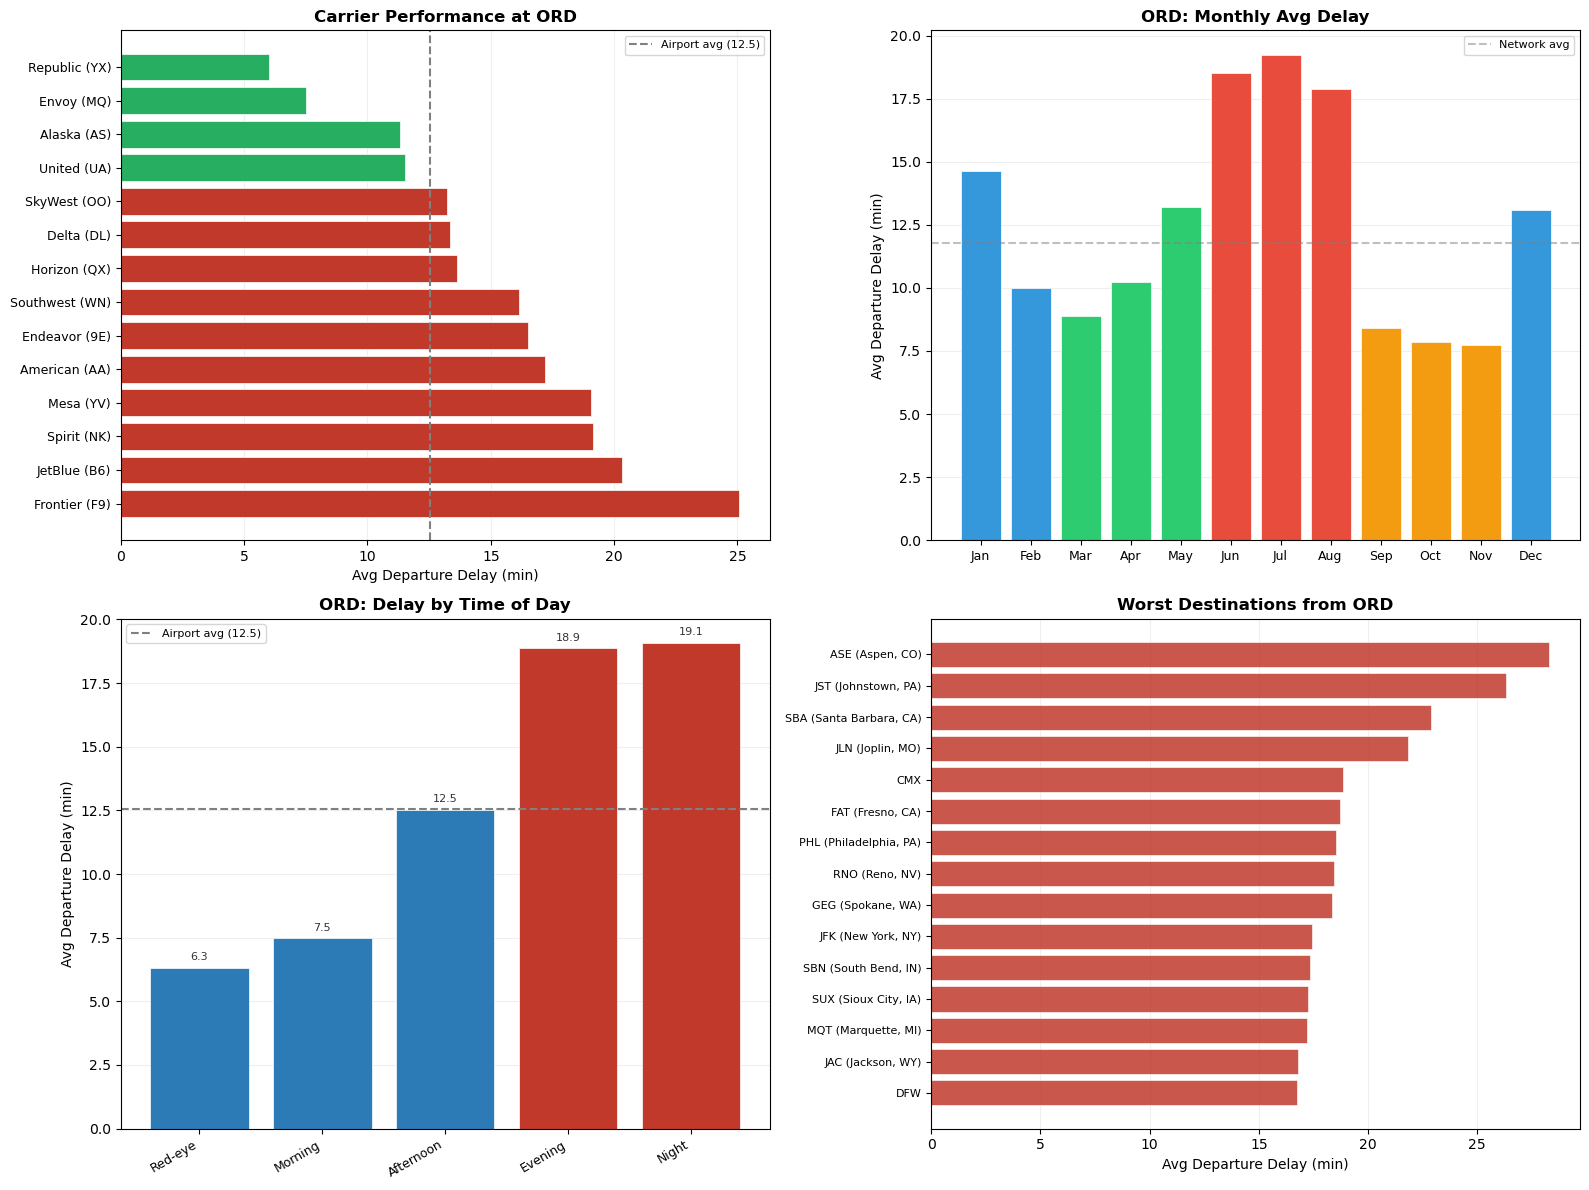

Best time to fly from ORD: Red-eye (6.3 min avg)
Best month: November (7.7 min avg)
Worst month: July (19.2 min avg)
Best carrier at ORD: Republic (6.0 min avg)


In [27]:
airport_profile('ORD')

#### 7.18.4 When Should I Fly?

This one answers a simple question: if I know my route and airline, when should I book to minimize my chances of a delay? It builds a heatmap grid of month by time-of-day with delay severity in each cell, then tells you the single best and worst slot. It also shows a monthly bar chart so you can see the seasonal pattern at a glance.

In [ ]:
def when_to_fly(origin='JFK', dest='LAX', carrier='DL'):
    """
    Heatmap showing best month × time-of-day to fly a route.
    Usage: when_to_fly('JFK', 'LAX', 'DL')
           when_to_fly('ORD', 'MIA', 'AA')
    """
    origin = origin.upper()
    dest = dest.upper()
    carrier = carrier.upper()

    display_carrier = regional_to_parent.get(carrier, carrier)
    primary, accent = airline_colors.get(display_carrier, ('#1a1a2e', '#e74c3c'))
    c_name = carrier_names.get(carrier, carrier)
    parent_name = carrier_names.get(display_carrier, display_carrier)
    if carrier != display_carrier:
        c_name = f"{c_name} ({parent_name})"

    origin_city = city_lookup.get(origin, origin)
    dest_city = city_lookup.get(dest, dest)

    mask = ((df_delays['ORIGIN'] == origin) &
            (df_delays['DEST'] == dest) &
            (df_delays['OP_UNIQUE_CARRIER'] == carrier))
    subset = df_delays[mask].copy()

    if len(subset) == 0:
        available = ', '.join(sorted(df_delays[(df_delays['ORIGIN']==origin) &
                                                (df_delays['DEST']==dest)]['OP_UNIQUE_CARRIER'].unique().tolist()))
        display(HTML(f"<div style='padding: 20px; background: {primary}; border-radius: 10px; "
                     f"font-family: Arial; color: white; max-width: 750px;'>"
                     f"<b>{c_name}</b> does not fly {origin} → {dest}.<br>"
                     f"Available: {available}</div>"))
        return

    if 'CRS_DEP_TIME' not in subset.columns:
        display(HTML("<div style='padding: 15px; background: #fff3cd; border-radius: 8px;'>"
                     "CRS_DEP_TIME not available — cannot build time-of-day heatmap.</div>"))
        return

    subset['_tod'] = subset['CRS_DEP_TIME'].apply(get_time_bin)

    tod_order = ['Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night']

    #  Build heatmap data: avg delay 
    delay_pivot = subset.groupby(['MONTH', '_tod'], observed=True)['DEP_DELAY'].mean().unstack('_tod')
    delay_pivot = delay_pivot.reindex(columns=[t for t in tod_order if t in delay_pivot.columns])
    delay_pivot = delay_pivot.reindex(range(1, 13))

    # Build heatmap data: delay rate
    rate_pivot = subset.groupby(['MONTH', '_tod'], observed=True)['DEP_DEL15'].mean().unstack('_tod')
    rate_pivot = rate_pivot.reindex(columns=[t for t in tod_order if t in rate_pivot.columns])
    rate_pivot = rate_pivot.reindex(range(1, 13))

    # Build heatmap data: flight counts 
    count_pivot = subset.groupby(['MONTH', '_tod'], observed=True)['DEP_DELAY'].count().unstack('_tod')
    count_pivot = count_pivot.reindex(columns=[t for t in tod_order if t in count_pivot.columns])
    count_pivot = count_pivot.reindex(range(1, 13)).fillna(0)

    # Find best/worst cells
    flat_delay = delay_pivot.stack()
    if len(flat_delay) > 0:
        best_idx = flat_delay.idxmin()
        worst_idx = flat_delay.idxmax()
        best_val = float(flat_delay.min())
        worst_val = float(flat_delay.max())
    else:
        best_idx = (1, 'Morning')
        worst_idx = (7, 'Evening')
        best_val = 0
        worst_val = 0

    avg_delay = float(subset['DEP_DELAY'].mean())

    # Header
    header_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, {primary} 0%, {primary}dd 100%);
             color: white; padding: 20px 25px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 12px; right: 20px; font-size: 34px;
                 font-weight: bold; color: {accent}; opacity: 0.4;">{display_carrier}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">When Should I Fly?</div>
            <div style="font-size: 26px; font-weight: bold; margin: 8px 0;">
                {c_name}: {origin} → {dest}</div>
            <div style="font-size: 14px; color: rgba(255,255,255,0.8);">
                {origin_city} → {dest_city}</div>
        </div>

        <div style="background: white; padding: 15px 25px; border: 1px solid #e0e0e0;
             display: grid; grid-template-columns: 1fr 1fr; gap: 15px;">
            <div style="background: #f0faf0; border-radius: 8px; padding: 12px 15px;
                 border-left: 4px solid #27ae60;">
                <div style="font-size: 11px; color: #888; text-transform: uppercase;">Best Time to Fly</div>
                <div style="font-size: 18px; font-weight: bold; color: #27ae60; margin-top: 4px;">
                    {month_names.get(best_idx[0], '?')} — {best_idx[1]}</div>
                <div style="font-size: 12px; color: #666;">Avg delay: {best_val:+.1f} min</div>
            </div>
            <div style="background: #fff0f0; border-radius: 8px; padding: 12px 15px;
                 border-left: 4px solid #c0392b;">
                <div style="font-size: 11px; color: #888; text-transform: uppercase;">Worst Time to Fly</div>
                <div style="font-size: 18px; font-weight: bold; color: #c0392b; margin-top: 4px;">
                    {month_names.get(worst_idx[0], '?')} — {worst_idx[1]}</div>
                <div style="font-size: 12px; color: #666;">Avg delay: {worst_val:+.1f} min</div>
            </div>
        </div>

        <div style="background: {primary}15; padding: 8px 25px; border: 1px solid #e0e0e0;
             border-top: none; border-radius: 0 0 10px 10px; font-size: 11px; color: #999;">
            Based on {len(subset):,} flights (2021–2024). Overall route avg: {avg_delay:+.1f} min.
        </div>
    </div>
    """
    display(HTML(header_html))

    # Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    # 1. Average delay heatmap
    sns.heatmap(delay_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', center=avg_delay,
                ax=axes[0], linewidths=1, linecolor='white',
                cbar_kws={'label': 'Avg Delay (min)', 'shrink': 0.8},
                annot_kws={'fontsize': 9})
    axes[0].set_yticklabels(month_labels, rotation=0, fontsize=10)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=10)
    axes[0].set_title(f'Average Departure Delay (min)\n{c_name}: {origin} → {dest}',
                     fontsize=12, fontweight='bold', color=primary)
    axes[0].set_ylabel('')

    # 2. Delay rate heatmap
    rate_display = rate_pivot * 100
    sns.heatmap(rate_display, annot=True, fmt='.0f', cmap='RdYlGn_r',
                center=rate_display.mean().mean(),
                ax=axes[1], linewidths=1, linecolor='white',
                cbar_kws={'label': '% Delayed >15 min', 'shrink': 0.8},
                annot_kws={'fontsize': 9})
    axes[1].set_yticklabels(month_labels, rotation=0, fontsize=10)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=10)
    axes[1].set_title(f'Delay Rate (% flights >15 min late)\n{c_name}: {origin} → {dest}',
                     fontsize=12, fontweight='bold', color=primary)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # Monthly bar chart
    monthly_all = subset.groupby('MONTH', observed=True).agg(
        avg_delay=('DEP_DELAY', 'mean'),
        flights=('DEP_DELAY', 'count')
    ).round(2)

    fig, ax = plt.subplots(figsize=(12, 4))
    season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
    colors_season = {'Winter':'#3498db','Spring':'#2ecc71','Summer':'#e74c3c','Fall':'#f39c12'}
    m_colors = [colors_season[season_map[m]] for m in monthly_all.index]

    bars = ax.bar(monthly_all.index, monthly_all['avg_delay'], color=m_colors,
                  edgecolor='white', linewidth=0.5)
    ax.axhline(y=avg_delay, color='gray', linestyle='--', alpha=0.5,
               label=f'Route avg ({avg_delay:.1f} min)')
    ax.axhline(y=11.8, color='black', linestyle=':', alpha=0.3, label='Network avg (11.8 min)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_ylabel('Avg Departure Delay (min)')
    ax.set_title(f'{c_name}: {origin} → {dest} — Monthly Overview',
                fontsize=12, fontweight='bold', color=primary)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}',
                ha='center', fontsize=8, color='#333')
    plt.tight_layout()
    plt.show()

    # --- Summary text ---
    best_month = monthly_all['avg_delay'].idxmin()
    worst_month = monthly_all['avg_delay'].idxmax()
    print(f"\nRecommendation for {c_name} {origin} → {dest}:")
    print(f"  Best month: {month_names[best_month]} ({monthly_all.loc[best_month, 'avg_delay']:.1f} min avg)")
    print(f"  Worst month: {month_names[worst_month]} ({monthly_all.loc[worst_month, 'avg_delay']:.1f} min avg)")
    print(f"  Best slot: {month_names.get(best_idx[0], '?')} {best_idx[1]} ({best_val:+.1f} min)")
    print(f"  Worst slot: {month_names.get(worst_idx[0], '?')} {worst_idx[1]} ({worst_val:+.1f} min)")
    print(f"  Difference: {worst_val - best_val:.1f} minutes between best and worst timing")

print("✈ When Should I Fly loaded")
print("Usage: when_to_fly('JFK', 'LAX', 'DL')")

✈ When Should I Fly loaded
Usage: when_to_fly('JFK', 'LAX', 'DL')


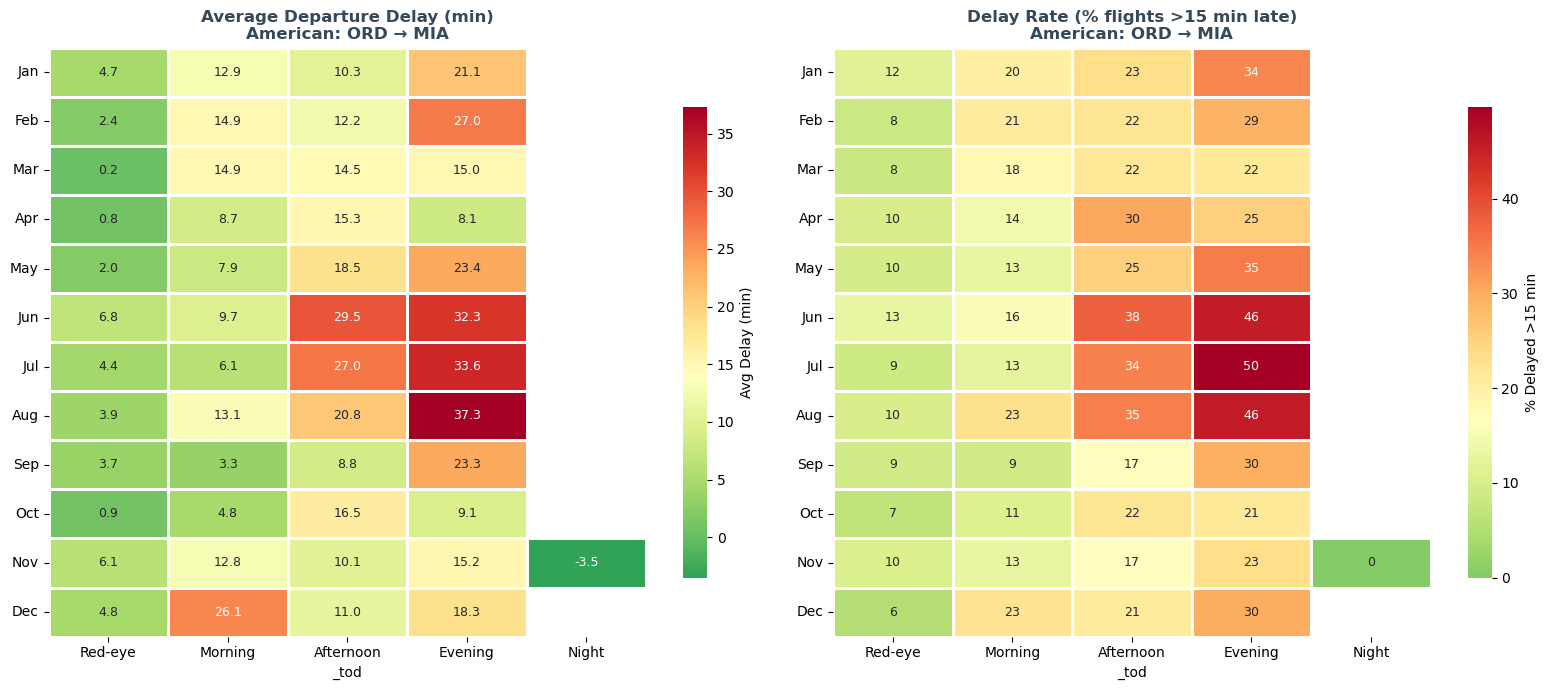

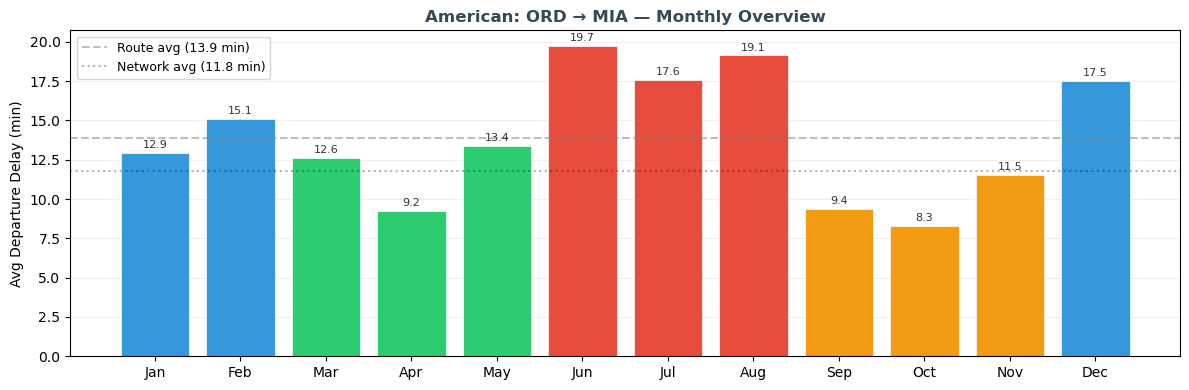


Recommendation for American ORD → MIA:
  Best month: October (8.3 min avg)
  Worst month: June (19.7 min avg)
  Best slot: November Night (-3.5 min)
  Worst slot: August Evening (+37.3 min)
  Difference: 40.8 minutes between best and worst timing


In [29]:
when_to_fly('ORD', 'MIA', 'AA')

### 7.19 Data Export for Companion Website

The following cells export aggregated data from the notebook into JavaScript-ready format for the companion website. These are utility cells that generate the const blocks pasted into the HTML file.

In [55]:
# Airport stats for JS
airport_stats = df_delays[df_delays['hub_size'].notna()].groupby('ORIGIN', observed=True).agg(
    lat=('latitude', 'first'),
    lon=('longitude', 'first'),
    city=('ORIGIN_CITY_NAME', 'first'),
    hub=('hub_size', 'first'),
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
).round(2)

# Clean city names (remove state)
airport_stats['city'] = airport_stats['city'].apply(lambda x: str(x).split(',')[0] if ',' in str(x) else str(x))

print("const AIRPORT_DATA = {")
for code, row in airport_stats.iterrows():
    print(f'  {code}:{{lat:{row.lat},lon:{row.lon},city:"{row.city}",hub:"{row.hub}",avg_delay:{float(row.avg_delay):.2f},delay_rate:{float(row.delay_rate):.4f},flights:{int(row.flights)}}},')
print("};")

const AIRPORT_DATA = {
  ABQ:{lat:35.040000915527344,lon:-106.61000061035156,city:"Albuquerque",hub:"M",avg_delay:9.97,delay_rate:0.1800,flights:83614},
  ANC:{lat:61.16999816894531,lon:-150.0,city:"Anchorage",hub:"M",avg_delay:5.41,delay_rate:0.1500,flights:74309},
  ATL:{lat:33.63999938964844,lon:-84.43000030517578,city:"Atlanta",hub:"L",avg_delay:9.73,delay_rate:0.1800,flights:1290968},
  AUS:{lat:30.190000534057617,lon:-97.66999816894531,city:"Austin",hub:"L",avg_delay:13.02,delay_rate:0.2200,flights:321720},
  BDL:{lat:41.939998626708984,lon:-72.68000030517578,city:"Hartford",hub:"M",avg_delay:11.86,delay_rate:0.1900,flights:85251},
  BNA:{lat:36.119998931884766,lon:-86.68000030517578,city:"Nashville",hub:"L",avg_delay:11.41,delay_rate:0.2100,flights:350305},
  BOI:{lat:43.560001373291016,lon:-116.22000122070312,city:"Boise",hub:"M",avg_delay:6.14,delay_rate:0.1300,flights:93713},
  BOS:{lat:42.36000061035156,lon:-71.01000213623047,city:"Boston",hub:"L",avg_delay:11.99,delay_rate:

In [56]:
# Only export major consumer-facing carriers
major_carriers = ['WN', 'DL', 'AA', 'UA', 'B6', 'AS', 'NK', 'F9', 'G4', 'HA']

carrier_stats = df_delays[df_delays['OP_UNIQUE_CARRIER'].isin(major_carriers)].groupby('OP_UNIQUE_CARRIER', observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count'),
    distance=('DISTANCE', 'mean')
).round(2)

carrier_stats['distance'] = carrier_stats['distance'].round(0).astype(int)
carrier_stats = carrier_stats.sort_values('avg_delay')

def assign_grade(rank, total):
    pct = rank / total
    if pct <= 0.2: return 'A'
    if pct <= 0.4: return 'B'
    if pct <= 0.6: return 'C'
    if pct <= 0.8: return 'D'
    return 'F'

total = len(carrier_stats)
carrier_stats['grade'] = [assign_grade(i+1, total) for i in range(total)]

print("const CARRIER_DATA = {")
for code, row in carrier_stats.iterrows():
    name = carrier_names.get(code, code)
    print(f'  "{code}":{{name:"{name}",avg_delay:{float(row.avg_delay):.2f},delay_rate:{row.delay_rate},flights:{int(row.flights)},grade:"{row.grade}",distance:{row.distance}}},')
print("};")

const CARRIER_DATA = {
  "AS":{name:"Alaska",avg_delay:6.14,delay_rate:0.18000000715255737,flights:886946,grade:"A",distance:1382},
  "HA":{name:"Hawaiian",avg_delay:6.95,delay_rate:0.1599999964237213,flights:289550,grade:"A",distance:922},
  "DL":{name:"Delta",avg_delay:8.98,delay_rate:0.1599999964237213,flights:3582645,grade:"B",distance:948},
  "UA":{name:"United",avg_delay:11.54,delay_rate:0.1899999976158142,flights:2511687,grade:"B",distance:1145},
  "WN":{name:"Southwest",avg_delay:12.67,delay_rate:0.25999999046325684,flights:5108256,grade:"C",distance:744},
  "NK":{name:"Spirit",avg_delay:15.20,delay_rate:0.25,flights:921538,grade:"C",distance:995},
  "G4":{name:"Allegiant",avg_delay:15.72,delay_rate:0.25,flights:452117,grade:"D",distance:892},
  "AA":{name:"American",avg_delay:16.30,delay_rate:0.2199999988079071,flights:3448542,grade:"D",distance:984},
  "F9":{name:"Frontier",avg_delay:18.73,delay_rate:0.2800000011920929,flights:659586,grade:"F",distance:945},
  "B6":{name:"Jet

In [65]:
# Only export monthly data for major consumer-facing carriers
major_carriers = ['WN', 'DL', 'AA', 'UA', 'B6', 'AS', 'NK', 'F9', 'G4', 'HA']

monthly = df_delays[df_delays['OP_UNIQUE_CARRIER'].isin(major_carriers)].groupby(
    ['OP_UNIQUE_CARRIER', 'MONTH'], observed=True
)['DEP_DELAY'].mean().round(2)

print("const CARRIER_MONTHLY = {")
for carrier in sorted(major_carriers):
    vals = [float(monthly.get((carrier, m), 0)) for m in range(1, 13)]
    vals_str = ','.join([f'{v:.2f}' for v in vals])
    print(f'  "{carrier}":[{vals_str}],')
print("};")

const CARRIER_MONTHLY = {
  "AA":[13.50,11.67,14.87,14.50,19.24,25.09,25.34,21.85,11.68,11.19,10.23,14.78],
  "AS":[7.04,4.38,5.69,5.80,4.42,7.83,7.32,6.82,3.94,3.31,4.91,12.14],
  "B6":[17.71,18.32,20.46,22.52,16.04,27.98,33.98,26.68,18.63,11.72,12.43,22.17],
  "DL":[9.35,6.49,9.37,9.11,9.40,13.26,14.33,11.30,5.75,4.31,4.33,10.28],
  "F9":[17.15,13.59,21.32,20.35,18.60,24.63,25.73,21.87,13.77,14.91,13.79,18.64],
  "G4":[12.95,10.82,16.07,14.86,12.56,20.70,24.29,16.31,10.30,11.59,11.57,19.65],
  "HA":[7.60,6.83,7.04,8.61,9.57,6.21,6.70,5.34,1.87,7.48,5.18,11.36],
  "NK":[13.11,12.37,16.79,18.04,14.29,20.00,22.24,18.77,10.23,9.12,10.94,16.23],
  "UA":[12.52,8.80,9.90,11.29,13.74,18.50,19.44,13.99,6.52,5.14,6.43,12.94],
  "WN":[9.96,7.75,12.38,12.27,13.32,17.90,18.46,15.10,9.84,10.98,8.10,14.29],
};


In [66]:
print("Building route stats (this takes a minute)...")

top_75 = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].unique()
df_top = df_delays[(df_delays['ORIGIN'].isin(top_75)) & (df_delays['DEST'].isin(top_75))]

routes_agg = df_top.groupby(['ORIGIN', 'DEST'], observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    delay=('DEP_DELAY', 'mean'),
    rate=('DEP_DEL15', 'mean'),
).round(2)

routes_agg = routes_agg[routes_agg['flights'] >= 1000]
print(f"Routes with 1000+ flights (top 75 only): {len(routes_agg)}")

worst = routes_agg.sort_values('delay', ascending=False).head(25)
print("\nconst WORST_ROUTES = [")
for (orig, dest), row in worst.iterrows():
    print(f'  {{route:"{orig} → {dest}", delay:{row.delay}, rate:{row.rate}, flights:{int(row.flights)}}},')
print("];")

Building route stats (this takes a minute)...
Routes with 1000+ flights (top 75 only): 2633

const WORST_ROUTES = [
  {route:"ONT → JFK", delay:38.16999816894531, rate:0.3799999952316284, flights:1124},
  {route:"BUR → JFK", delay:37.72999954223633, rate:0.4300000071525574, flights:1393},
  {route:"SAN → FLL", delay:34.72999954223633, rate:0.3700000047683716, flights:1455},
  {route:"SJU → DCA", delay:34.38999938964844, rate:0.4099999964237213, flights:1367},
  {route:"ANC → DFW", delay:34.040000915527344, rate:0.3400000035762787, flights:1200},
  {route:"BDL → SJU", delay:33.9900016784668, rate:0.44999998807907104, flights:3157},
  {route:"SMF → JFK", delay:33.220001220703125, rate:0.3700000047683716, flights:1128},
  {route:"JFK → SMF", delay:33.119998931884766, rate:0.44999998807907104, flights:1134},
  {route:"DFW → GEG", delay:32.90999984741211, rate:0.3799999952316284, flights:2239},
  {route:"IAH → JFK", delay:31.860000610351562, rate:0.3700000047683716, flights:1572},
  {route:

In [67]:
best = routes_agg.sort_values('delay', ascending=True).head(25)
print("const BEST_ROUTES = [")
for (orig, dest), row in best.iterrows():
    print(f'  {{route:"{orig} → {dest}", delay:{row.delay}, rate:{row.rate}, flights:{int(row.flights)}}},')
print("];")

const BEST_ROUTES = [
  {route:"PIT → RDU", delay:-1.6299999952316284, rate:0.07999999821186066, flights:2402},
  {route:"TUS → SLC", delay:0.05999999865889549, rate:0.07000000029802322, flights:4447},
  {route:"SNA → PDX", delay:0.1599999964237213, rate:0.10999999940395355, flights:4374},
  {route:"PDX → SNA", delay:0.2199999988079071, rate:0.10000000149011612, flights:4387},
  {route:"GEG → SAN", delay:0.6200000047683716, rate:0.09000000357627869, flights:1405},
  {route:"LGA → PHL", delay:0.8600000143051147, rate:0.10000000149011612, flights:1402},
  {route:"BOS → SDF", delay:0.9800000190734863, rate:0.10000000149011612, flights:1595},
  {route:"ONT → PDX", delay:1.0399999618530273, rate:0.11999999731779099, flights:1880},
  {route:"RDU → CVG", delay:1.1200000047683716, rate:0.07999999821186066, flights:1233},
  {route:"IND → IAD", delay:1.190000057220459, rate:0.09000000357627869, flights:3910},
  {route:"RDU → PIT", delay:1.2899999618530273, rate:0.10000000149011612, flights:2398}

In [68]:
major_carriers = ['WN', 'DL', 'AA', 'UA', 'B6', 'AS', 'NK', 'F9', 'G4', 'HA']
top_75 = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].unique()

carrier_airport = df_delays[
    (df_delays['OP_UNIQUE_CARRIER'].isin(major_carriers)) &
    (df_delays['ORIGIN'].isin(top_75))
].groupby(
    ['OP_UNIQUE_CARRIER', 'ORIGIN'], observed=True
).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
).round(2)

carrier_airport = carrier_airport[carrier_airport['flights'] >= 200]

print("const CARRIER_BEST_AIRPORTS = {", end="")
for carrier in sorted(major_carriers):
    if carrier not in carrier_airport.index.get_level_values(0):
        continue
    sub = carrier_airport.loc[carrier].sort_values('avg_delay').head(5)
    entries = []
    for apt, row in sub.iterrows():
        entries.append(f'"{apt}":{{"avg_delay":{float(row.avg_delay):.2f},"delay_rate":{float(row.delay_rate):.4f},"flights":{int(row.flights)}}}')
    print(f'"{carrier}":{{{",".join(entries)}}},', end="")
print("};")

print()

print("const CARRIER_WORST_AIRPORTS = {", end="")
for carrier in sorted(major_carriers):
    if carrier not in carrier_airport.index.get_level_values(0):
        continue
    sub = carrier_airport.loc[carrier].sort_values('avg_delay', ascending=False).head(5)
    entries = []
    for apt, row in sub.iterrows():
        entries.append(f'"{apt}":{{"avg_delay":{float(row.avg_delay):.2f},"delay_rate":{float(row.delay_rate):.4f},"flights":{int(row.flights)}}}')
    print(f'"{carrier}":{{{",".join(entries)}}},', end="")
print("};")

const CARRIER_BEST_AIRPORTS = {"AA":{"HNL":{"avg_delay":6.77,"delay_rate":0.0900,"flights":10043},"OGG":{"avg_delay":8.46,"delay_rate":0.0900,"flights":6682},"KOA":{"avg_delay":8.64,"delay_rate":0.0800,"flights":3378},"JFK":{"avg_delay":10.91,"delay_rate":0.1600,"flights":54016},"SJC":{"avg_delay":10.92,"delay_rate":0.1400,"flights":6876}},"AS":{"SJC":{"avg_delay":0.55,"delay_rate":0.1000,"flights":13010},"MCI":{"avg_delay":0.65,"delay_rate":0.1100,"flights":2712},"SNA":{"avg_delay":0.96,"delay_rate":0.1200,"flights":13971},"BOI":{"avg_delay":2.23,"delay_rate":0.1200,"flights":4017},"ANC":{"avg_delay":2.49,"delay_rate":0.1400,"flights":53467}},"B6":{"PIT":{"avg_delay":8.63,"delay_rate":0.1900,"flights":3944},"CLE":{"avg_delay":10.33,"delay_rate":0.1800,"flights":3399},"SFO":{"avg_delay":10.85,"delay_rate":0.1900,"flights":18672},"BWI":{"avg_delay":10.90,"delay_rate":0.2000,"flights":1535},"PHL":{"avg_delay":11.34,"delay_rate":0.2100,"flights":5100}},"DL":{"ABQ":{"avg_delay":2.52,"delay

In [69]:
major_carriers = ['WN', 'DL', 'AA', 'UA', 'B6', 'AS', 'NK', 'F9', 'G4', 'HA']
top_75 = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].unique()

print("Building carrier route stats (top 75 airports only)...")
cr_stats = df_delays[
    (df_delays['OP_UNIQUE_CARRIER'].isin(major_carriers)) &
    (df_delays['ORIGIN'].isin(top_75)) &
    (df_delays['DEST'].isin(top_75))
].groupby(
    ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST'], observed=True
).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
).round(2)

cr_stats = cr_stats[cr_stats['flights'] >= 200]
print(f"Carrier-routes with 200+ flights: {len(cr_stats)}")
gc.collect()

Building carrier route stats (top 75 airports only)...
Carrier-routes with 200+ flights: 5194


0

In [70]:
major_carriers = ['WN', 'DL', 'AA', 'UA', 'B6', 'AS', 'NK', 'F9', 'G4', 'HA']

print("const CARRIER_BEST_ROUTES = {", end="")
for carrier in sorted(major_carriers):
    if carrier not in cr_stats.index.get_level_values(0):
        continue
    sub = cr_stats.loc[carrier].sort_values('avg_delay').head(5)
    entries = []
    for (orig, dest), row in sub.iterrows():
        entries.append(f'"{orig} → {dest}":{{"avg_delay":{float(row.avg_delay):.2f},"delay_rate":{float(row.delay_rate):.4f},"flights":{int(row.flights)}}}')
    print(f'"{carrier}":{{{",".join(entries)}}},', end="")
print("};")

const CARRIER_BEST_ROUTES = {"AA":{"JFK → SNA":{"avg_delay":2.50,"delay_rate":0.0900,"flights":1254},"LAS → JFK":{"avg_delay":2.99,"delay_rate":0.0800,"flights":440},"DCA → LAS":{"avg_delay":3.08,"delay_rate":0.0900,"flights":1373},"BOS → FLL":{"avg_delay":3.50,"delay_rate":0.1100,"flights":547},"PHX → OGG":{"avg_delay":3.62,"delay_rate":0.1100,"flights":1888}},"AS":{"SJC → PDX":{"avg_delay":-2.43,"delay_rate":0.0800,"flights":1530},"ANC → MSP":{"avg_delay":-1.67,"delay_rate":0.0900,"flights":201},"ANC → DEN":{"avg_delay":-0.95,"delay_rate":0.0900,"flights":367},"GEG → SAN":{"avg_delay":-0.53,"delay_rate":0.0900,"flights":1235},"ANC → OGG":{"avg_delay":-0.38,"delay_rate":0.1000,"flights":346}},"B6":{"ORD → FLL":{"avg_delay":5.02,"delay_rate":0.1100,"flights":397},"BOS → MCI":{"avg_delay":6.57,"delay_rate":0.1400,"flights":519},"RIC → FLL":{"avg_delay":6.77,"delay_rate":0.1200,"flights":1422},"PHL → BOS":{"avg_delay":7.46,"delay_rate":0.1900,"flights":3708},"BOS → SAN":{"avg_delay":7.60

In [71]:
major_carriers = ['WN', 'DL', 'AA', 'UA', 'B6', 'AS', 'NK', 'F9', 'G4', 'HA']

print("const CARRIER_WORST_ROUTES = {", end="")
for carrier in sorted(major_carriers):
    if carrier not in cr_stats.index.get_level_values(0):
        continue
    sub = cr_stats.loc[carrier].sort_values('avg_delay', ascending=False).head(5)
    entries = []
    for (orig, dest), row in sub.iterrows():
        entries.append(f'"{orig} → {dest}":{{"avg_delay":{float(row.avg_delay):.2f},"delay_rate":{float(row.delay_rate):.4f},"flights":{int(row.flights)}}}')
    print(f'"{carrier}":{{{",".join(entries)}}},', end="")
print("};")

const CARRIER_WORST_ROUTES = {"AA":{"ANC → ORD":{"avg_delay":47.25,"delay_rate":0.3900,"flights":508},"MIA → SAV":{"avg_delay":44.28,"delay_rate":0.3600,"flights":240},"MIA → SDF":{"avg_delay":38.16,"delay_rate":0.3800,"flights":748},"DTW → ORD":{"avg_delay":36.27,"delay_rate":0.2600,"flights":468},"MIA → PDX":{"avg_delay":35.35,"delay_rate":0.4300,"flights":318}},"AS":{"ATL → SAN":{"avg_delay":22.84,"delay_rate":0.3400,"flights":214},"EWR → SAN":{"avg_delay":21.03,"delay_rate":0.3300,"flights":1224},"FLL → SFO":{"avg_delay":20.61,"delay_rate":0.3800,"flights":251},"IAD → SFO":{"avg_delay":20.42,"delay_rate":0.3400,"flights":1193},"EWR → PDX":{"avg_delay":19.64,"delay_rate":0.3100,"flights":1142}},"B6":{"RNO → JFK":{"avg_delay":65.82,"delay_rate":0.4600,"flights":663},"SMF → BOS":{"avg_delay":56.44,"delay_rate":0.4900,"flights":357},"PHX → EWR":{"avg_delay":50.44,"delay_rate":0.5100,"flights":328},"PHL → SJU":{"avg_delay":48.13,"delay_rate":0.5400,"flights":295},"SAN → FLL":{"avg_delay

In [64]:
total_flights = len(df_merged)
non_cancelled = len(df_delays)
with_weather = len(df_weather)
n_airports = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].nunique()
n_carriers = df_delays['OP_UNIQUE_CARRIER'].nunique()
overall_avg_delay = df_delays['DEP_DELAY'].mean()

# Delay cause breakdown
cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
delayed = df_delays[df_delays['DEP_DEL15'] == 1]
cause_totals = delayed[cause_cols].sum()
cause_pcts = (cause_totals / cause_totals.sum() * 100).round(1)

# Yearly
yearly = df_delays.groupby('YEAR', observed=True)['DEP_DELAY'].mean().round(2)
yearly_rate = (df_delays.groupby('YEAR', observed=True)['DEP_DEL15'].mean() * 100).round(1)

print("=== HERO STATS ===")
print(f"Total flights (after CrowdStrike removal): {total_flights:,}")
print(f"Non-cancelled: {non_cancelled:,}")
print(f"Airports: {n_airports}")
print(f"Carriers: {n_carriers}")
print(f"Overall avg delay: {overall_avg_delay:.1f} min")
print()
print("=== DELAY CAUSES ===")
for col, pct in cause_pcts.items():
    print(f"  {col}: {pct}%")
print()
print("=== YEARLY ===")
for year, delay in yearly.items():
    print(f"  {year}: avg={delay} min, rate={yearly_rate[year]}%")
print()
print("=== MONTHLY (for chart) ===")
monthly_all = df_delays.groupby('MONTH', observed=True)['DEP_DELAY'].mean().round(2)
vals = [str(monthly_all[m]) for m in range(1, 13)]
print(f"const monthDelays = [{','.join(vals)}];")

=== HERO STATS ===
Total flights (after CrowdStrike removal): 26,506,150
Non-cancelled: 26,048,566
Airports: 75
Carriers: 17
Overall avg delay: 11.7 min

=== DELAY CAUSES ===
  CARRIER_DELAY: 39.5%
  WEATHER_DELAY: 6.300000190734863%
  NAS_DELAY: 12.199999809265137%
  SECURITY_DELAY: 0.20000000298023224%
  LATE_AIRCRAFT_DELAY: 41.79999923706055%

=== YEARLY ===
  2021: avg=9.380000114440918 min, rate=17.399999618530273%
  2022: avg=12.569999694824219 min, rate=21.299999237060547%
  2023: avg=12.25 min, rate=20.5%
  2024: avg=12.15999984741211 min, rate=20.299999237060547%

=== MONTHLY (for chart) ===
const monthDelays = [11.08,8.78,10.77,10.8,12.1,16.79,17.82,14.44,8.1,7.76,7.37,13.32];


## 8. Results <a id="sec8"></a>

### 8.1 Airline Performance

JetBlue and Frontier are the worst-performing large airlines by both average delay (20.7 and 18.7 minutes, respectively) and delay rate (29% and 28% of flights delayed over 15 minutes). Alaska and Hawaiian are the best large airlines, with both under 7 minutes average despite flying some of the longest routes. Delta ranks third. The median delay is actually negative for most carriers, meaning more than half of all flights depart early. The averages get pulled up by the long tail of severely delayed flights.

### 8.2 Airport and Route Patterns

Florida airports dominate the worst-delay rankings. FLL, SJU, MCO, and MIA are the four worst airports by average departure delay. K-Means clustering independently surfaced a Southeast/Florida delay cluster. The worst routes are almost all long-haul flights to or from Florida; the best routes are short western hops and Hawaiian inter-island flights. Large hubs average about 12.35 minutes of delay versus 9.6 for small hubs (ANOVA F = 3,519.97, p $\approx$ 0). Tukey HSD confirms large hubs differ significantly from medium and small, but medium and small do not differ from each other.

### 8.3 Delay Causes

Late aircraft cascades account for 38.6% of total delay minutes, followed by carrier-caused delays at 37.5%. Together those two operational categories drive 76.1% of all delay minutes. Weather accounts for just 5.9%, NAS (air traffic control) for 17.8%, and security for 0.2%. Weather gets blamed for delays far more than the data warrants.

### 8.4 Seasonal and Temporal Trends

Summer is the worst season by a wide margin — June and July average 16–18 minutes of delay. Fall is the best at 7–8 minutes. Tukey HSD confirms every seasonal pair is significantly different except Spring vs Winter. Average delay jumped 34% from 2021 (9.4 min) to 2022 (12.6 min) as post-COVID travel rebounded, then plateaued around 12.2 minutes through 2024. Time series decomposition confirms a strong seasonal cycle with an approximately 11-minute swing peak-to-trough.

### 8.5 Weather as a Predictor

A weather-only OLS explains 0.75% of departure delay variance. The full model with weather, airport, month, and carrier dummies explains about 1.74%. Precipitation is the strongest weather predictor (+3.75 min per standard deviation), followed by temp_max (+1.99). The log-transformed model improved residual normality dramatically (skewness: 11.94 → 0.17) but did not change the substantive conclusion. Ridge regression with interaction terms produced only marginal improvement. The two-stage model (logistic + OLS) achieved AUC = 0.57.

### 8.6 Machine Learning Results

K-Nearest Neighbors confirmed what logistic regression showed: weather and airport features cannot reliably classify whether a flight will be delayed, with low AUC across all k values tested. K-Means clustering of airports produced three distinct groups that align closely with the geographic patterns from the descriptive analysis.

### 8.7 What the Models Cannot Explain

Every model we tested — OLS, log-OLS, logistic, K-NN, Ridge with interactions — hit a ceiling of roughly 2% explained variance. Adding aircraft type to the regression did not help; $R^2$ actually decreased slightly due to collinearity with carrier dummies. That is not a model failure, it is a data limitation. The factors that drive individual flight delays are operational and flight-specific: whether the inbound aircraft arrived late, whether there was a maintenance issue, whether the crew timed out, whether a gate was occupied. None of those appear in any public dataset. Public data is genuinely useful for characterizing delay patterns across carriers, airports, routes, and seasons. It cannot tell you whether your specific flight tomorrow will be late.

## 9. Limitations of Analysis <a id="sec9"></a>

### 9.1 Data Limitations
- **No operational data.** The biggest driver of delays: late-arriving inbound aircraft, mechanical issues, crew scheduling, and gate conflicts, are not in the BTS dataset. This is why all models achieve very low $R^2$.
- **Daily weather granularity.** We use daily weather summaries, but delays happen at specific hours. A thunderstorm at 3 PM does not affect a 7 AM departure, yet our data treats them the same.
- **No ticket price data.** The BTS dataset does not include fares, so our cost-to-performance analysis (Q2) uses distance as a proxy.
- **Survivorship bias.** Cancelled flights are excluded from delay analysis. If an airline cancels its worst flights rather than letting them depart late, its delay numbers look artificially better.

### 9.2 Methodological Limitations
- **OLS normality violation.** Delay data is heavily right-skewed. The log transform improves residual behavior but does not fully resolve the issue.
- **Endogeneity.** Late aircraft delay is both a cause and a consequence of the delay system. Using it as a predictor would be circular, so we excluded it from regression features.
- **CrowdStrike removal.** We removed July 19–25, 2024 (roughly 145,000 flights) to avoid contaminating the analysis with a one-time IT failure. This is defensible but means our 2024 numbers are slightly more optimistic than raw BTS totals.
- **Sample size in modeling.** OLS and Ridge used a 500K flight sample for computational feasibility. Results may vary slightly with different random seeds, though the substantive conclusions are stable.

### 9.3 Generalizability
Some of our findings apply to U.S. domestic flights from 2021–2024 at the 75 busiest airports. They may not generalize to international flights, smaller regional airports, or future time periods with different operational conditions.

## 10. Conclusions <a id="sec10"></a>

### 10.1 Key Findings

1. **Weather is not the villain.** Despite popular belief, weather accounts for only 5.9% of total delay minutes and explains less than 1% of delay variance in regression. The real culprits are late-arriving aircraft (38.6%) and carrier-level operational failures (37.5%), which together drive 76.1% of all delay minutes.

2. **Who you fly with matters more than where or when.** Carrier identity adds more explanatory power to the regression (0.56%) than airport characteristics (0.06%) or seasonality (0.30%). Alaska and Hawaiian consistently outperform; JetBlue and Frontier consistently underperform.

3. **Summer is the worst season — not winter.** Average delays hit 16–18 minutes in June–July versus 7–8 minutes in September–November. Thunderstorms beat blizzards. Tukey HSD confirms every season pair differs significantly except Spring vs Winter.

4. **Delays got worse after COVID and have not recovered.** Average delay jumped 34% from 2021 (9.4 min) to 2022 (12.6 min) as travel volume surged. It has since plateaued around 12.2 minutes through 2024.

5. **Florida dominates the worst routes.** FLL, MCO, MIA, and PBI appear repeatedly in the worst-route rankings. K-Means clustering independently confirms a Southeast/Florida delay cluster.

6. **Individual delay prediction is fundamentally hard.** No model we tested — OLS, logistic, K-NN, Ridge with interactions — could reliably predict whether a specific flight would be delayed. The $R^2$ ceiling is around 2%. That is a data limitation, not a model failure. The real drivers of individual delays are operational factors not captured in any public dataset.

### 10.2 Implications

For **travelers**: fly in fall, avoid Florida-to-Northeast routes in summer, and choose your airline carefully. Carrier choice matters more than airport or weather.

For **airlines**: the data suggests that operational improvements (reducing late aircraft cascades, better crew scheduling) would reduce delays far more than any weather mitigation strategy.

For **researchers**: public flight data can characterize delay patterns effectively but cannot predict individual delays. Access to operational data (crew logs, maintenance records, gate assignment systems) would be needed to build a genuinely predictive model.

### 10.3 Companion Website

We built a companion website at [https://cleared-for-delay.netlify.app/](https://cleared-for-delay.netlify.app/) that presents these findings interactively, including a live Flight Intelligence tool powered by the AirLabs API that provides real-time flight status, gate and terminal info, aircraft details, live weather from Open-Meteo, and historical delay risk analysis based on our full 26 million flight dataset.